# ETS MARL — Default-Config Research-Question Analysis

This notebook focuses on what the **default configuration** alone can tell
us about the thesis research questions. It deliberately does **not**
attempt cross-config (variant) comparisons — those will be addressed in a
separate experiments notebook.

**Research questions** (full text in `docs/research_questions.md` and the
top-level `README.md`):

* **Main RQ** — How can MARL be used to simulate the EU ETS, and what
  does the simulation reveal about its regulatory mechanisms and the
  strategic behaviour of power-sector participants?
* **Sub-RQ 1** — What environment / algorithm design choices are required
  to build a *stable, behaviourally credible* simulation?
* **Sub-RQ 2** — How sensitive are market outcomes (price stability,
  compliance, decarbonisation pace) to the regulatory mechanisms of the
  EU ETS? *(Default-only ⇒ descriptive baseline; cross-variant claims
  deferred.)*
* **Sub-RQ 3** — How do financial vs environmental objectives shape
  company strategies, and how do those aggregate into market-level
  outcomes?

**Structure**

1. Setup — locate project root.
2. Imports.
3. Multi-sweep loader (allows pulling in **several** default-config
   sweeps at once — extends the single-spec pattern from `ets_marl -
   Sweep Analysis.ipynb`).
4. Discovery & loading.
5. Sanity overview (counts, episode coverage, default-only filter).
6. **§RQ1** — convergence, cross-seed reproducibility, behavioural
   credibility, pathology.
7. **§RQ2** — within-default regulatory mechanism behaviour (cap → price,
   MSR / TNAC, penalty incidence, decarbonisation pace).
8. **§RQ3** — strategic behaviour by archetype and reward weighting,
   aggregated to system-level outcomes.

The notebook is intentionally compact: each section ships the headline
plot or table that supports the corresponding RQ claim, and stops there.


In [2]:
# Install notebook dependencies if needed.
# Set INSTALL_NOTEBOOK_DEPS = True (or run the cell with required packages missing)
# to pip-install everything in notebooks/requirements-notebooks.txt using the
# CURRENT kernel's interpreter. This is more reliable than `%pip install -r {path}`
# (IPython magics don't expand `{var}` at runtime) and works on Azure / Colab / local.
import subprocess, sys, importlib, re
from pathlib import Path

INSTALL_NOTEBOOK_DEPS = False  # flip to True to force-reinstall

# Map PyPI distribution name -> import module name when they differ.
_DIST_TO_IMPORT = {
    "pyyaml": "yaml",
    "scikit-learn": "sklearn",
    "imbalanced-learn": "imblearn",
    "opencv-python": "cv2",
    "pillow": "PIL",
    "beautifulsoup4": "bs4",
    "ipython": "IPython",
}

def _find_requirements():
    req_name = "requirements-notebooks.txt"
    here = Path.cwd()
    candidates = [here / req_name, here / "notebooks" / req_name]
    candidates.extend(p / "notebooks" / req_name for p in here.parents)
    return next((p for p in candidates if p.exists()), None)

def _parse_requirements(req_path):
    """Extract distribution names from a requirements file (skip comments, options, env markers)."""
    dists = []
    for raw in req_path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or line.startswith("-"):
            continue
        # Strip env markers and extras: "pkg[extra]>=1.0; python_version>='3.9'"
        line = line.split(";", 1)[0].strip()
        m = re.match(r"^([A-Za-z0-9_.\-]+)", line)
        if m:
            dists.append(m.group(1).lower())
    return dists

def _missing_required(dists):
    missing = []
    for dist in dists:
        mod = _DIST_TO_IMPORT.get(dist, dist.replace("-", "_"))
        try:
            importlib.import_module(mod)
        except ImportError:
            missing.append(dist)
    return missing

req_path = _find_requirements()
if req_path is None:
    raise FileNotFoundError("Could not find notebooks/requirements-notebooks.txt")

dists = _parse_requirements(req_path)
missing = _missing_required(dists)

if INSTALL_NOTEBOOK_DEPS or missing:
    if missing:
        print(f"Missing packages: {missing}")
    print(f"Installing notebook dependencies from: {req_path}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(req_path)])
else:
    print(f"All {len(dists)} notebook dependencies present; skipping install.")
    print("(Set INSTALL_NOTEBOOK_DEPS = True to force a reinstall.)")

All 14 notebook dependencies present; skipping install.
(Set INSTALL_NOTEBOOK_DEPS = True to force a reinstall.)


## 1. Setup — Locate Project Root

In [3]:
import os, sys
from pathlib import Path

def _is_project_root(path: str) -> bool:
    return os.path.isdir(os.path.join(path, "src")) and os.path.isdir(os.path.join(path, "configs"))

_candidates = ["..", ".", os.path.join("..", ".."),
               os.path.join("Thesis-Energy-Auction", "ets_marl_happo_current"), "Thesis-Energy-Auction"]
_found = _is_project_root(".")
if not _found:
    for _c in _candidates:
        if _is_project_root(_c):
            os.chdir(_c); _found = True; break
if not _found:
    raise FileNotFoundError(f"Cannot find project root (needs src/ + configs/).\nCWD: {os.getcwd()}  |  Contents: {os.listdir('.')}")

PROJECT_ROOT = Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
print(f"Working directory: {PROJECT_ROOT}")


Working directory: C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction


## 2. Imports

In [4]:
import re
import yaml
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from src.utils.run_data import load_run_csv, glob_run_logs  # parquet-cached log loader
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

from src.utils.sweep import load_sweep_spec, expand_dotted_overrides, deep_merge


## 3. Sweep Specs to Load

List one or more sweep specs (paths relative to the project root). All of
them are loaded and merged into a single dict keyed by `(sweep_name,
variant_name, seed)`. The default below loads only `default_seeds.yaml`,
but additional default-config sweeps can be appended freely — every run
that survives the §5 filter is treated as another seed of the *same*
default-config population.

> If a sweep contains variants whose `overrides` deviate from the base
> config, those variants are flagged in §5 and excluded from the analysis
> by default (this notebook is for the default config only). To include
> them anyway, set `STRICT_DEFAULT_ONLY = False` in §5.


In [5]:
# Add additional default-config sweeps here as the project produces them.
SWEEP_SPECS = [
    PROJECT_ROOT / 'configs' / 'sweeps' / 'default_seeds.yaml',
   # PROJECT_ROOT / 'configs' / 'sweeps' / 'default_seeds_old.yaml',
  #  PROJECT_ROOT / 'configs' / 'sweeps' / 'default_seeds_expanded.yaml'
]

# Optional: override the output_dir from the spec (useful if results were
# moved). One entry per spec, or None to use the spec's own output_dir.
OUTPUT_DIR_OVERRIDES = [
    PROJECT_ROOT / 'results' / 'sweeps' / 'default',
  #  PROJECT_ROOT / 'results' / 'sweeps',
   # PROJECT_ROOT / 'results' / 'sweeps' / 'default'
]
assert len(OUTPUT_DIR_OVERRIDES) == len(SWEEP_SPECS), "one override (or None) per spec"

for sp in SWEEP_SPECS:
    if not Path(sp).exists():
        warnings.warn(f"Spec not found: {sp}")

print(f"Loading {len(SWEEP_SPECS)} sweep spec(s):")
for sp, od in zip(SWEEP_SPECS, OUTPUT_DIR_OVERRIDES):
    print(f"  - {sp}  (override={od})")


Loading 1 sweep spec(s):
  - C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\configs\sweeps\default_seeds.yaml  (override=C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\results\sweeps\default)


## 4. Multi-Sweep Discovery & Loading

In [6]:
from src.utils.run_data import log_exists, default_ep_columns, default_yr_columns
from tqdm.auto import tqdm


def _resolve_run_files(variant_name, seed, variant_dir, output_dir):
    """Return (training_log, year_log) paths or (None, None). Tagged then untagged."""
    search_dirs = []

    # Existing locations
    for d in (variant_dir, output_dir):
        if d is not None:
            d = Path(d)
            if d not in search_dirs:
                search_dirs.append(d)

    # Extra fallback: results/sweep/<tag>[/<variant>]
    # (tag inferred from output_dir name, e.g. default_seeds)
    if output_dir is not None:
        tag = Path(output_dir).name
        alt_base = PROJECT_ROOT / "results" / "sweep" / tag
        for d in (alt_base / variant_name, alt_base):
            if d not in search_dirs:
                search_dirs.append(d)

    training_names = [f"training_log_{variant_name}_s{seed}.csv", f"training_log_s{seed}.csv"]
    year_names = [f"year_log_{variant_name}_s{seed}.csv", f"year_log_s{seed}.csv"]

    tlog = ylog = None
    for base in search_dirs:
        if tlog is None:
            for n in training_names:
                cand = base / n
                if log_exists(cand):
                    tlog = cand
                    break
        if ylog is None:
            for n in year_names:
                cand = base / n
                if log_exists(cand):
                    ylog = cand
                    break
        if tlog is not None and ylog is not None:
            break

    return tlog, ylog

# Project both logs onto the analysis-superset columns at load time. The
# year_log carries 270+ diagnostic columns; pulling only the ~80 actually
# used by this notebook cuts in-RAM size by ~5-10x. Unknown columns are
# silently dropped by load_run_csv.
EP_COLUMNS = default_ep_columns()
YR_COLUMNS = list(dict.fromkeys(
    default_yr_columns()
    + [f"sec_price_mult_A{i}" for i in range(1, 17)]
))

def _load_csv_or_none(path, columns=None):
    if path is None: return None
    return load_run_csv(path, columns=columns)

def _empty_ep(yr=None):
    if yr is not None and 'episode' in yr.columns:
        return pd.DataFrame({'episode': np.sort(yr['episode'].dropna().unique())})
    return pd.DataFrame({'episode': pd.Series(dtype='int64')})

def _empty_yr(ep=None):
    if ep is not None and 'episode' in ep.columns and len(ep) > 0:
        return pd.DataFrame({'episode': ep['episode'].astype('int64').values,
                             'year': np.zeros(len(ep), dtype='int64')})
    return pd.DataFrame({'episode': pd.Series(dtype='int64'), 'year': pd.Series(dtype='int64')})

specs = []
for spec_path, override in zip(SWEEP_SPECS, OUTPUT_DIR_OVERRIDES):
    if not Path(spec_path).exists():
        continue
    spec = load_sweep_spec(str(spec_path))
    sweep_name = Path(spec_path).stem
    with open(spec['base_config'], encoding='utf-8') as f:
        base_cfg = yaml.safe_load(f)
    output_dir = Path(override) if override is not None else (PROJECT_ROOT / spec['output_dir']).resolve()
    specs.append({'name': sweep_name, 'spec': spec, 'base_cfg': base_cfg, 'output_dir': output_dir})

# Pre-enumerate every (sweep, variant, seed) we'll attempt so tqdm has a real total.
load_jobs = []
for s in specs:
    for v in s['spec']['variants']:
        seeds = v['seeds'] if v['seeds'] is not None else s['spec']['seeds']
        variant_dir = s['output_dir'] / v['name']
        merged_cfg = deep_merge(s['base_cfg'], expand_dotted_overrides(v.get('overrides') or {}))
        flat_overrides = expand_dotted_overrides(v.get('overrides') or {})
        for seed in seeds:
            load_jobs.append((s, v, seed, variant_dir, merged_cfg, flat_overrides))

# Build (sweep, variant, seed) -> run dict.
runs = {}
discovery = []
for s, v, seed, variant_dir, merged_cfg, flat_overrides in tqdm(
    load_jobs, desc='Loading sweep CSVs', unit='run', leave=True
):
    tlog, ylog = _resolve_run_files(v['name'], seed, variant_dir, s['output_dir'])
    row = {
        'sweep': s['name'], 'variant': v['name'], 'seed': seed,
        'has_overrides': bool(flat_overrides),
        'training_log': str(tlog) if tlog else None,
        'year_log': str(ylog) if ylog else None,
        'has_training_log': tlog is not None,
        'has_year_log': ylog is not None,
        'found': (tlog is not None) or (ylog is not None),
    }
    discovery.append(row)
    if not row['found']:
        continue
    ep_df = _load_csv_or_none(tlog, columns=EP_COLUMNS)
    yr_df = _load_csv_or_none(ylog, columns=YR_COLUMNS)
    if ep_df is None and yr_df is None:
        continue
    if ep_df is None: ep_df = _empty_ep(yr_df)
    if yr_df is None: yr_df = _empty_yr(ep_df)
    runs[(s['name'], v['name'], seed)] = {
        'ep_df': ep_df, 'yr_df': yr_df, 'config': merged_cfg,
        'has_overrides': bool(flat_overrides),
        'overrides': flat_overrides,
        'has_training_log': bool(tlog), 'has_year_log': bool(ylog),
    }

discovery_df = pd.DataFrame(discovery)
n_found = int(discovery_df['found'].sum()) if not discovery_df.empty else 0
print(f"Discovered {len(discovery_df)} (sweep, variant, seed) triples; loaded {n_found}.")
if not runs:
    raise RuntimeError("No runs loaded. Check SWEEP_SPECS / OUTPUT_DIR_OVERRIDES.")
discovery_df

# Free chunked CSV/parquet readers held by pandas/pyarrow before continuing.
import gc; gc.collect()


Loading sweep CSVs:   0%|          | 0/4 [00:00<?, ?run/s]

Discovered 4 (sweep, variant, seed) triples; loaded 4.


25

## 5. Default-Only Filter & Sanity Overview

In [7]:
STRICT_DEFAULT_ONLY = True  # if True, drop runs whose variant has any override.

if STRICT_DEFAULT_ONLY:
    n_before = len(runs)
    runs = {k: v for k, v in runs.items() if not v['has_overrides']}
    n_after = len(runs)
    if n_after < n_before:
        print(f"Filtered out {n_before - n_after} run(s) whose variant overrides the base config.")
    if n_after == 0:
        raise RuntimeError("STRICT_DEFAULT_ONLY filtered out every run. Set STRICT_DEFAULT_ONLY = False to inspect non-default variants.")

# Treat every surviving run as a default-config seed. Build a flat list.
ALL_RUN_KEYS = sorted(runs.keys())
print(f"\nUsable default-config runs: {len(ALL_RUN_KEYS)}")
for (sw, var, seed), run in sorted(runs.items()):
    n_eps = len(run['ep_df'])
    n_yrs = len(run['yr_df'])
    print(f"  {sw}/{var}/seed={seed:>4}  ({n_eps:>6} episodes, {n_yrs:>7} year-rows)")

# Pick a reference config. All defaults agree on schema; just take the first.
REFERENCE_CONFIG = runs[ALL_RUN_KEYS[0]]['config']
N_AGENTS = int(REFERENCE_CONFIG.get('companies', {}).get('n_agents', 8))
N_BOTS   = int(REFERENCE_CONFIG.get('companies', {}).get('n_bot_agents', 0))
N_TOTAL  = N_AGENTS + N_BOTS
N_YEARS  = int(REFERENCE_CONFIG.get('environment', {}).get('n_years', 12))
YEAR_DISPLAY_START = 1
YEAR_DISPLAY_END = N_YEARS
print(f"\nReference config: n_agents={N_AGENTS}, n_bot_agents={N_BOTS}, n_years={N_YEARS}")


def _year_log_to_display_years(yr_df):
    if yr_df is None or yr_df.empty or 'year' not in yr_df.columns:
        return yr_df, False
    year = pd.to_numeric(yr_df['year'], errors='coerce')
    finite_year = year.dropna()
    if finite_year.empty:
        return yr_df, False
    year_min = finite_year.min()
    year_max = finite_year.max()
    if year_min >= YEAR_DISPLAY_START:
        return yr_df, False
    if year_min == 0 and year_max <= max(N_YEARS - 1, 0):
        shifted_year = year + YEAR_DISPLAY_START
        if shifted_year.notna().all():
            rounded_year = shifted_year.round()
            if shifted_year.eq(rounded_year).all():
                shifted_year = rounded_year.astype('int16', copy=False)
        yr_df['year'] = shifted_year
        return yr_df, True
    raise ValueError(f"Unexpected year range in year_log: {year_min}..{year_max}")

n_shifted_year_frames = 0
for run in runs.values():
    run['yr_df'], shifted = _year_log_to_display_years(run.get('yr_df'))
    n_shifted_year_frames += int(shifted)

if n_shifted_year_frames:
    print(f"Converted {n_shifted_year_frames} year_log frame(s) from years 0-{N_YEARS - 1} to years {YEAR_DISPLAY_START}-{YEAR_DISPLAY_END}.")
else:
    print(f"Year_log frames already use display years {YEAR_DISPLAY_START}-{YEAR_DISPLAY_END}.")

# Archetype/reward labelling (default config: 4 archetypes x {financial, ESG}).
ARCHETYPES = ['Coal-heavy', 'Gas-dominant', 'Transitioner', 'Green-leader']
def _agent_archetype(idx0):
    return ARCHETYPES[idx0 // 2] if idx0 // 2 < len(ARCHETYPES) else f'Custom-{idx0//2}'
def _agent_weighting(idx0):
    # Even indices (A1, A3, ...) are pure financial; odd are balanced ESG. (Per README.)
    return 'Financial' if idx0 % 2 == 0 else 'Balanced ESG'

AGENT_LABELS = [f'A{i+1} ({_agent_archetype(i)}, {_agent_weighting(i)})' for i in range(N_AGENTS)]
print("Agent roster (1-based):")
for lbl in AGENT_LABELS:
    print(f"  {lbl}")


Usable default-config runs: 4
  default_seeds/default/seed=1729  (120000 episodes, 1440000 year-rows)
  default_seeds/default/seed=5041  (120000 episodes, 1440000 year-rows)
  default_seeds/default/seed=6561  (120000 episodes, 1440000 year-rows)
  default_seeds/default/seed=8191  (120000 episodes, 1440000 year-rows)

Reference config: n_agents=8, n_bot_agents=0, n_years=12
Converted 4 year_log frame(s) from years 0-11 to years 1-12.
Agent roster (1-based):
  A1 (Coal-heavy, Financial)
  A2 (Coal-heavy, Balanced ESG)
  A3 (Gas-dominant, Financial)
  A4 (Gas-dominant, Balanced ESG)
  A5 (Transitioner, Financial)
  A6 (Transitioner, Balanced ESG)
  A7 (Green-leader, Financial)
  A8 (Green-leader, Balanced ESG)


### 5a. Helpers

A handful of helpers reused across §RQ1–§RQ3. We intentionally treat
every loaded run as one seed of the same default-config population (no
variant axis) — the helpers therefore aggregate over `ALL_RUN_KEYS`
without any variant grouping.

In [8]:
ROLL = 50              # episode-axis smoothing window
TAIL_EPISODES = 1000    # converged-window definition for steady-state metrics

def agent_cols(df, prefix, max_idx=N_AGENTS):
    """Return columns 'prefix_A1' ... 'prefix_A{max_idx}' that exist in df, sorted by agent index."""
    rx = re.compile(rf'^{re.escape(prefix)}_A(\d+)$')
    out = []
    for c in df.columns:
        m = rx.match(c)
        if m and int(m.group(1)) <= max_idx:
            out.append((int(m.group(1)), c))
    return [c for _, c in sorted(out)]

def per_run_series(metric_fn, source='ep'):
    """Return dict {run_key: pd.Series indexed by episode} from each run."""
    out = {}
    for k, run in runs.items():
        df = run['yr_df'] if source == 'yr' else run['ep_df']
        if source == 'run':
            s = metric_fn(run)
        else:
            s = metric_fn(df)
        if s is None or len(s) == 0:
            continue
        s = s.copy()
        if source == 'ep' and 'episode' in run['ep_df'].columns:
            s.index = run['ep_df']['episode']
        out[k] = s
    return out

def stack_runs(metric_fn, source='ep'):
    """Return wide DataFrame of episode-indexed series, one column per run."""
    series = per_run_series(metric_fn, source=source)
    if not series:
        return pd.DataFrame()
    return pd.concat(series, axis=1).sort_index()

def fan_chart(df, ax, color='steelblue', label='runs', smooth=ROLL):
    """Plot mean ±1 std fan + thin per-run lines for a wide DataFrame."""
    if df.empty:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
        return
    sm = df.rolling(smooth, min_periods=1).mean()
    mean = sm.mean(axis=1)
    std = sm.std(axis=1).fillna(0.0)
    for col in sm.columns:
        ax.plot(sm.index, sm[col].values, color=color, lw=0.6, alpha=0.30)
    ax.fill_between(sm.index, (mean - std).values, (mean + std).values,
                    color=color, alpha=0.20, label=f'{label} ±1 std (n={sm.shape[1]})')
    ax.plot(sm.index, mean.values, color=color, lw=2.2, label=f'{label} mean')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8, loc='best')

def tail_episodes(ep_df, n=TAIL_EPISODES):
    if ep_df.empty: return ep_df
    return ep_df.tail(min(n, len(ep_df)))

def tail_year_rows(run, n=TAIL_EPISODES):
    ep = tail_episodes(run['ep_df'], n)
    if ep.empty or 'episode' not in run['yr_df'].columns:
        return run['yr_df'].head(0)
    return run['yr_df'][run['yr_df']['episode'].isin(ep['episode'].unique())]

def format_year_axis(ax, *, pad=0.35):
    start = globals().get('YEAR_DISPLAY_START', 1)
    end = globals().get('YEAR_DISPLAY_END', globals().get('N_YEARS', 12))
    ax.set_xlim(start - pad, end + pad)
    ax.set_xticks(np.arange(start, end + 1, dtype=int))

---

## §RQ1 — Stable & Behaviourally Credible Simulation

Three sub-checks:

1. **Convergence** — system reward, composite quality score, and PPO
   actor/critic losses settle by training end.
2. **Cross-seed reproducibility** — fan charts on headline metrics across
   loaded seeds; the spread of converged-window means quantifies how
   reliably the same equilibrium is reached.
3. **Behavioural credibility** — final-window clearing price sits in the
   EU-ETS-plausible range (~€60–110 per the README's design notes),
   compliance rate plateaus high, and warning-flag counts in the
   converged window are not pathological.

### RQ1.1 — Convergence dynamics (rewards, quality score, losses)

C:\Users\danie\AppData\Local\Temp\ipykernel_5056\61372440.py:36: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


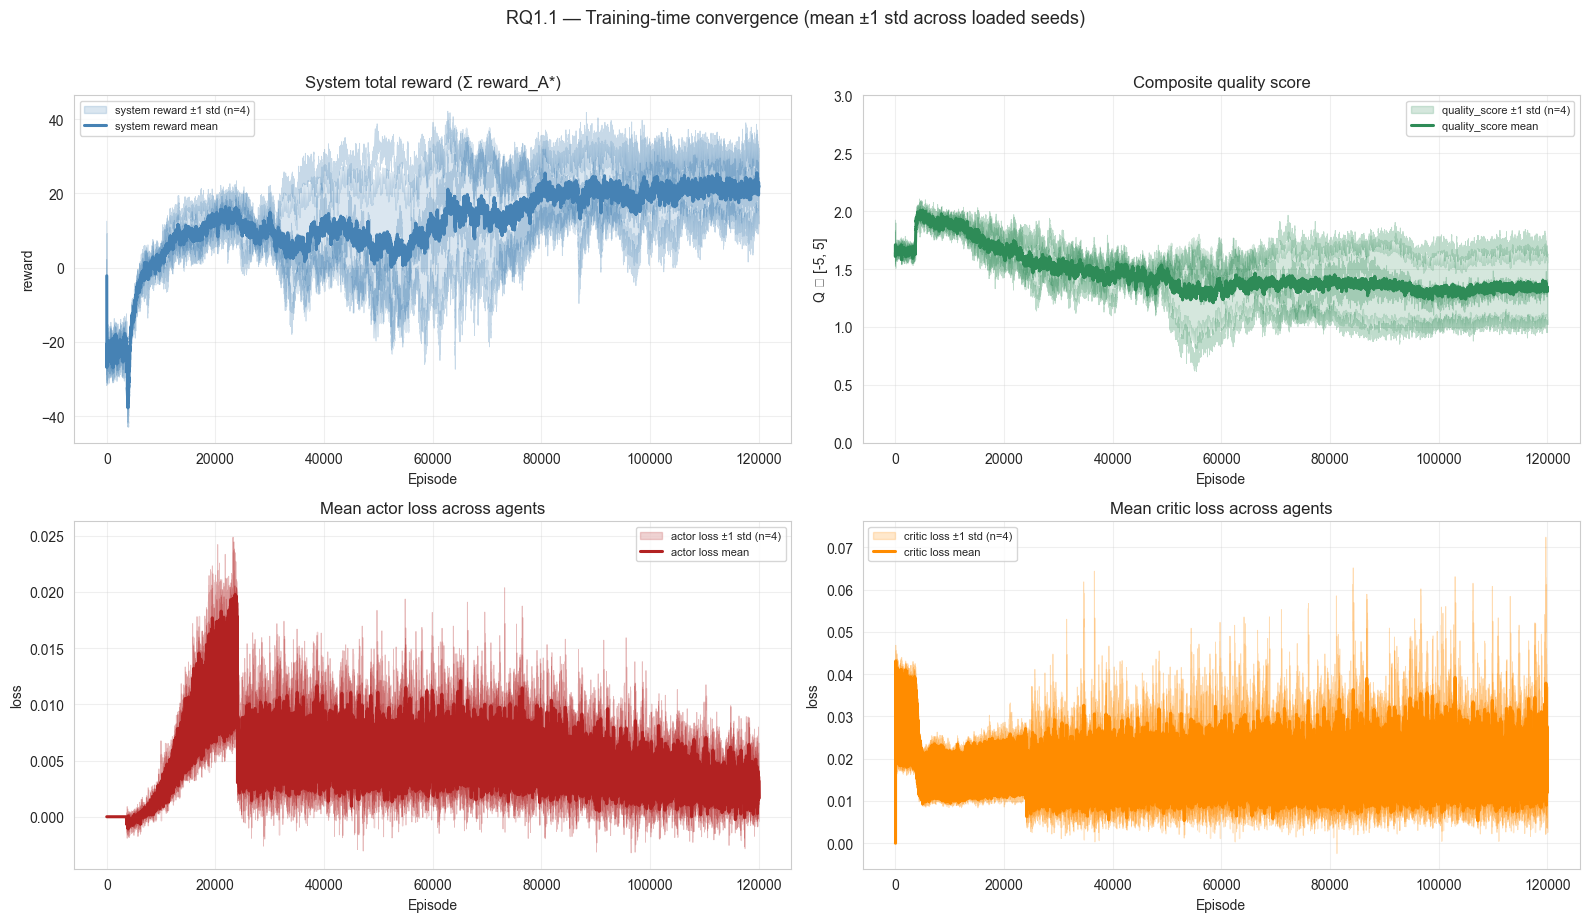

In [9]:
def _system_reward(df):
    cols = agent_cols(df, 'reward')
    return df[cols].sum(axis=1) if cols else pd.Series(dtype=float)

def _system_base_reward(df):
    cols = agent_cols(df, 'reward_base')
    return df[cols].sum(axis=1) if cols else pd.Series(dtype=float)

def _quality(df):
    return df['quality_score'] if 'quality_score' in df.columns else pd.Series(dtype=float)

def _mean_actor_loss(df):
    cols = agent_cols(df, 'actor_loss')
    return df[cols].mean(axis=1) if cols else pd.Series(dtype=float)

def _mean_critic_loss(df):
    cols = agent_cols(df, 'critic_loss')
    return df[cols].mean(axis=1) if cols else pd.Series(dtype=float)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fan_chart(stack_runs(_system_reward),      axes[0, 0], color='steelblue',  label='system reward')
axes[0, 0].set(title='System total reward (Σ reward_A*)', xlabel='Episode', ylabel='reward')

fan_chart(stack_runs(_quality),            axes[0, 1], color='seagreen',   label='quality_score')
axes[0, 1].set(title='Composite quality score', xlabel='Episode', ylabel='Q ∈ [-5, 5]')
axes[0, 1].set_ylim(0, 3)

fan_chart(stack_runs(_mean_actor_loss),    axes[1, 0], color='firebrick',  label='actor loss')
axes[1, 0].set(title='Mean actor loss across agents',  xlabel='Episode', ylabel='loss')

fan_chart(stack_runs(_mean_critic_loss),   axes[1, 1], color='darkorange', label='critic loss')
axes[1, 1].set(title='Mean critic loss across agents', xlabel='Episode', ylabel='loss')

plt.suptitle('RQ1.1 — Training-time convergence (mean ±1 std across loaded seeds)',
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


### RQ1.2 — Cross-seed reproducibility on headline metrics

In [10]:
# Per-seed converged-window means for a small set of headline metrics.
def _converged_metrics_for(run):
    ep = tail_episodes(run['ep_df'])
    yr = tail_year_rows(run)
    out = {}

    rew_cols = agent_cols(ep, 'reward')
    out['system_reward']     = float(ep[rew_cols].sum(axis=1).mean()) if rew_cols else np.nan
    out['quality_score']     = float(ep['quality_score'].mean()) if 'quality_score' in ep.columns else np.nan

    
    if 'clearing_price_last' in ep.columns:
        out['mean_clearing_price'] = float(ep['clearing_price_last'].mean())
    elif 'clearing_price' in yr.columns:
        out['mean_clearing_price'] = float(yr['clearing_price'].mean())
    else:
        out['mean_clearing_price'] = np.nan

    sf_cols = agent_cols(yr, 'shortfall')
    out['compliance_rate'] = float((yr[sf_cols] <= 1e-6).mean(axis=1).mean()) if sf_cols else np.nan

    pen_cols = agent_cols(ep, 'penalty')
    out['system_penalty']  = float(ep[pen_cols].sum(axis=1).mean()) if pen_cols else np.nan

    inv_cols = agent_cols(ep, 'invest_cost')
    out['system_invest']   = float(ep[inv_cols].sum(axis=1).mean()) if inv_cols else np.nan

    gf_cols = agent_cols(ep, 'green_frac')
    out['mean_final_green_frac'] = float(ep[gf_cols].mean(axis=1).mean()) if gf_cols else np.nan

    if 'secondary_volume' in ep.columns:
        out['secondary_volume'] = float(ep['secondary_volume'].mean())
    else:
        out['secondary_volume'] = np.nan

    return out

per_seed_rows = []
for k, run in runs.items():
    row = {'sweep': k[0], 'variant': k[1], 'seed': k[2]}
    row.update(_converged_metrics_for(run))
    per_seed_rows.append(row)
per_seed_df = pd.DataFrame(per_seed_rows)
print(f"Per-seed converged-window means (last {TAIL_EPISODES} episodes):")
display(per_seed_df.round(3))

agg_cols = ['system_reward', 'quality_score', 'mean_clearing_price', 'compliance_rate',
            'system_penalty', 'system_invest', 'mean_final_green_frac', 'secondary_volume']
summary = per_seed_df[agg_cols].agg(['mean', 'std', 'min', 'max']).round(3)
summary.loc['cv (%)'] = (summary.loc['std'] / summary.loc['mean'].abs() * 100).round(1)
print(f"\nCross-seed summary (n={len(per_seed_df)}):")
summary


Per-seed converged-window means (last 1000 episodes):


,sweep,variant,seed,system_reward,quality_score,mean_clearing_price,compliance_rate,system_penalty,system_invest,mean_final_green_frac,secondary_volume
0,default_seeds,default,1729,20.079,1.712,82.345,0.875,1920.884,5139.825,0.735,43.932
1,default_seeds,default,8191,31.476,1.331,58.164,0.853,2529.066,6426.351,0.765,40.209
2,default_seeds,default,6561,12.398,1.345,81.395,0.797,3793.327,6858.905,0.771,27.110
3,default_seeds,default,5041,24.875,1.015,48.424,0.787,4301.157,5121.147,0.748,30.116



Cross-seed summary (n=4):


,system_reward,quality_score,mean_clearing_price,compliance_rate,system_penalty,system_invest,mean_final_green_frac,secondary_volume
mean,22.207,1.351,67.582,0.828,3136.108,5886.557,0.755,35.342
std,8.037,0.285,16.975,0.043,1100.688,890.749,0.017,8.012
min,12.398,1.015,48.424,0.787,1920.884,5121.147,0.735,27.110
max,31.476,1.712,82.345,0.875,4301.157,6858.905,0.771,43.932
cv (%),36.200,21.100,25.100,5.200,35.100,15.100,2.300,22.700


**Reading the table.** A coefficient of variation (`cv (%)`) below
~10% on the headline outcomes (mean clearing price, compliance rate,
mean final green fraction) is the bar we use to call the simulation
*reproducible* across seeds — anything significantly larger means the
RQ2 / RQ3 claims need to be hedged seed-by-seed.

### RQ1.3 — Behavioural credibility in the converged window

C:\Users\danie\AppData\Local\Temp\ipykernel_5056\2922376889.py:36: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\danie\AppData\Local\Temp\ipykernel_5056\2922376889.py:36: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


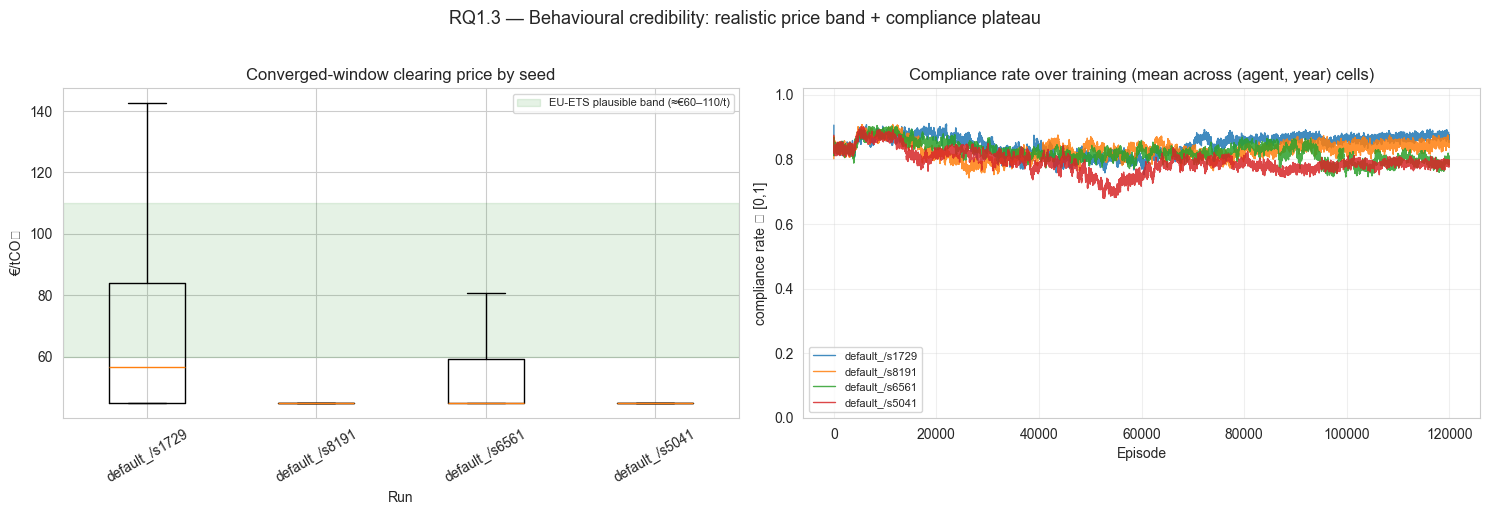

In [11]:
# (a) Final-window clearing-price distribution; (b) per-seed compliance plateau.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
boxes = []
labels = []
for k, run in runs.items():
    yr = tail_year_rows(run)
    if 'clearing_price' not in yr.columns or yr.empty:
        continue
    boxes.append(yr['clearing_price'].dropna().values)
    labels.append(f"{k[0][:8]}/s{k[2]}")
if boxes:
    ax.boxplot(boxes, tick_labels=labels, showfliers=False)
    ax.axhspan(60, 110, color='green', alpha=0.10, label='EU-ETS plausible band (≈€60–110/t)')
    ax.set(title='Converged-window clearing price by seed', ylabel='€/tCO₂', xlabel='Run')
    ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=30)
else:
    ax.text(0.5, 0.5, 'No clearing_price column in any year_log', ha='center', va='center', transform=ax.transAxes)

ax = axes[1]
for k, run in runs.items():
    sf_cols = agent_cols(run['yr_df'], 'shortfall')
    if not sf_cols or 'episode' not in run['yr_df'].columns:
        continue
    rate = (run['yr_df'][sf_cols] <= 1e-6).mean(axis=1).groupby(run['yr_df']['episode']).mean()
    rate_smooth = rate.rolling(ROLL, min_periods=1).mean()
    ax.plot(rate_smooth.index, rate_smooth.values, lw=1.0, alpha=0.85,
            label=f"{k[0][:8]}/s{k[2]}")
ax.set(title='Compliance rate over training (mean across (agent, year) cells)',
       xlabel='Episode', ylabel='compliance rate ∈ [0,1]')
ax.set_ylim(0.0, 1.02); ax.grid(True, alpha=0.3); ax.legend(fontsize=8, loc='best')

plt.suptitle('RQ1.3 — Behavioural credibility: realistic price band + compliance plateau',
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


### RQ1.4 — Pathology check: warnings in the converged window

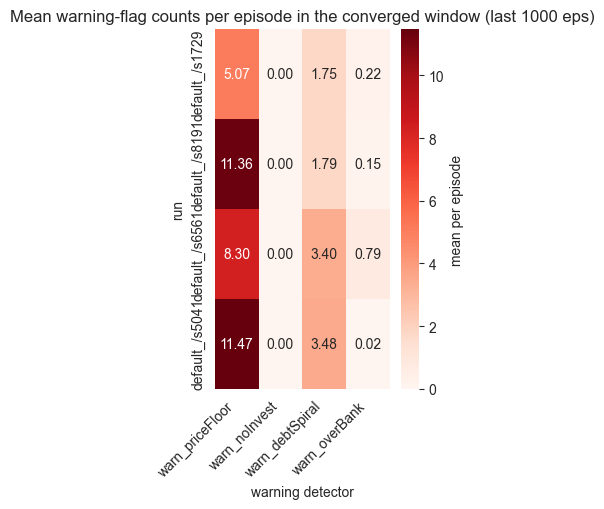

Inspected 6 warning columns; showing only the 4 with > 0 events.


In [12]:
# Sum the warn_* columns across the converged window for each run.
WARN_PREFIX = 'warn_'
warn_rows = []
warn_columns_seen = set()
for k, run in runs.items():
    ep = tail_episodes(run['ep_df'])
    warn_cols = [c for c in ep.columns if c.startswith(WARN_PREFIX)]
    warn_columns_seen.update(warn_cols)
    if not warn_cols:
        continue
    row = {'run': f"{k[0][:8]}/s{k[2]}"}
    # Per-episode mean warning count (interpretable as "how often per episode does this warn fire").
    row.update({c: float(ep[c].mean()) for c in warn_cols})
    warn_rows.append(row)

if warn_rows:
    warn_df = pd.DataFrame(warn_rows).set_index('run').fillna(0.0)
    # Drop columns that are exactly zero across all runs.
    warn_df = warn_df.loc[:, (warn_df > 0).any(axis=0)]
    fig, ax = plt.subplots(figsize=(min(14, 1.5 + 0.45 * len(warn_df.columns)), 4 + 0.3 * len(warn_df)))
    if warn_df.empty:
        ax.text(0.5, 0.5, 'No non-zero warnings in the converged window — clean run.',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.axis('off')
    else:
        sns.heatmap(warn_df.round(2), annot=True, cmap='Reds', fmt='.2f', cbar_kws={'label': 'mean per episode'}, ax=ax)
        ax.set(title=f'Mean warning-flag counts per episode in the converged window (last {TAIL_EPISODES} eps)',
               xlabel='warning detector', ylabel='run')
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout(); plt.show()
    print(f'Inspected {len(warn_columns_seen)} warning columns; showing only the {warn_df.shape[1]} with > 0 events.')
else:
    print('No warn_* columns present in episode logs.')


### RQ1.5 — Whole-training overview (all loaded runs)

A single 2×2 panel summarising the entire training trajectory across
*every* loaded run (i.e. before the §RQ2 default-seeds filter kicks
in). Top-left: system reward; top-right: final-year clearing price
(per-episode `clearing_price` at the maximum simulation year); bottom-
left: compliance rate; bottom-right: mean green generation share. The
shaded band on each panel is **±1 standard deviation around the mean**
of the loaded runs at every smoothed episode, with thin lines showing the
individual runs.

The clearing-price panel adds two horizontal references taken from
`configs/default.yaml`: the auction reserve (floor) price and the
final-year penalty rate (`penalty.rate × (1 + inflation_rate)^(N_YEARS
− 1)`). The green-share panel marks the cross-agent mean of the
*initial* (display year 1) green fractions read from
`companies.initial_mix` × `technologies.is_green`. Compliance and
green-share use a tight padded y-axis so changes during training are
easy to read.

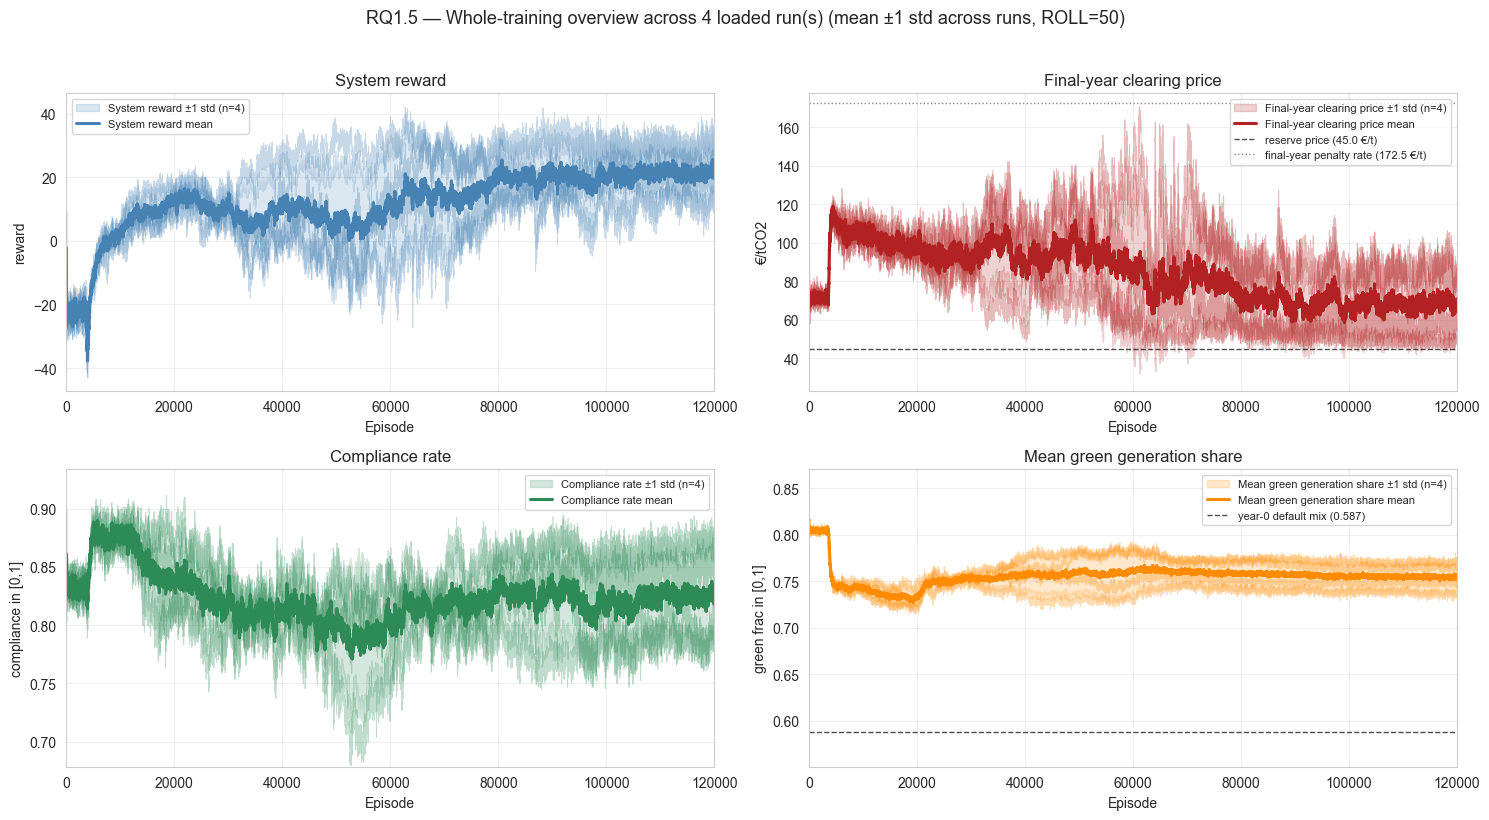

In [13]:
# 2x2 whole-training overview across all loaded runs.
# Episode-axis fan charts (mean ±1 std band across runs, smoothed by ROLL).

def _final_year_clearing_by_ep(run):
    """Per-episode clearing price in the final simulation year."""
    yr = run['yr_df']
    needed = {'clearing_price', 'episode', 'year'}
    if not needed.issubset(yr.columns):
        return pd.Series(dtype=float)
    idx = yr.groupby('episode')['year'].idxmax()
    s = yr.loc[idx].set_index('episode')['clearing_price']
    return s.sort_index()

def _compliance_rate_by_ep(run):
    yr = run['yr_df']
    sf_cols = agent_cols(yr, 'shortfall')
    if not sf_cols or 'episode' not in yr.columns:
        return pd.Series(dtype=float)
    return (yr[sf_cols] <= 1e-6).mean(axis=1).groupby(yr['episode']).mean()

def _mean_green_frac_by_ep(df):
    cols = agent_cols(df, 'green_frac')
    return df[cols].mean(axis=1) if cols else pd.Series(dtype=float)

# Display year 1 (start-of-simulation) mean green fraction from the default config.
_mix = REFERENCE_CONFIG.get('companies', {}).get('initial_mix', []) or []
_is_green = REFERENCE_CONFIG.get('technologies', {}).get('is_green', []) or []
_green_idx = [i for i, g in enumerate(_is_green) if g]
if _mix and _green_idx:
    _agent_start_green = [sum(row[i] for i in _green_idx) for row in _mix[:N_AGENTS]]
    START_GREEN_FRAC = float(np.mean(_agent_start_green))
else:
    START_GREEN_FRAC = float('nan')

def _std_fan(df_wide, ax, *, color, label, smooth=ROLL):
    """Plot mean ±1 std band (across runs) of `df_wide` on `ax`, plus thin per-run lines."""
    if df_wide.empty:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
        return
    sm = df_wide.rolling(smooth, min_periods=1).mean()
    mean = sm.mean(axis=1)
    std = sm.std(axis=1).fillna(0.0)
    n = sm.shape[1]
    for col in sm.columns:
        ax.plot(sm.index, sm[col].values, color=color, lw=0.6, alpha=0.30)
    ax.fill_between(sm.index, (mean - std).values, (mean + std).values,
                    color=color, alpha=0.20, label=f'{label} ±1 std (n={n})')
    ax.plot(sm.index, mean.values, color=color, lw=2.2, label=f'{label} mean')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='best')

def _padded_ylim_std(df_wide, *, smooth=ROLL, pad_frac=0.10, include=None,
                     lo_clip=None, hi_clip=None):
    """Tight padded (ymin, ymax) around the smoothed mean ±1 std band."""
    if df_wide.empty:
        return None
    sm = df_wide.rolling(smooth, min_periods=1).mean()
    mean = sm.mean(axis=1)
    std = sm.std(axis=1).fillna(0.0)
    lo = float((mean - std).min())
    hi = float((mean + std).max())
    if include is not None and not np.isnan(include):
        lo = min(lo, float(include))
        hi = max(hi, float(include))
    span = max(hi - lo, 1e-9)
    pad = pad_frac * span
    ylo, yhi = lo - pad, hi + pad
    if lo_clip is not None:
        ylo = max(ylo, lo_clip)
    if hi_clip is not None:
        yhi = min(yhi, hi_clip)
    return (ylo, yhi)

# Reserve (auction floor) price and final-year penalty rate from the
# default config — used as horizontal reference lines on the clearing-
# price panel, and reported in the companion table.
_ets_cfg = REFERENCE_CONFIG.get('ets', {}) or {}
RESERVE_PRICE = float(_ets_cfg.get('reserve_price', float('nan')))
_pen_cfg = REFERENCE_CONFIG.get('penalty', {}) or {}
_pen_base = float(_pen_cfg.get('rate', float('nan')))
_pen_infl = float(_pen_cfg.get('inflation_rate', 0.0) or 0.0)
# Final display year is N_YEARS; inflation still accrues over N_YEARS - 1 intervals.
FINAL_YEAR_PENALTY_RATE = (
    _pen_base * (1.0 + _pen_infl) ** max(N_YEARS - 1, 0)
    if not np.isnan(_pen_base) else float('nan')
)

# Episode-indexed wide frames (one column per run).
overview_panels = {
    'System reward':                    (stack_runs(_system_reward, source='ep'),                'reward',                 'steelblue'),
    'Final-year clearing price':        (stack_runs(_final_year_clearing_by_ep, source='run'),   '€/tCO2',                 'firebrick'),
    'Compliance rate':                  (stack_runs(_compliance_rate_by_ep, source='run'),       'compliance in [0,1]',     'seagreen'),
    'Mean green generation share':      (stack_runs(_mean_green_frac_by_ep, source='ep'),        'green frac in [0,1]',     'darkorange'),
}

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for ax, (title, (df_wide, ylabel, color)) in zip(axes.ravel(), overview_panels.items()):
    _std_fan(df_wide, ax, color=color, label=title)
    ax.set(title=title, xlabel='Episode', ylabel=ylabel)
    ax.margins(x=0)
    ax.set_xticks(range(0, 120001, 20000))
    
    if title == 'Final-year clearing price':
        _refs = [v for v in (RESERVE_PRICE, FINAL_YEAR_PENALTY_RATE) if not np.isnan(v)]
        ylim = _padded_ylim_std(df_wide, pad_frac=0.08,
                                include=None)
        if ylim is not None:
            lo, hi = ylim
            for r in _refs:
                lo = min(lo, r); hi = max(hi, r)
            ax.set_ylim(lo, hi+5)
        if not np.isnan(RESERVE_PRICE):
            ax.axhline(RESERVE_PRICE, color='black', lw=1.0, linestyle='--', alpha=0.7,
                       label=f'reserve price ({RESERVE_PRICE:.1f} €/t)')
        if not np.isnan(FINAL_YEAR_PENALTY_RATE):
            ax.axhline(FINAL_YEAR_PENALTY_RATE, color='dimgray', lw=1.0, linestyle=':', alpha=0.8,
                       label=f'final-year penalty rate ({FINAL_YEAR_PENALTY_RATE:.1f} €/t)')
        if _refs:
            ax.legend(fontsize=8, loc='best')
    elif title == 'Compliance rate':
        ylim = _padded_ylim_std(df_wide, pad_frac=0.15, lo_clip=0.0, hi_clip=1.02)
        if ylim is not None:
            ax.set_ylim(*ylim)
    elif title == 'Mean green generation share':
        ylim = _padded_ylim_std(df_wide, pad_frac=0.15, include=START_GREEN_FRAC,
                                lo_clip=0.0, hi_clip=1.0)
        if ylim is not None:
            ax.set_ylim(*ylim)
        if not np.isnan(START_GREEN_FRAC):
            ax.axhline(START_GREEN_FRAC, color='black', lw=1.0, linestyle='--', alpha=0.7,
                       label=f'year-0 default mix ({START_GREEN_FRAC:.3f})')
            ax.legend(fontsize=8, loc='best')

plt.suptitle(f'RQ1.5 — Whole-training overview across {len(runs)} loaded run(s) '
             f'(mean ±1 std across runs, ROLL={ROLL})', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

In [14]:
# Companion data table for the RQ1.5 overview figure: absolute values
# of the smoothed mean series (the line drawn in each panel) reduced
# to the headline scalars used in thesis prose.

_overview_rows = []
for title, (df_wide, ylabel, _color) in overview_panels.items():
    if df_wide.empty:
        _overview_rows.append({
            'panel': title, 'unit': ylabel, 'n_runs': 0, 'episodes': 0,
            'mean': np.nan, 'median': np.nan, 'std': np.nan,
            'min': np.nan, 'max': np.nan,
            'first': np.nan, 'last': np.nan,
        })
        continue
    sm = df_wide.rolling(ROLL, min_periods=1).mean()
    mean = sm.mean(axis=1)
    _overview_rows.append({
        'panel': title, 'unit': ylabel,
        'n_runs': int(sm.shape[1]), 'episodes': int(len(mean)),
        'mean': float(mean.mean()), 'median': float(mean.median()),
        'std': float(mean.std()), 'min': float(mean.min()), 'max': float(mean.max()),
        'first': float(mean.iloc[0]), 'last': float(mean.iloc[-1]),
    })
overview_df = pd.DataFrame(_overview_rows)
print('Whole-training overview — summary of the smoothed mean series shown in each panel:')
display(overview_df.round(4))
print('Reference lines used in the figure:')
print(f'  Year-1 default-mix mean green fraction: {START_GREEN_FRAC:.4f}')
print(f'  Auction reserve (floor) price:          {RESERVE_PRICE:.2f} €/t')
print(f'  Final-year penalty rate (year {N_YEARS}, base {_pen_base:.2f} @ {_pen_infl:.1%}/yr): '
      f'{FINAL_YEAR_PENALTY_RATE:.2f} €/t')

Whole-training overview — summary of the smoothed mean series shown in each panel:


,panel,unit,n_runs,episodes,mean,median,std,min,max,first,last
0,System reward,reward,4,120000,11.9544,12.7906,9.7120,-37.7479,25.5983,-2.1723,22.8865
1,Final-year clearing price,€/tCO2,4,120000,83.7786,84.3478,13.7480,58.1888,119.0259,58.1888,67.0147
2,Compliance rate,"compliance in [0,1]",4,120000,0.8232,0.8215,0.0206,0.7709,0.8894,0.8516,0.8221
3,Mean green generation share,"green frac in [0,1]",4,120000,0.7554,0.7560,0.0115,0.7271,0.8165,0.8158,0.7534


Reference lines used in the figure:
  Year-1 default-mix mean green fraction: 0.5875
  Auction reserve (floor) price:          45.00 €/t
  Final-year penalty rate (year 12, base 138.75 @ 2.0%/yr): 172.52 €/t


**RQ1 summary.** The convergence panels (1.1) plus the cross-seed
table (1.2) and credibility plots (1.3 / 1.4) together provide the
evidence base for Sub-RQ 1: with the default config, the simulation
converges, reproduces a plausible EU-ETS price band and compliance
plateau across loaded seeds, and the converged window is not dominated
by pathology warnings.

---

## §RQ2 — Regulatory-Mechanism Behaviour Within the Default Config

> **Scope caveat.** Real *sensitivity* analysis (cap LRF / MSR on/off /
> penalty level) requires sweep variants and is deferred to a separate
> experiments notebook. What we *can* show with default-config data is a
> descriptive characterisation of how the regulatory mechanisms operate
> in equilibrium: how the cap maps to the clearing price, how the MSR
> withholds and releases, when the penalty actually binds, and how
> quickly the system decarbonises. This is the baseline that the
> sensitivity analysis will perturb.

Four panels:

* **2.1** — Cap → price linkage by year (mean across episodes/seeds in the converged window).
* **2.2** — TNAC trajectory and MSR reserve / flow behaviour.
* **2.3** — Penalty incidence: how often does it bind, and how big is it when it does?
* **2.4** — Decarbonisation pace: green-share trajectory and MAC-driven reductions.

### RQ2.1 — Cap and clearing-price trajectory by year

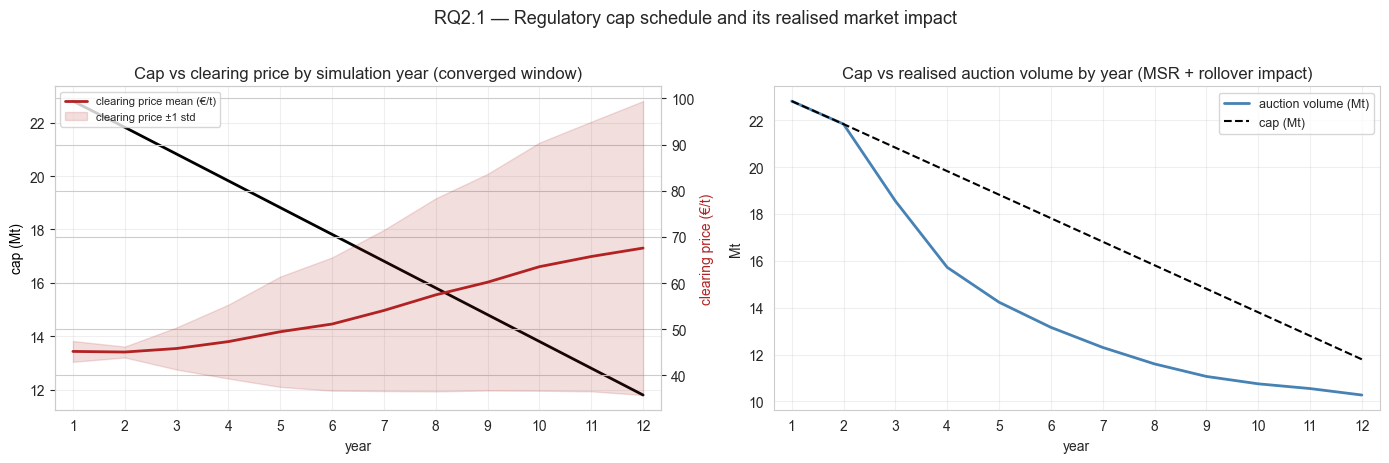

In [15]:
# Average across all seeds and converged-window episodes.
year_frames = []
for k, run in runs.items():
    yr = tail_year_rows(run)
    if yr.empty: continue
    keep = ['episode', 'year', 'cap', 'clearing_price', 'auction_volume', 'tnac',
            'msr_reserve', 'msr_withhold_this_year', 'msr_release_this_year',
            'msr_total_cancelled', 'secondary_price']
    keep = [c for c in keep if c in yr.columns]
    if 'year' not in keep: continue
    df = yr[keep].copy(); df['__seed__'] = k[2]
    year_frames.append(df)
if not year_frames:
    raise RuntimeError('No year_log data available — RQ2 requires year-level logs.')
yr_pool = pd.concat(year_frames, ignore_index=True)

by_year = yr_pool.groupby('year').agg(['mean', 'std'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
if ('cap', 'mean') in by_year.columns:
    ax.plot(by_year.index, by_year[('cap', 'mean')], lw=2, color='black', label='cap (Mt, mean)')
    ax.set_ylabel('cap (Mt)', color='black')
    ax2 = ax.twinx()
    if ('clearing_price', 'mean') in by_year.columns:
        clearing_mean = by_year[('clearing_price', 'mean')]
        clearing_std = by_year[('clearing_price', 'std')].fillna(0.0)
        ax2.plot(by_year.index, clearing_mean, lw=2, color='firebrick',
                 label='clearing price mean (€/t)')
        ax2.fill_between(by_year.index,
                         (clearing_mean - clearing_std).values,
                         (clearing_mean + clearing_std).values,
                         color='firebrick', alpha=0.15,
                         label='clearing price ±1 std')
        ax2.set_ylabel('clearing price (€/t)', color='firebrick')
        ax2.legend(fontsize=8, loc='best')
    ax.set(title='Cap vs clearing price by simulation year (converged window)', xlabel='year')
    ax.grid(True, alpha=0.3)
    format_year_axis(ax)

ax = axes[1]
if ('auction_volume', 'mean') in by_year.columns:
    ax.plot(by_year.index, by_year[('auction_volume', 'mean')], lw=2, color='steelblue', label='auction volume (Mt)')
if ('cap', 'mean') in by_year.columns:
    ax.plot(by_year.index, by_year[('cap', 'mean')], lw=1.5, color='black', linestyle='--', label='cap (Mt)')
ax.set(title='Cap vs realised auction volume by year (MSR + rollover impact)',
       xlabel='year', ylabel='Mt')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
format_year_axis(ax)

plt.suptitle('RQ2.1 — Regulatory cap schedule and its realised market impact',
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

### RQ2.2 — TNAC, MSR reserve, and MSR flow

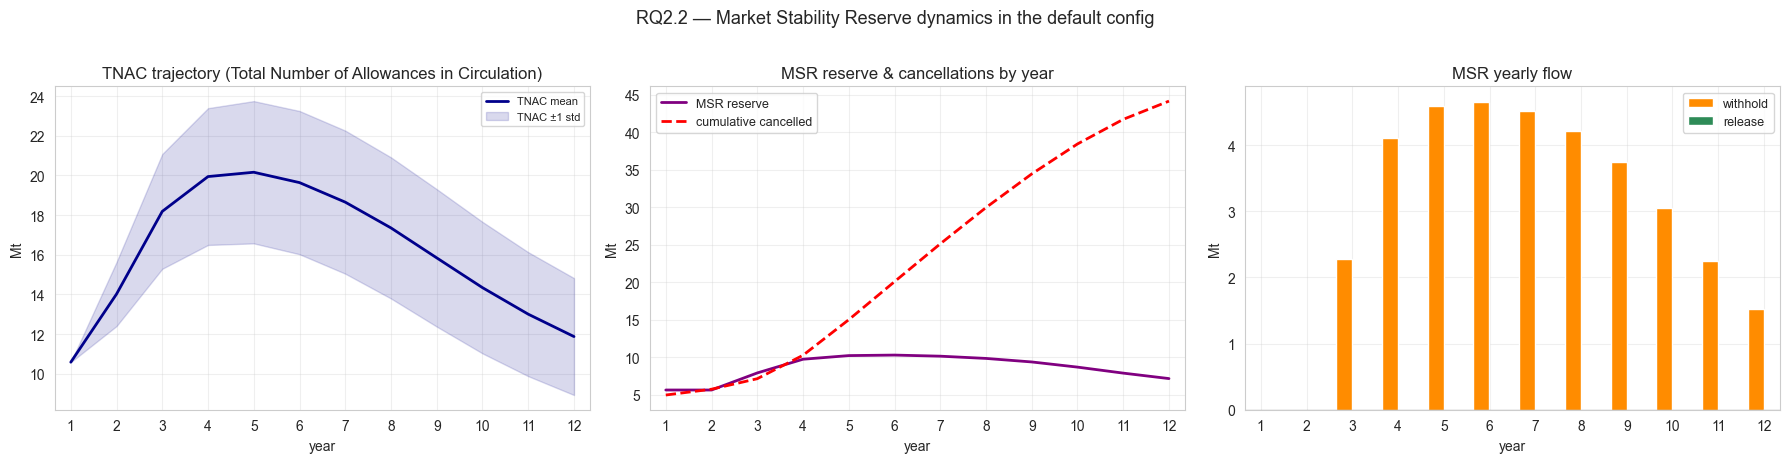

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

ax = axes[0]
if ('tnac', 'mean') in by_year.columns:
    tnac_mean = by_year[('tnac', 'mean')]
    tnac_std = by_year[('tnac', 'std')].fillna(0.0)
    ax.plot(by_year.index, tnac_mean, lw=2, color='darkblue', label='TNAC mean')
    ax.fill_between(by_year.index,
                    (tnac_mean - tnac_std).values,
                    (tnac_mean + tnac_std).values,
                    color='darkblue', alpha=0.15, label='TNAC ±1 std')
    ax.set(title='TNAC trajectory (Total Number of Allowances in Circulation)',
           xlabel='year', ylabel='Mt')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
if ('msr_reserve', 'mean') in by_year.columns:
    ax.plot(by_year.index, by_year[('msr_reserve', 'mean')], lw=2, color='purple', label='MSR reserve')
if ('msr_total_cancelled', 'mean') in by_year.columns:
    ax.plot(by_year.index, by_year[('msr_total_cancelled', 'mean')], lw=2, color='red',
            linestyle='--', label='cumulative cancelled')
ax.set(title='MSR reserve & cancellations by year', xlabel='year', ylabel='Mt')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[2]
years = by_year.index.values
if ('msr_withhold_this_year', 'mean') in by_year.columns:
    wh = by_year[('msr_withhold_this_year', 'mean')]
    ax.bar(years - 0.18, wh, width=0.35, color='darkorange', label='withhold')
if ('msr_release_this_year', 'mean') in by_year.columns:
    rel = by_year[('msr_release_this_year', 'mean')]
    ax.bar(years + 0.18, rel, width=0.35, color='seagreen', label='release')
ax.axhline(0, color='black', lw=0.8)
ax.set(title='MSR yearly flow', xlabel='year', ylabel='Mt')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
for ax in axes:
    format_year_axis(ax)

plt.suptitle('RQ2.2 — Market Stability Reserve dynamics in the default config',
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

### RQ2.3 — Penalty incidence and magnitude

Penalty incidence in the converged window (last 1000 episodes):


,run,pct_cells_short,mean_shortfall_when_short_Mt,mean_penalty_when_short_Meur
0,default_/s1729,12.494,1.002,160.154
1,default_/s8191,14.730,1.123,178.846
2,default_/s6561,20.312,1.229,194.530
3,default_/s5041,21.330,1.333,210.048


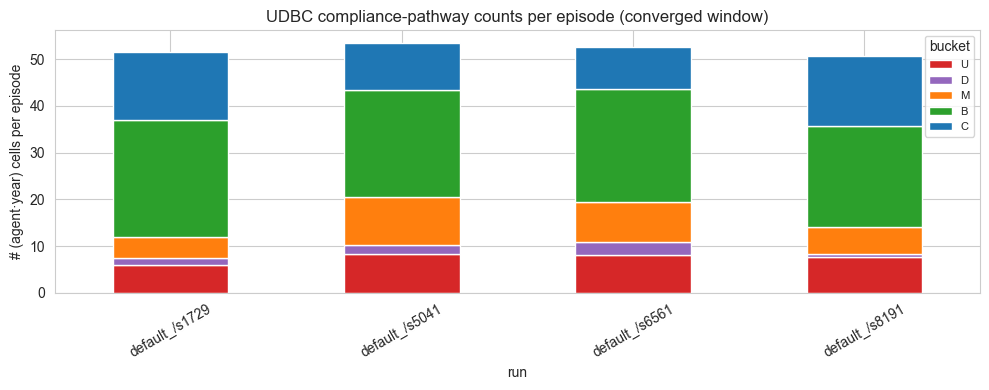

U = pure under-bid; D = pure debt-cascade; M = mixed; B = bank-covered; C = secondary-covered.


In [17]:
# (a) Share of (agent, year) cells with shortfall > 0; (b) mean per-cell penalty when it bites.
share_rows = []
for k, run in runs.items():
    yr = tail_year_rows(run)
    sf_cols = agent_cols(yr, 'shortfall')
    pen_cols = agent_cols(yr, 'penalty')
    if not sf_cols: continue
    sf = yr[sf_cols].values.flatten()
    pen = yr[pen_cols].values.flatten() if pen_cols else None
    nc_mask = sf > 1e-6
    share_rows.append({
        'run': f'{k[0][:8]}/s{k[2]}',
        'pct_cells_short': 100.0 * nc_mask.mean() if sf.size else np.nan,
        'mean_shortfall_when_short_Mt': float(sf[nc_mask].mean()) if nc_mask.any() else 0.0,
        'mean_penalty_when_short_Meur': float(pen[nc_mask].mean()) if (pen is not None and nc_mask.any()) else 0.0,
    })
share_df = pd.DataFrame(share_rows)
print(f'Penalty incidence in the converged window (last {TAIL_EPISODES} episodes):')
display(share_df.round(3))

# UDBC mix at the system level (averaged across seeds).
ud_rows = []
for k, run in runs.items():
    ep = tail_episodes(run['ep_df'])
    for b in ['U', 'D', 'M', 'B', 'C']:
        cols = agent_cols(ep, f'udbc_{b}_total')
        if cols:
            ud_rows.append({'run': f'{k[0][:8]}/s{k[2]}', 'bucket': b,
                            'mean_total_per_episode': float(ep[cols].sum(axis=1).mean())})
if ud_rows:
    ud_df = pd.DataFrame(ud_rows).pivot(index='run', columns='bucket', values='mean_total_per_episode').fillna(0.0)
    ud_df = ud_df[[c for c in ['U', 'D', 'M', 'B', 'C'] if c in ud_df.columns]]
    fig, ax = plt.subplots(figsize=(10, 4))
    ud_df.plot(kind='bar', stacked=True, ax=ax,
               color=['#d62728', '#9467bd', '#ff7f0e', '#2ca02c', '#1f77b4'])
    ax.set(title='UDBC compliance-pathway counts per episode (converged window)',
           ylabel='# (agent·year) cells per episode', xlabel='run')
    ax.legend(title='bucket', fontsize=8); ax.tick_params(axis='x', rotation=30)
    plt.tight_layout(); plt.show()
    print('U = pure under-bid; D = pure debt-cascade; M = mixed; B = bank-covered; C = secondary-covered.')


### RQ2.4 — Decarbonisation pace

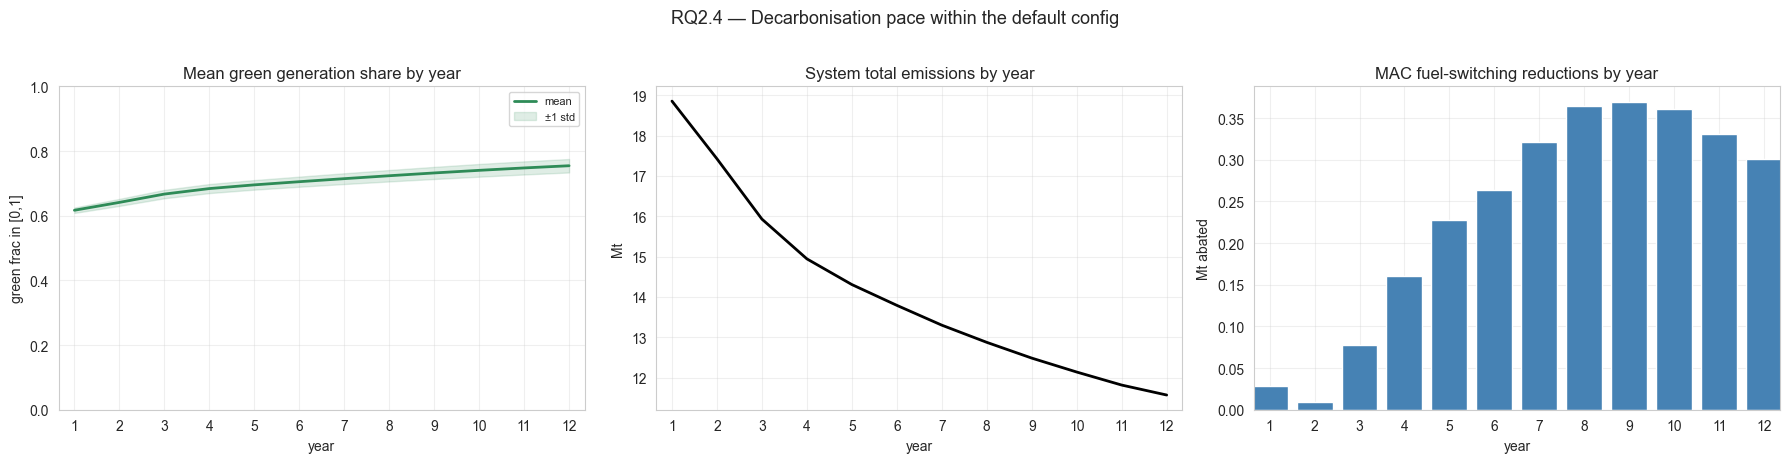

In [18]:
# (a) Mean green_frac by year across episodes/seeds; (b) MAC reduction by year.
yr_pool2 = []
for k, run in runs.items():
    yr = tail_year_rows(run)
    keep = ['year']
    gf_cols = agent_cols(yr, 'green_frac')
    mac_cols = agent_cols(yr, 'mac_reduction')
    em_cols = agent_cols(yr, 'emissions')
    if 'year' not in yr.columns: continue
    df = yr[['year']].copy()
    if gf_cols:  df['green_frac_mean'] = yr[gf_cols].mean(axis=1)
    if mac_cols: df['mac_reduction_total'] = yr[mac_cols].sum(axis=1)
    if em_cols:  df['emissions_total'] = yr[em_cols].sum(axis=1)
    yr_pool2.append(df)
if yr_pool2:
    pool = pd.concat(yr_pool2, ignore_index=True).groupby('year').agg(['mean', 'std'])

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    ax = axes[0]
    if ('green_frac_mean', 'mean') in pool.columns:
        green_mean = pool[('green_frac_mean', 'mean')]
        green_std = pool[('green_frac_mean', 'std')].fillna(0.0)
        ax.plot(pool.index, green_mean, lw=2, color='seagreen', label='mean')
        ax.fill_between(pool.index,
                        (green_mean - green_std).values,
                        (green_mean + green_std).values,
                        color='seagreen', alpha=0.15, label='±1 std')
        ax.set(title='Mean green generation share by year', xlabel='year', ylabel='green frac in [0,1]')
        ax.set_ylim(0, 1); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[1]
    if ('emissions_total', 'mean') in pool.columns:
        ax.plot(pool.index, pool[('emissions_total', 'mean')], lw=2, color='black')
        ax.set(title='System total emissions by year', xlabel='year', ylabel='Mt')
        ax.grid(True, alpha=0.3)

    ax = axes[2]
    if ('mac_reduction_total', 'mean') in pool.columns:
        ax.bar(pool.index, pool[('mac_reduction_total', 'mean')], color='steelblue')
        ax.set(title='MAC fuel-switching reductions by year', xlabel='year', ylabel='Mt abated')
        ax.grid(True, alpha=0.3)

    for ax in axes:
        format_year_axis(ax)

    plt.suptitle('RQ2.4 — Decarbonisation pace within the default config',
                 fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()

**RQ2 summary.** Within the default config, RQ2.1–2.4 give the
*descriptive* baseline of how cap, MSR, penalty, and emission outcomes
move together. The sensitivity question — *would these trajectories
look qualitatively different under a tighter LRF, or with the MSR off?*
— is what the cross-config experiments notebook will answer.

---

## §RQ3 — Strategic Behaviour and Aggregation

The default config crosses 4 archetypes (coal-heavy, gas-dominant,
transitioner, green-leader) with 2 reward weightings (pure financial,
balanced ESG). That gives us the financial-vs-environmental contrast
that RQ3 asks about, *inside one config*.

Five panels:

* **3.1** — Bidding behaviour by archetype × weighting.
* **3.2** — Investment behaviour by archetype × weighting.
* **3.3** — Secondary-market role by archetype.
* **3.4** — UDBC compliance pathway by archetype.
* **3.5** — Reward decomposition (financial vs ESG vs penalty) by weighting.

### RQ3.1 — Bidding behaviour by archetype × reward-weighting

Per-(run, agent) rows: 32


C:\Users\danie\AppData\Local\Temp\ipykernel_5056\309587121.py:55: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


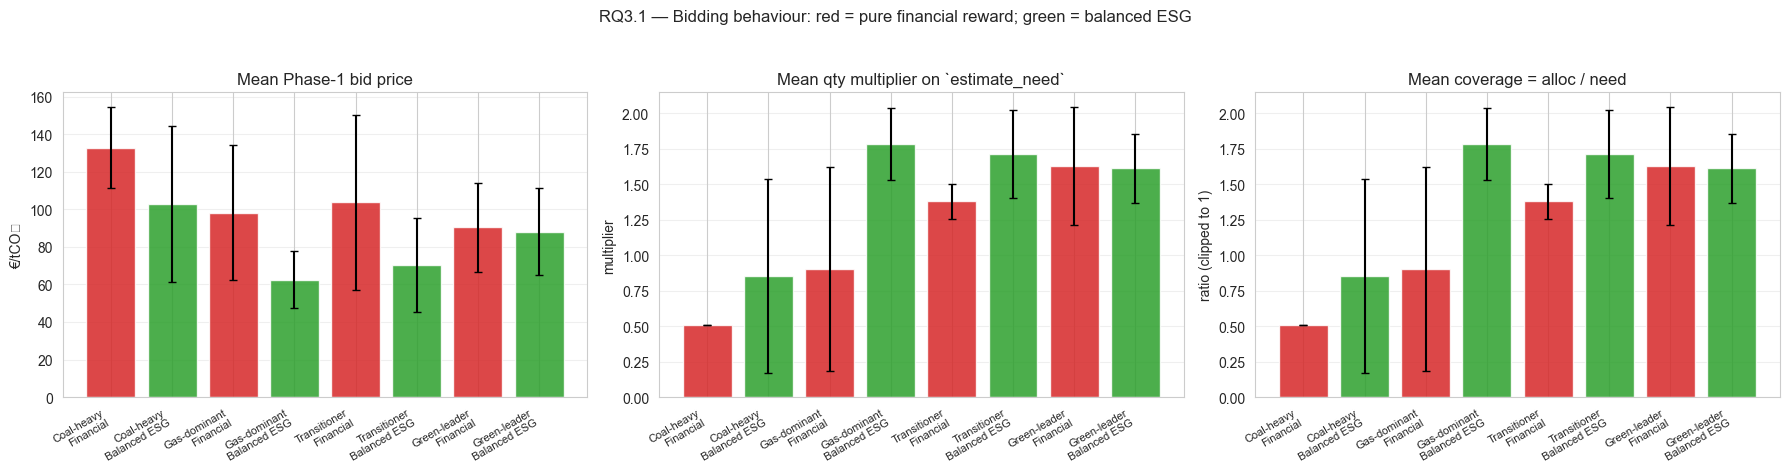

In [19]:
# Per-agent converged-window means, then group by (archetype, weighting).
def _per_agent_table(run, episode_cols, year_cols):
    """Return list of dicts (one per agent) with mean values from converged window."""
    ep = tail_episodes(run['ep_df'])
    yr = tail_year_rows(run)
    rows = []
    for i in range(N_AGENTS):
        row = {'agent_idx': i, 'archetype': _agent_archetype(i), 'weighting': _agent_weighting(i)}
        for prefix in episode_cols:
            col = f'{prefix}_A{i+1}'
            row[prefix] = float(ep[col].mean()) if col in ep.columns else np.nan
        for prefix in year_cols:
            col = f'{prefix}_A{i+1}'
            row[prefix] = float(yr[col].mean()) if col in yr.columns else np.nan
        rows.append(row)
    return rows

agent_rows = []
for k, run in runs.items():
    for r in _per_agent_table(
        run,
        episode_cols=['bid_price', 'avg_bid_mult', 'avg_bid_coverage',
                      'sec_buy_vol', 'sec_sell_vol', 'sec_buy_avg_px', 'sec_sell_avg_px',
                      'sec_buy_years', 'sec_sell_years',
                      'invest_cost', 'green_frac', 'delta_green',
                      'mean_alloc', 'penalty', 'shortfall', 'reward', 'reward_base',
                      'inv_onshore_share', 'inv_offshore_share', 'inv_solar_share'],
        year_cols=['mac_reduction', 'mac_cost'],
    ):
        r.update({'sweep': k[0], 'seed': k[2]})
        agent_rows.append(r)
agent_df = pd.DataFrame(agent_rows)
print(f'Per-(run, agent) rows: {len(agent_df)}')

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
order = [(arch, w) for arch in ARCHETYPES for w in ['Financial', 'Balanced ESG']]
labels = [f'{a}\n{w}' for a, w in order]

def _bar(ax, col, title, ylabel):
    means = []; stds = []
    for arch, w in order:
        sub = agent_df[(agent_df['archetype'] == arch) & (agent_df['weighting'] == w)][col]
        means.append(sub.mean()); stds.append(sub.std())
    x = np.arange(len(order))
    colors = ['#d62728' if w == 'Financial' else '#2ca02c' for _, w in order]
    ax.bar(x, means, yerr=stds, color=colors, capsize=3, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8, rotation=30, ha='right')
    ax.set(title=title, ylabel=ylabel); ax.grid(True, alpha=0.3, axis='y')

_bar(axes[0], 'bid_price',         'Mean Phase-1 bid price', '€/tCO₂')
_bar(axes[1], 'avg_bid_mult',      'Mean qty multiplier on `estimate_need`', 'multiplier')
_bar(axes[2], 'avg_bid_coverage',  'Mean coverage = alloc / need', 'ratio (clipped to 1)')
plt.suptitle('RQ3.1 — Bidding behaviour: red = pure financial reward; green = balanced ESG',
             fontsize=12, y=1.04)
plt.tight_layout(); plt.show()


### RQ3.2 — Investment behaviour

C:\Users\danie\AppData\Local\Temp\ipykernel_5056\3890071108.py:7: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


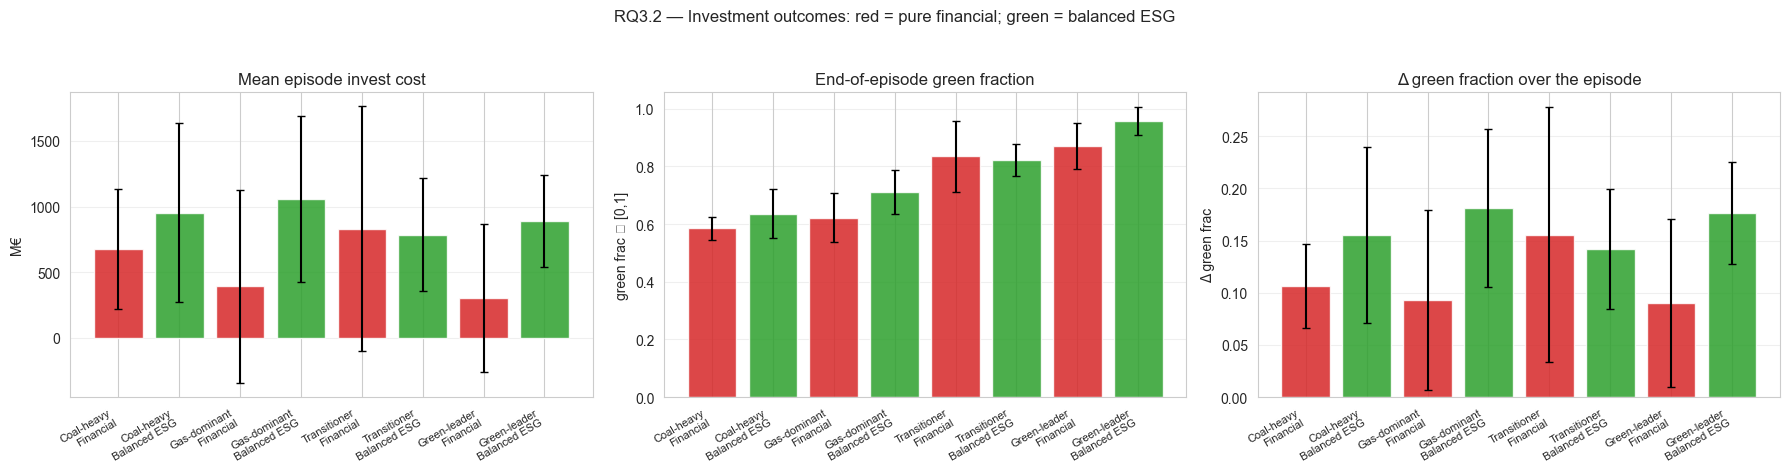

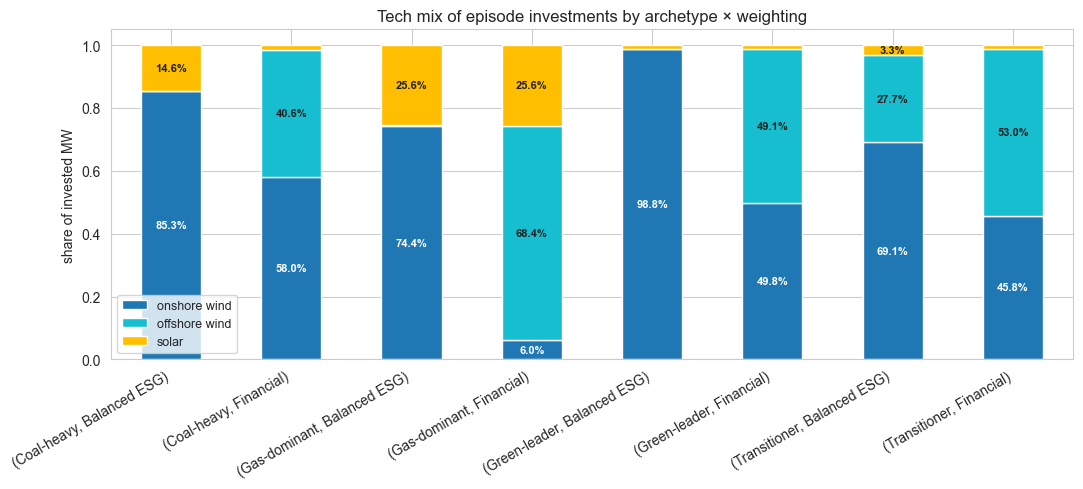

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
_bar(axes[0], 'invest_cost', 'Mean episode invest cost', 'M€')
_bar(axes[1], 'green_frac',  'End-of-episode green fraction', 'green frac ∈ [0,1]')
_bar(axes[2], 'delta_green', 'Δ green fraction over the episode', 'Δ green frac')
plt.suptitle('RQ3.2 — Investment outcomes: red = pure financial; green = balanced ESG',
             fontsize=12, y=1.04)
plt.tight_layout(); plt.show()

# Tech mix by archetype × weighting (stacked bar).
tech_cols = ['inv_onshore_share', 'inv_offshore_share', 'inv_solar_share']
tech_labels = ['onshore wind', 'offshore wind', 'solar']
tech_colors = ['#1f77b4', '#17becf', '#ffbf00']
tech_label_colors = ['white', '#1f1f1f', '#1f1f1f']
tech_means = (
    agent_df.groupby(['archetype', 'weighting'])[tech_cols]
    .mean()
    .rename(columns=dict(zip(tech_cols, tech_labels)))
)

fig, ax = plt.subplots(figsize=(11, 5))
tech_means.plot(kind='bar', stacked=True, ax=ax, color=tech_colors)

for x_pos, (_, row) in enumerate(tech_means.iterrows()):
    bottom = 0.0
    for label, text_color in zip(tech_labels, tech_label_colors):
        value = row[label]
        if pd.notna(value) and value >= 0.025:
            ax.text(
                x_pos,
                bottom + value / 2,
                f'{value * 100:.1f}%',
                ha='center',
                va='center',
                fontsize=8,
                fontweight='bold',
                color=text_color,
            )
        bottom += 0.0 if pd.isna(value) else value

ax.set(title='Tech mix of episode investments by archetype × weighting',
       ylabel='share of invested MW', xlabel='')
ax.set_ylim(0, 1.05)
ax.legend(tech_labels, fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()


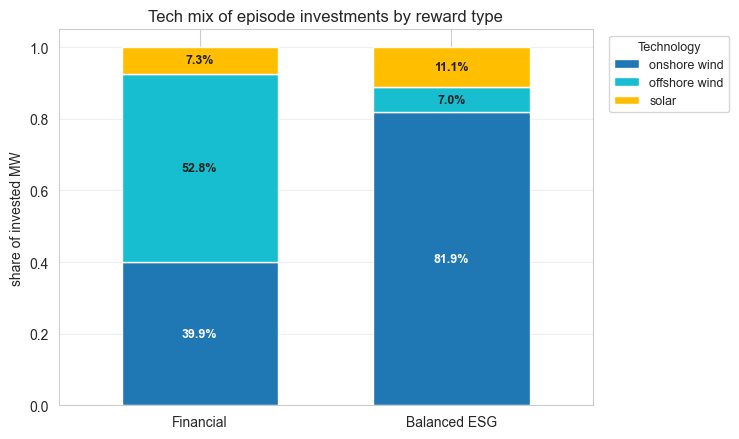

,onshore wind,offshore wind,solar,total
reward type,,,,
Financial,39.9%,52.8%,7.3%,100.0%
Balanced ESG,81.9%,7.0%,11.1%,100.0%


In [21]:
# Tech mix by reward type (stacked bar) with thesis-ready table.
tech_cols = ['inv_onshore_share', 'inv_offshore_share', 'inv_solar_share']
tech_labels = ['onshore wind', 'offshore wind', 'solar']
tech_colors = ['#1f77b4', '#17becf', '#ffbf00']
tech_label_colors = ['white', '#1f1f1f', '#1f1f1f']
reward_type_order = [w for w in ['Financial', 'Balanced ESG'] if w in agent_df['weighting'].dropna().unique()]

tech_mix_by_reward = (
    agent_df.groupby('weighting')[tech_cols]
    .mean()
    .reindex(reward_type_order)
    .rename(columns=dict(zip(tech_cols, tech_labels)))
)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
tech_mix_by_reward.plot(kind='bar', stacked=True, ax=ax, color=tech_colors, width=0.62)

for x_pos, (_, row) in enumerate(tech_mix_by_reward.iterrows()):
    bottom = 0.0
    for label, text_color in zip(tech_labels, tech_label_colors):
        value = row[label]
        if pd.notna(value) and value > 0:
            ax.text(
                x_pos,
                bottom + value / 2,
                f'{value * 100:.1f}%',
                ha='center',
                va='center',
                fontsize=9,
                fontweight='bold',
                color=text_color,
            )
        bottom += 0.0 if pd.isna(value) else value

ax.set(title='Tech mix of episode investments by reward type',
       ylabel='share of invested MW', xlabel='')
ax.set_xticklabels(tech_mix_by_reward.index, rotation=0)
ax.set_ylim(0, 1.05)
ax.legend(title='Technology', fontsize=9, title_fontsize=9, loc='upper left', bbox_to_anchor=(1.02, 1))
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

tech_mix_by_reward_table = (tech_mix_by_reward * 100).round(1)
tech_mix_by_reward_table['total'] = tech_mix_by_reward_table.sum(axis=1).round(1)
tech_mix_by_reward_table.index.name = 'reward type'

styled_tech_mix_by_reward_table = (
    tech_mix_by_reward_table
    .style
    .format('{:.1f}%')
    .set_caption('Tech mix by reward type (% of invested MW)')
)
display(styled_tech_mix_by_reward_table)

### RQ3.3 — Secondary-market role

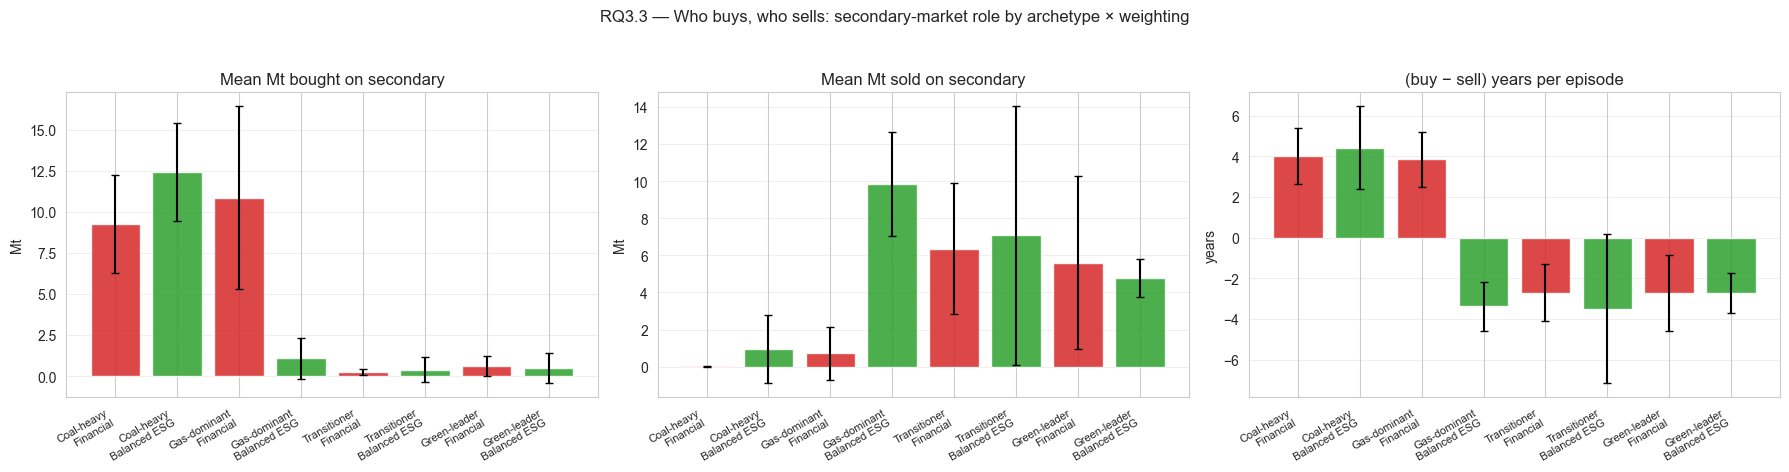

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
_bar(axes[0], 'sec_buy_vol',    'Mean Mt bought on secondary',  'Mt')
_bar(axes[1], 'sec_sell_vol',   'Mean Mt sold on secondary',    'Mt')
# Net buyer/seller years (out of 12).
def _net_buyer_years(row):
    by = row.get('sec_buy_years', np.nan); sy = row.get('sec_sell_years', np.nan)
    if pd.isna(by) or pd.isna(sy): return np.nan
    return by - sy
agent_df['net_buyer_years'] = agent_df.apply(_net_buyer_years, axis=1)
_bar(axes[2], 'net_buyer_years', '(buy − sell) years per episode', 'years')
plt.suptitle('RQ3.3 — Who buys, who sells: secondary-market role by archetype × weighting',
             fontsize=12, y=1.04)
plt.tight_layout(); plt.show()


### RQ3.4 — Compliance pathway (UDBC) by archetype × weighting

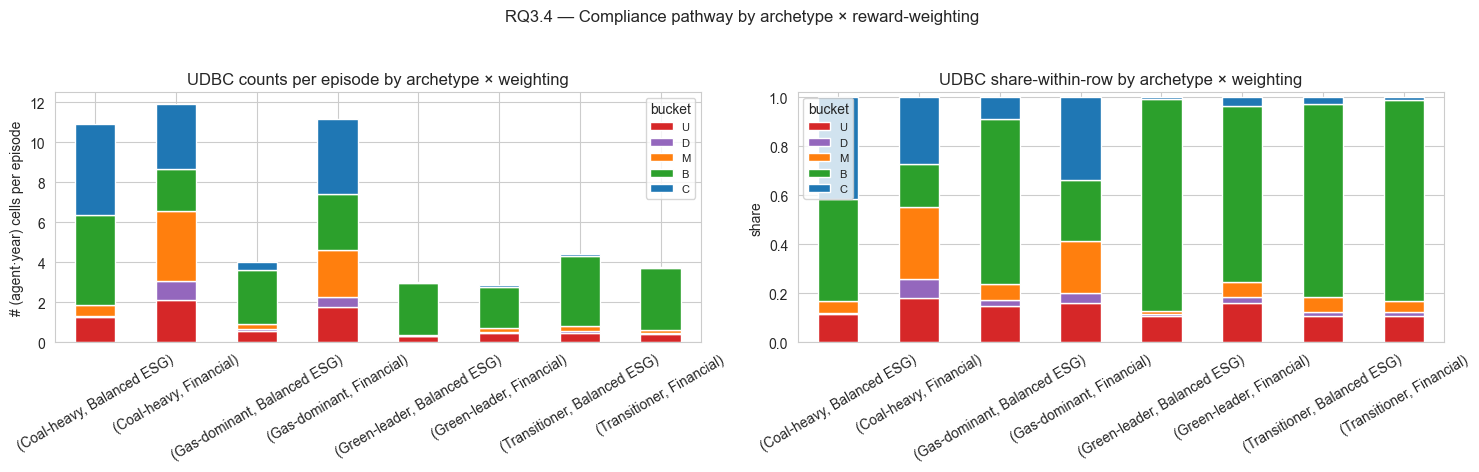

In [23]:
# Mean per-agent UDBC totals → grouped by archetype × weighting → stacked bar of shares.
udbc_buckets = ['U', 'D', 'M', 'B', 'C']
udbc_rows = []
for k, run in runs.items():
    ep = tail_episodes(run['ep_df'])
    for i in range(N_AGENTS):
        row = {'archetype': _agent_archetype(i), 'weighting': _agent_weighting(i)}
        for b in udbc_buckets:
            col = f'udbc_{b}_total_A{i+1}'
            row[b] = float(ep[col].mean()) if col in ep.columns else 0.0
        udbc_rows.append(row)
udbc_df = pd.DataFrame(udbc_rows)
udbc_grouped = udbc_df.groupby(['archetype', 'weighting'])[udbc_buckets].mean()
udbc_share = udbc_grouped.div(udbc_grouped.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
udbc_grouped.plot(kind='bar', stacked=True, ax=axes[0],
                  color=['#d62728', '#9467bd', '#ff7f0e', '#2ca02c', '#1f77b4'])
axes[0].set(title='UDBC counts per episode by archetype × weighting',
            ylabel='# (agent·year) cells per episode', xlabel='')
axes[0].legend(title='bucket', fontsize=8)
axes[0].tick_params(axis='x', rotation=30)

udbc_share.plot(kind='bar', stacked=True, ax=axes[1],
                color=['#d62728', '#9467bd', '#ff7f0e', '#2ca02c', '#1f77b4'])
axes[1].set(title='UDBC share-within-row by archetype × weighting',
            ylabel='share', xlabel='')
axes[1].set_ylim(0, 1.02)
axes[1].legend(title='bucket', fontsize=8)
axes[1].tick_params(axis='x', rotation=30)
plt.suptitle('RQ3.4 — Compliance pathway by archetype × reward-weighting',
             fontsize=12, y=1.04)
plt.tight_layout(); plt.show()


### RQ3.5 - A1-A8 reward balance and ESG-vs-financial twin contrast

RQ3.5 per-agent summary (n=32,000 (run, episode) cells across last 1,000 episodes):


bid_price          bid_multiplier         auction_coverage         allocation_mt         penalty_meur            shortfall_mt         invest_cost_meur  \
                                           mean      std           mean     std             mean     std          mean     std         mean        std         mean     std             mean   
agent_no agent objective archetype                                                                                                                                                             
1        A1    Financial Coal-heavy    132.8436  22.2746         0.5099  0.0212           0.5099  0.0212        1.7968  0.3495    1528.8671  1053.2911       9.6740  6.6293         677.4644   
2        A2    ESG       Coal-heavy    102.6173  36.8974         0.8523  0.5942           0.8523  0.5942        1.5736  0.3820     241.2570   346.2781       1.5384  2.2261         954.1666   
3        A3    Financial Gas-dominant   98.2105  34.4441         0.9042  0.6413           0.9042  0.6413        1.3831  0.4741     857.5456   842.9777       5.4935  5.3803         391.2965   
4        A4    ESG       Gas-dominant   62.5916  15.1633         1.7844  0.2399           1.7844  0.2399        2.7685  0.5621     182.5174   589.6228       1.0996  3.4682        1056.0523   
5        A5    Financial Transitioner  103.7860  41.1660         1.3789  0.1818           1.3789  0.1818        1.9034  0.5068      83.4461   322.6190       0.5042  1.9347         830.7273   
6        A6    ESG       Transitioner   70.1418  22.6131         1.7139  0.2937           1.7139  0.2937        1.8220  0.6533     182.2426   636.8528       1.1085  3.8295         786.5047   
7        A7    Financial Green-leader   90.4009  23.1067         1.6278  0.3771           1.6278  0.3771        1.5309  0.5255      45.7018   107.1933       0.2809  0.6550         300.6379   
8        A8    ESG       Green-leader   88.0410  21.5908         1.6113  0.2462           1.6113  0.2462        1.1302  0.2915      14.5308    49.4564       0.0882  0.3002         889.7073   

                                                green_fraction         delta_green         mac_reduction_mt         mac_cost_meur         sec_buy_mt         sec_sell_mt         sec_buy_years  \
                                            std           mean     std        mean     std             mean     std          mean     std       mean     std        mean     std          mean   
agent_no agent objective archetype                                                                                                                                                               
1        A1    Financial Coal-heavy    514.9239         0.5856  0.0728      0.1066  0.0637           0.0866  0.1118        4.8103  6.1629     9.2837  4.4813      0.0138  0.1120        4.0308   
2        A2    ESG       Coal-heavy    607.2973         0.6352  0.0863      0.1556  0.0825           0.0736  0.1120        4.0520  6.1236    12.4327  4.0387      0.9579  2.2142        4.8292   
3        A3    Financial Gas-dominant  641.0813         0.6220  0.0844      0.0930  0.0814           0.0477  0.0649        2.6642  3.5898    10.8502  6.0168      0.7263  2.1882        4.1535   
4        A4    ESG       Gas-dominant  557.6042         0.7104  0.0771      0.1816  0.0743           0.0066  0.0157        0.3470  0.8222     1.0765  2.0835      9.8415  4.3921        0.4018   
5        A5    Financial Transitioner  815.4764         0.8354  0.1128      0.1557  0.1107           0.0139  0.0339        0.7668  1.8667     0.2282  0.7818      6.3631  4.0580        0.1230   
6        A6    ESG       Transitioner  421.4787         0.8222  0.0683      0.1421  0.0632           0.0031  0.0120        0.1653  0.6498     0.3913  1.1148      7.0702  6.5449        0.1610   
7        A7    Financial Green-leader  502.0635         0.8698  0.0763      0.0901  0.0746           0.0029  0.0109        0.1621  0.6027     0.5866  1.2452      5.6078  4.4967   

RQ3.5 per-archetype summary (each row pools the Financial + Balanced ESG twin within that archetype):


bid_price          bid_multiplier         auction_coverage         allocation_mt         penalty_meur            shortfall_mt         invest_cost_meur           green_fraction          \
                  mean      std           mean     std             mean     std          mean     std         mean        std         mean     std             mean       std           mean     std   
archetype                                                                                                                                                                                              
Coal-heavy    117.7305  34.0163         0.6811  0.4539           0.6811  0.4539        1.6852  0.3828     885.0621  1014.4581       5.6062  6.4029         815.8155  579.7258         0.6104  0.0835   
Gas-dominant   80.4010  32.0201         1.3443  0.6543           1.3443  0.6543        2.0758  0.8661     520.0315   801.8710       3.2966  5.0312         723.6744  686.5840         0.6662  0.0921   
Transitioner   86.9639  37.2273         1.5464  0.2961           1.5464  0.2961        1.8627  0.5860     132.8444   507.1892       0.8064  3.0486         808.6160  649.4300         0.8288  0.0935   
Green-leader   89.2210  22.3913         1.6195  0.3185           1.6195  0.3185        1.3306  0.4697      30.1163    84.9131       0.1846  0.5185         595.1726  523.6228         0.9132  0.0782   

             delta_green         mac_reduction_mt         mac_cost_meur         sec_buy_mt         sec_sell_mt         sec_buy_years         sec_sell_years         invest_onshore_share          \
                    mean     std             mean     std          mean     std       mean     std        mean     std          mean     std           mean     std                 mean     std   
archetype                                                                                                                                                                                          
Coal-heavy        0.1311  0.0777           0.0801  0.1121        4.4311  6.1546    10.8582  4.5468      0.4859  1.6372        4.4300  1.8684         0.2191  0.6549               0.7165  0.3750   
Gas-dominant      0.1373  0.0896           0.0272  0.0515        1.5056  2.8501     5.9634  6.6448      5.2839  5.7282        2.2776  2.4361         2.0421  2.1768               0.4019  0.4681   
Transitioner      0.1489  0.0904           0.0085  0.0260        0.4661  1.4295     0.3098  0.9662      6.7167  5.4565        0.1420  0.4048         3.2544  2.7457               0.5743  0.4202   
Green-leader      0.1335  0.0770           0.0016  0.0079        0.0858  0.4362     0.5397  1.1667      5.1846  3.5571        0.2460  0.4884         2.9760  1.6686               0.7427  0.4257   

             invest_offshore_share         invest_solar_share         udbc_U_count         udbc_D_count         udbc_M_count         udbc_B_count         udbc_C_count         invest_frac_post_clip  \
                              mean     std               mean     std         mean     std         mean     std         mean     std         mean     std         mean     std                  mean   
archetype                                                                                                                                                                                              
Coal-heavy                  0.2037  0.3643             0.0798  0.1862       1.7120  1.1538       0.4795  1.0685       2.0211  2.3269       3.3196  2.1145       3.8848  1.9520                0.0185   
Gas-dominant                0.3424  0.4540             0.2557  0.4248       1.1836  1.1085       0.2938  0.7757       1.2930  1.9737       2.7535  1.5036       2.0485  2.3204                0.0171   
Transitioner                0.4032  0.4218             0.0225  0.0420       0.4486  0.6754       0.0595  0.2706       0.2238  0.7743       3.2871  2.2859       0.0794  0.3018                0.0204   
Green-leader                0.2457  0.4

RQ3.5 Financial vs ESG pooled summary (last row = ESG - Financial cross-agent delta):


bid_price          bid_multiplier         auction_coverage         allocation_mt         penalty_meur           shortfall_mt         invest_cost_meur           green_fraction  \
                     mean      std           mean     std             mean     std          mean     std         mean       std         mean     std             mean       std           mean   
objective                                                                                                                                                                                        
Financial        106.3103  35.1409         1.1052  0.5766           1.1052  0.5766        1.6536  0.5125     628.8902  926.7143       3.9882  5.8637         550.0315  666.2089         0.7282   
ESG               80.8479  29.7573         1.4905  0.5281           1.4905  0.5281        1.8236  0.7762     155.1369  475.4208       0.9587  2.8666         921.6077  504.5837         0.7811   
ESG - Financial  -25.4624  -5.3836         0.3853 -0.0485           0.3853 -0.0485        0.1700  0.2637    -473.7533 -451.2935      -3.0295 -2.9971         371.5762 -161.6252         0.0529   

                        delta_green         mac_reduction_mt         mac_cost_meur         sec_buy_mt         sec_sell_mt         sec_buy_years         sec_sell_years         invest_onshore_share  \
                    std        mean     std             mean     std          mean     std       mean     std        mean     std          mean     std           mean     std                 mean   
objective                                                                                                                                                                                             
Financial        0.1534      0.1114  0.0884           0.0378  0.0746        2.1008  4.1202     5.2372  6.1854      3.1778  4.2882        2.1446  2.4308         1.5434  1.9635               0.3990   
ESG              0.1410      0.1640  0.0705           0.0209  0.0645        1.1435  3.5331     3.5983  5.6436      5.6577  5.3418        1.4033  2.2099         2.7024  2.4571               0.8187   
ESG - Financial -0.0124      0.0526 -0.0179          -0.0169 -0.0101       -0.9573 -0.5871    -1.6389 -0.5418      2.4799  1.0536       -0.7413 -0.2209         1.1590  0.4936               0.4197   

                        invest_offshore_share         invest_solar_share         udbc_U_count         udbc_D_count         udbc_M_count         udbc_B_count         udbc_C_count          \
                    std                  mean     std               mean     std         mean     std         mean     std         mean     std         mean     std         mean     std   
objective                                                                                                                                                                                   
Financial        0.4521                0.5277  0.4613             0.0734  0.2389       1.1971  1.1848       0.3871  0.9389       1.5434  2.1986       2.5251  1.7276       1.7745  2.2592   
ESG              0.3209                0.0698  0.2085             0.1114  0.2650       0.6702  0.8763       0.0549  0.2648       0.2792  0.8101       3.3229  2.0755       1.2634  2.1159   
ESG - Financial -0.1312               -0.4579 -0.2528             0.0380  0.0261      -0.5269 -0.3085      -0.3322 -0.6741      -1.2642 -1.3885       0.7978  0.3479      -0.5111 -0.1433   

                invest_frac_post_clip         bank_end         trade_qty         noncompliant_share         stressed_share          reward         reward_base         reward_shaping       \
                                 mean     std     mean     std      mean     std               mean     std           mean     std    mean     std        mean     std           mean  std   
objective                                                                                                                                    

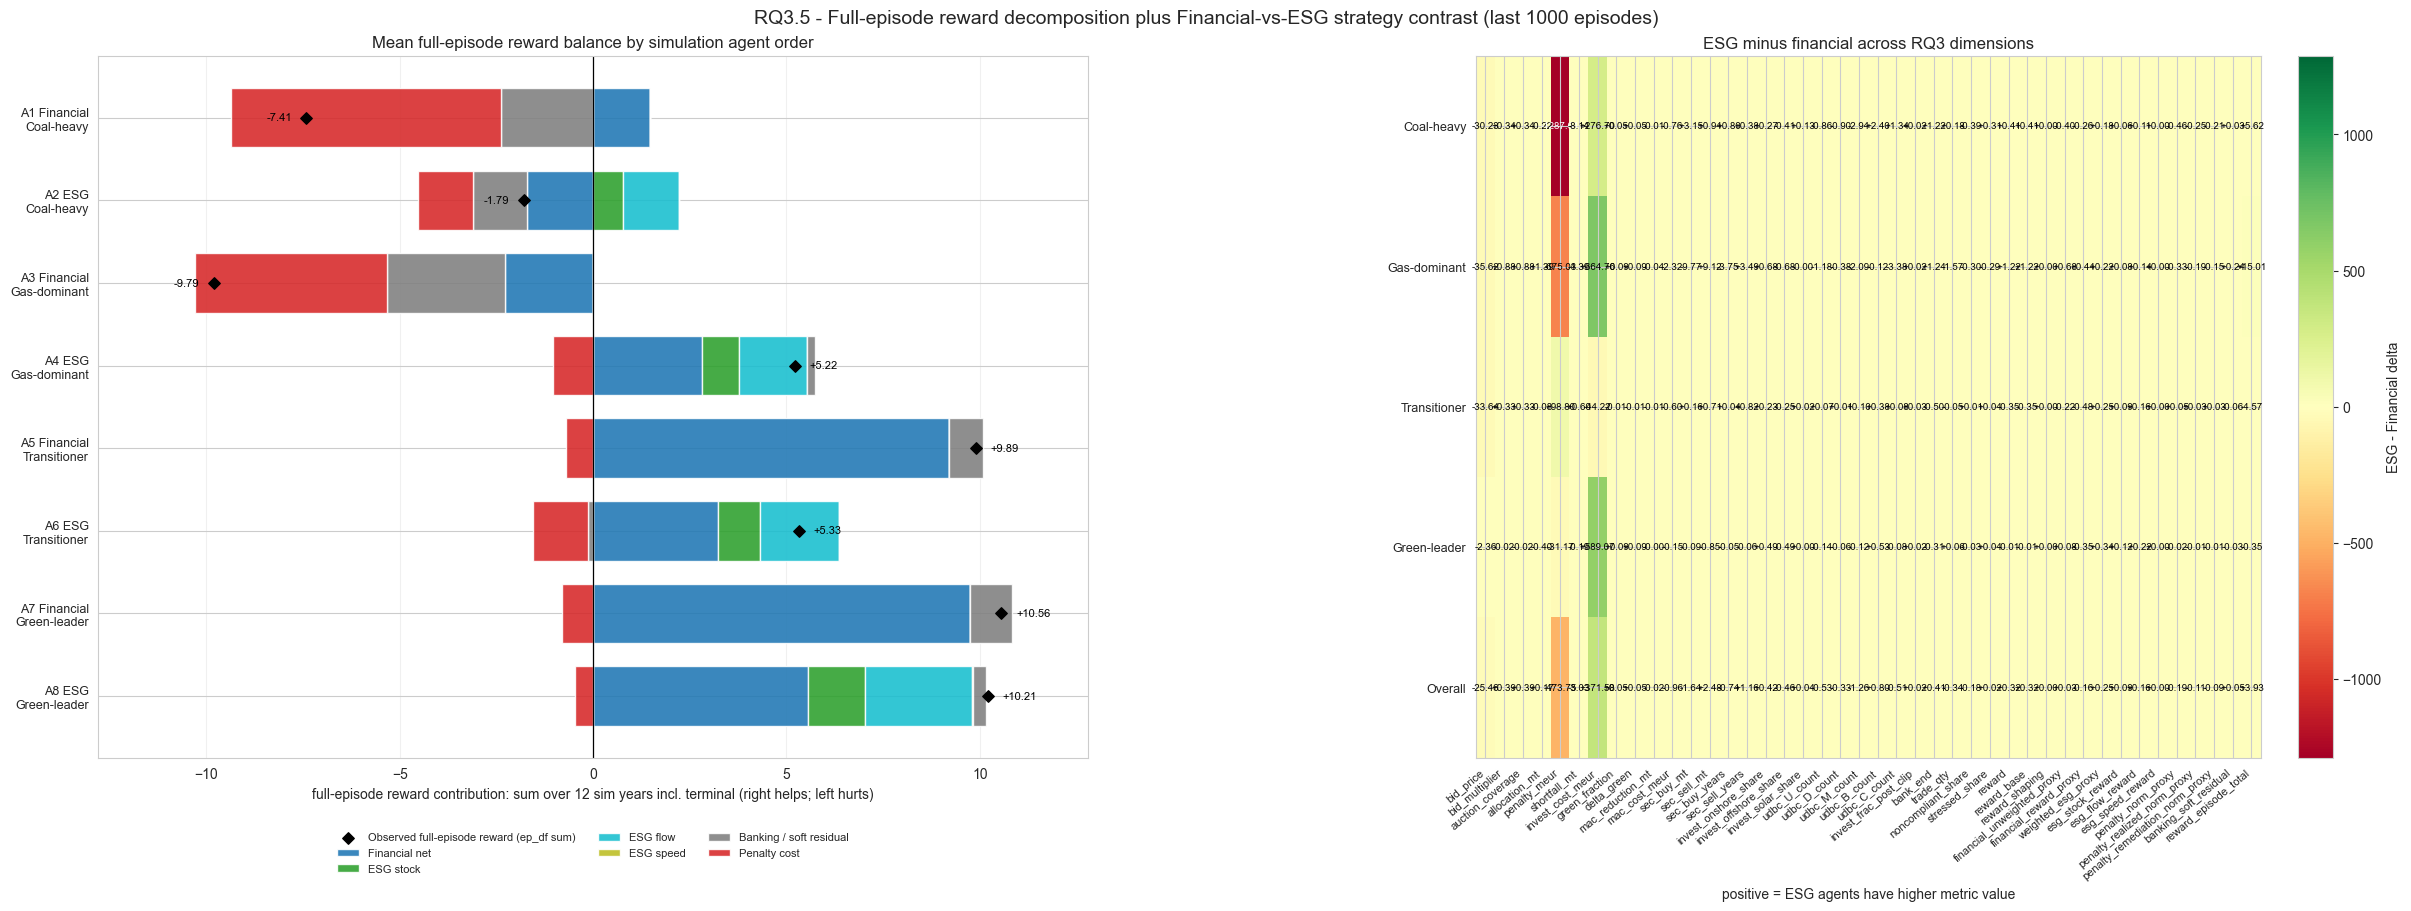

In [24]:
# RQ3.5 unified per-agent action + reward decomposition.
# Single source of truth: build per-(run, episode, agent_no) frame from ep_df
# (action / strategy metrics, per-episode values) and merge it with reward
# channels reconstructed from the year CSV. Two reward views are carried:
#   * REWARD_CHANNELS               -> mean across the 12 sim years
#   * <channel>_episode_sum         -> SUM across the 12 sim years (full episode,
#                                      includes the final/terminal year)
#   * reward_episode_total          -> authoritative full-episode reward taken
#                                      straight from ep_df.reward_A{i} (sum
#                                      over years, post-shaping, INCLUDES the
#                                      terminal-year payoff).
# The decomposition bar plot is driven by the *episode-sum* view so the
# terminal-year payoffs are visible. The individual per-year-mean overviews
# remain available in the summary tables alongside the new sum columns.

from matplotlib.colors import TwoSlopeNorm

# Mass tolerance for treating a shortfall / coverage gap as zero (Mt CO2).
# Defined here so this cell does not depend on the RQ4.5 cell having been run.
EPS_MT = globals().get('EPS_MT', 1e-6)

OBJECTIVE_ORDER = ['Financial', 'ESG']
WEIGHTING_TO_OBJECTIVE = {'Financial': 'Financial', 'Balanced ESG': 'ESG'}
UDBC_BUCKETS = ['U', 'D', 'M', 'B', 'C']

# Action / strategy metrics from ep_df (per-episode), with display labels.
# (mac_reduction, mac_cost) live in yr_df and are aggregated to per-episode means.
STRATEGY_PREFIX_LABELS = [
    ('bid_price', 'bid_price'),
    ('avg_bid_mult', 'bid_multiplier'),
    ('avg_bid_coverage', 'auction_coverage'),
    ('mean_alloc', 'allocation_mt'),
    ('penalty', 'penalty_meur'),
    ('shortfall', 'shortfall_mt'),
    ('invest_cost', 'invest_cost_meur'),
    ('green_frac', 'green_fraction'),
    ('delta_green', 'delta_green'),
    ('mac_reduction', 'mac_reduction_mt'),
    ('mac_cost', 'mac_cost_meur'),
    ('sec_buy_vol', 'sec_buy_mt'),
    ('sec_sell_vol', 'sec_sell_mt'),
    ('sec_buy_years', 'sec_buy_years'),
    ('sec_sell_years', 'sec_sell_years'),
    ('inv_onshore_share', 'invest_onshore_share'),
    ('inv_offshore_share', 'invest_offshore_share'),
    ('inv_solar_share', 'invest_solar_share'),
    ('udbc_U_total', 'udbc_U_count'),
    ('udbc_D_total', 'udbc_D_count'),
    ('udbc_M_total', 'udbc_M_count'),
    ('udbc_B_total', 'udbc_B_count'),
    ('udbc_C_total', 'udbc_C_count'),
    # Year-level only (no per-episode column in ep_df) -- per-episode value is
    # the mean across the 12 sim years of that episode.
    ('invest_frac_post_clip', 'invest_frac_post_clip'),
    ('bank_end', 'bank_end'),
    ('trade_qty', 'trade_qty'),
]
STRATEGY_LABELS = [label for _, label in STRATEGY_PREFIX_LABELS]
YEAR_LEVEL_PREFIXES = {'mac_reduction', 'mac_cost', 'invest_frac_post_clip', 'bank_end', 'trade_qty'}

# Derived per-year binary indicators -> per-episode share in [0, 1].
DERIVED_YEAR_SHARE_LABELS = ['noncompliant_share', 'stressed_share']
STRATEGY_LABELS = STRATEGY_LABELS + DERIVED_YEAR_SHARE_LABELS

# Reward channel labels in display order (sign convention preserved: positive
# values help reward, penalty_norm_proxy is reported as a positive cost).
REWARD_CHANNELS = [
    'reward', 'reward_base', 'reward_shaping',
    'financial_unweighted_proxy', 'financial_reward_proxy',
    'weighted_esg_proxy', 'esg_stock_reward', 'esg_flow_reward', 'esg_speed_reward',
    'penalty_norm_proxy', 'penalty_realized_norm_proxy', 'penalty_remediation_norm_proxy',
    'banking_soft_residual',
]
REWARD_CHANNEL_SUM_LABELS = [f'{c}_episode_sum' for c in REWARD_CHANNELS]


def _numeric_column(frame, column, default=0.0):
    if column in frame.columns:
        return pd.to_numeric(frame[column], errors='coerce').astype(float)
    return pd.Series(default, index=frame.index, dtype=float)


def _agent_output_twh(agent_idx):
    output_cfg = REFERENCE_CONFIG.get('companies', {}).get('output_twh', 10.0)
    if isinstance(output_cfg, (list, tuple)):
        return float(output_cfg[agent_idx]) if agent_idx < len(output_cfg) else float(output_cfg[-1])
    return float(output_cfg)


def _agent_reward_weights(agent_idx):
    weights = REFERENCE_CONFIG.get('companies', {}).get('reward_weights', []) or []
    if agent_idx < len(weights):
        return float(weights[agent_idx][0]), float(weights[agent_idx][1])
    return (1.0, 0.0) if agent_idx % 2 == 0 else (0.5, 0.5)


def _agent_objective_label(agent_no):
    return 'ESG' if agent_no % 2 == 0 else 'Financial'


def _initial_emission_factors():
    tech_efs = np.asarray(REFERENCE_CONFIG.get('technologies', {}).get('emission_factors', []), dtype=float)
    initial_mix = REFERENCE_CONFIG.get('companies', {}).get('initial_mix', []) or []
    factors = []
    for agent_idx in range(N_AGENTS):
        if agent_idx < len(initial_mix) and len(tech_efs) > 0:
            factors.append(float(np.dot(np.asarray(initial_mix[agent_idx], dtype=float), tech_efs)))
        else:
            factors.append(np.nan)
    return factors


def _reward_context():
    esg_cfg = REFERENCE_CONFIG.get('esg', {}) or {}
    reward_cfg = REFERENCE_CONFIG.get('reward', {}) or {}
    banking_cfg = reward_cfg.get('banking_signal', {}) or {}
    return {
        'initial_efs': _initial_emission_factors(),
        'reward_weights': [_agent_reward_weights(agent_idx) for agent_idx in range(N_AGENTS)],
        'base_penalty_rate': float(REFERENCE_CONFIG.get('penalty', {}).get('rate', 100.0)),
        'annual_budgets': REFERENCE_CONFIG.get('budget', {}).get('annual_budgets', []) or [1000.0] * N_AGENTS,
        'esg_scale': float(esg_cfg.get('scale', 0.5)),
        'esg_stock_weight': float(esg_cfg.get('stock_weight', 1.0)),
        'esg_flow_weight': float(esg_cfg.get('flow_weight', 1.5)),
        'esg_speed_early': float(esg_cfg.get('speed_coef', 0.3)),
        'esg_speed_late': float(esg_cfg.get('speed_coef_late', esg_cfg.get('speed_coef', 0.3))),
        'gate_threshold': float(reward_cfg.get('compliance_gate_blend_threshold', 0.90)),
        'gate_width': max(float(reward_cfg.get('compliance_gate_blend_width', 0.30)), 1e-9),
        'imputed_bank_weight': float(banking_cfg.get('w_imputed', 1.0)),
        'imputed_cap_factor': float(banking_cfg.get('imputed_cap_factor', 5.0)),
    }


def _prepare_core_year_frame(run_data, include_final_year=False):
    """Slice the year frame and build the `common` context.

    By default the final/terminal year is dropped to keep the per-year-mean
    decomposition stable; pass include_final_year=True to compute the
    full-episode SUM view (which must include the terminal year so the
    end-of-episode payoffs land in the bars).
    """
    year_frame = tail_year_rows(run_data).copy()
    if year_frame.empty or 'year' not in year_frame.columns:
        return None, None

    year_frame = year_frame.sort_values(['episode', 'year']).copy()
    if {'episode', 'fundamental_anchor'}.issubset(year_frame.columns):
        year_frame['_anchor_next'] = year_frame.groupby('episode')['fundamental_anchor'].shift(-1)
    else:
        year_frame['_anchor_next'] = np.nan
    year_frame['_anchor_next'] = year_frame['_anchor_next'].fillna(year_frame.get('fundamental_anchor', np.nan))

    initial_year_label = YEAR_DISPLAY_START if 'YEAR_DISPLAY_START' in globals() else 1
    final_year_label = YEAR_DISPLAY_END if 'YEAR_DISPLAY_END' in globals() else N_YEARS
    if include_final_year:
        core_year_frame = year_frame.copy()
    else:
        core_year_frame = year_frame[year_frame['year'] < final_year_label].copy()
        if core_year_frame.empty:
            core_year_frame = year_frame.copy()

    initial_year_rows = year_frame[year_frame['year'] == initial_year_label]
    anchor0_real = np.nan
    if {'fundamental_anchor', 'inflation_factor'}.issubset(initial_year_rows.columns) and not initial_year_rows.empty:
        anchor0_real = float((initial_year_rows['fundamental_anchor'] / initial_year_rows['inflation_factor'].replace(0, np.nan)).median())
    if not np.isfinite(anchor0_real) or anchor0_real <= 0:
        anchor0_real = 1.0

    cap0 = float(initial_year_rows['cap'].median()) if 'cap' in initial_year_rows.columns and not initial_year_rows.empty else np.nan
    if not np.isfinite(cap0) or cap0 <= 0:
        cap0 = float(core_year_frame['cap'].max()) if 'cap' in core_year_frame.columns else 1.0

    common = {
        'initial_year_label': initial_year_label,
        'anchor0_real': anchor0_real,
        'cap0': cap0,
        'inflation': _numeric_column(core_year_frame, 'inflation_factor', 1.0).replace(0, np.nan).fillna(1.0),
        'anchor': _numeric_column(core_year_frame, 'fundamental_anchor', np.nan).replace(0, np.nan),
        'anchor_next': _numeric_column(core_year_frame, '_anchor_next', np.nan).replace(0, np.nan),
        'clearing_price': _numeric_column(core_year_frame, 'clearing_price', 0.0),
        'cap': _numeric_column(core_year_frame, 'cap', cap0),
    }
    common['anchor_next'] = common['anchor_next'].fillna(common['anchor'])
    return core_year_frame, common


def _agent_reward_channel_frame(core_year_frame, common, context, run_key, agent_idx):
    agent_no = agent_idx + 1
    reward_col = f'reward_A{agent_no}'
    base_col = f'reward_base_A{agent_no}'
    need_col = f'estimate_need_A{agent_no}'
    if base_col not in core_year_frame.columns or need_col not in core_year_frame.columns:
        return None

    inflation = common['inflation']
    anchor = common['anchor']
    anchor_next = common['anchor_next']
    cap = common['cap']
    cap0 = common['cap0']
    scarcity_amp = 1.0 + np.maximum(0.0, 1.0 - cap / max(cap0, 1e-9))
    year_offset = (_numeric_column(core_year_frame, 'year', common['initial_year_label']) - common['initial_year_label']).clip(lower=0.0)
    year_frac = year_offset / max(N_YEARS - 1, 1)
    speed_coef = context['esg_speed_early'] + year_frac * (context['esg_speed_late'] - context['esg_speed_early'])

    weight_cost, weight_green = context['reward_weights'][agent_idx]
    annual_budgets = context['annual_budgets']
    annual_budget = float(annual_budgets[agent_idx]) if agent_idx < len(annual_budgets) else float(annual_budgets[-1])
    budget_real = annual_budget / inflation
    soft_denom = np.maximum(budget_real, 1.0)

    need = _numeric_column(core_year_frame, need_col, np.nan).clip(lower=1e-6)
    compliance_denom = np.maximum((anchor / inflation) * need, 1.0)
    nominal_compliance_denom = np.maximum(inflation * compliance_denom, 1.0)

    auction_cost = _numeric_column(core_year_frame, f'auction_cost_A{agent_no}', 0.0)
    trade_cost = _numeric_column(core_year_frame, f'trade_cost_A{agent_no}', 0.0)
    mac_cost = _numeric_column(core_year_frame, f'mac_cost_A{agent_no}', 0.0)
    investment_cost = _numeric_column(core_year_frame, f'invest_cost_A{agent_no}', 0.0)
    compliance_norm_cash = ((auction_cost + trade_cost + mac_cost) / inflation) / compliance_denom

    bank_start = _numeric_column(core_year_frame, f'bank_start_A{agent_no}', 0.0).clip(lower=0.0)
    allocation = _numeric_column(core_year_frame, f'alloc_A{agent_no}', 0.0).clip(lower=0.0)
    trade_qty = _numeric_column(core_year_frame, f'trade_qty_A{agent_no}', 0.0)
    emissions = _numeric_column(core_year_frame, f'emissions_A{agent_no}', 0.0).clip(lower=0.0)
    carry_forward_start = _numeric_column(core_year_frame, f'carry_forward_start_A{agent_no}', 0.0).clip(lower=0.0)
    carry_forward_end = _numeric_column(core_year_frame, f'carry_forward_end_A{agent_no}', 0.0).clip(lower=0.0)

    total_new_allowances = allocation + trade_qty.clip(lower=0.0)
    total_obligation = emissions + carry_forward_start
    bank_drawdown = np.minimum(bank_start, (total_obligation - total_new_allowances).clip(lower=0.0)).clip(lower=0.0)
    imputed_bank_real = bank_drawdown * common['clearing_price'] / inflation
    imputed_bank_norm = np.minimum(imputed_bank_real, context['imputed_cap_factor'] * compliance_denom) / compliance_denom

    compliance_norm = compliance_norm_cash + context['imputed_bank_weight'] * imputed_bank_norm
    capital_norm = (investment_cost / inflation) / soft_denom
    cost_norm_centered = compliance_norm + capital_norm - 1.0

    bid_coverage = _numeric_column(core_year_frame, f'bid_coverage_A{agent_no}', np.nan)
    coverage_auction = bid_coverage.fillna(allocation / need).clip(lower=0.0, upper=1.0)
    financial_unweighted_basis = -cost_norm_centered
    financial_unweighted_proxy = financial_unweighted_basis.where(
        cost_norm_centered >= 0.0,
        coverage_auction * financial_unweighted_basis,
    )
    savings_reward = weight_cost * financial_unweighted_basis
    financial_reward = savings_reward.where(cost_norm_centered >= 0.0, coverage_auction * savings_reward)

    shortfall = _numeric_column(core_year_frame, f'shortfall_A{agent_no}', np.nan)
    if shortfall.isna().all():
        effective_penalty_rate = _numeric_column(core_year_frame, f'effective_penalty_rate_A{agent_no}', np.nan).replace(0, np.nan)
        shortfall = _numeric_column(core_year_frame, f'penalty_A{agent_no}', 0.0) / effective_penalty_rate
    shortfall = shortfall.fillna(0.0).clip(lower=0.0)
    penalty_realized_norm = shortfall * context['base_penalty_rate'] / nominal_compliance_denom
    penalty_remediation_norm = carry_forward_end * anchor_next * scarcity_amp / nominal_compliance_denom
    penalty_norm = penalty_realized_norm + penalty_remediation_norm

    output_twh = max(_agent_output_twh(agent_idx), 1e-9)
    current_ef = emissions / output_twh
    initial_ef = context['initial_efs'][agent_idx]
    if np.isfinite(initial_ef) and initial_ef > 1e-9:
        ef_ratio = ((initial_ef - current_ef) / initial_ef).clip(lower=0.0)
    else:
        ef_ratio = pd.Series(0.0, index=core_year_frame.index)
    anchor_ratio = ((anchor / inflation) / max(common['anchor0_real'], 1.0)).clip(lower=0.0)
    green_delta = _numeric_column(core_year_frame, f'delta_green_A{agent_no}', 0.0).clip(lower=0.0)
    pre_compliance_holdings = (bank_start + allocation + trade_qty).clip(lower=0.0)
    coverage_pre_compliance = (pre_compliance_holdings / need).clip(lower=0.0, upper=1.0)
    gate_blend = ((context['gate_threshold'] - coverage_pre_compliance) / context['gate_width']).clip(lower=0.0, upper=1.0)
    compliance_gate = coverage_pre_compliance ** (1.0 + gate_blend)

    esg_stock_reward = weight_green * context['esg_scale'] * context['esg_stock_weight'] * ef_ratio * compliance_gate
    esg_flow_reward = weight_green * context['esg_scale'] * context['esg_flow_weight'] * ef_ratio * anchor_ratio * compliance_gate
    esg_speed_reward = weight_green * context['esg_scale'] * speed_coef * green_delta * compliance_gate
    weighted_esg_reward = esg_stock_reward + esg_flow_reward + esg_speed_reward

    reward_base = _numeric_column(core_year_frame, base_col, np.nan)
    reward = _numeric_column(core_year_frame, reward_col, np.nan)
    reward_shaping = _numeric_column(core_year_frame, f'reward_shaping_A{agent_no}', 0.0)
    residual = reward_base - financial_reward - weighted_esg_reward + penalty_norm
    objective = _agent_objective_label(agent_no)
    archetype = _agent_archetype(agent_idx)

    return pd.DataFrame({
        'sweep': run_key[0],
        'variant': run_key[1],
        'seed': run_key[2],
        'episode': _numeric_column(core_year_frame, 'episode', np.nan),
        'year': _numeric_column(core_year_frame, 'year', np.nan),
        'agent_no': agent_no,
        'agent': f'A{agent_no}',
        'agent_label': f'A{agent_no} {objective}\n{archetype}',
        'archetype': archetype,
        'objective': objective,
        'weighting': _agent_weighting(agent_idx),
        'reward': reward,
        'reward_base': reward_base,
        'reward_shaping': reward_shaping,
        'financial_unweighted_proxy': financial_unweighted_proxy,
        'financial_reward_proxy': financial_reward,
        'weighted_esg_proxy': weighted_esg_reward,
        'esg_stock_reward': esg_stock_reward,
        'esg_flow_reward': esg_flow_reward,
        'esg_speed_reward': esg_speed_reward,
        'penalty_norm_proxy': penalty_norm,
        'penalty_realized_norm_proxy': penalty_realized_norm,
        'penalty_remediation_norm_proxy': penalty_remediation_norm,
        'banking_soft_residual': residual,
    })


def _build_reward_decomp_year(include_final_year=False):
    context = _reward_context()
    frames = []
    for run_key, run_data in runs.items():
        core_year_frame, common = _prepare_core_year_frame(
            run_data, include_final_year=include_final_year
        )
        if core_year_frame is None:
            continue
        for agent_idx in range(N_AGENTS):
            agent_frame = _agent_reward_channel_frame(core_year_frame, common, context, run_key, agent_idx)
            if agent_frame is not None:
                frames.append(agent_frame)
    if not frames:
        return pd.DataFrame()
    decomp = pd.concat(frames, ignore_index=True)
    numeric_cols = decomp.select_dtypes(include=[np.number]).columns
    decomp[numeric_cols] = decomp[numeric_cols].replace([np.inf, -np.inf], np.nan)
    return decomp.dropna(subset=['reward_base', 'financial_reward_proxy', 'penalty_norm_proxy'])


def _build_strategy_episode_frame():
    """Per-(run, episode, agent_no) frame of strategy/action metrics from ep_df."""
    rows = []
    for run_key, run_data in runs.items():
        ep = tail_episodes(run_data['ep_df']).copy()
        if ep.empty:
            continue
        if 'episode' in ep.columns:
            episodes = pd.to_numeric(ep['episode'], errors='coerce').astype(float).values
        else:
            episodes = np.arange(len(ep), dtype=float)

        yr = tail_year_rows(run_data)
        yr_ep_means = {}
        yr_share_means = {}
        if yr is not None and not yr.empty and 'episode' in yr.columns:
            yr_ep = pd.to_numeric(yr['episode'], errors='coerce')
            for prefix in YEAR_LEVEL_PREFIXES:
                for agent_idx in range(N_AGENTS):
                    col = f'{prefix}_A{agent_idx + 1}'
                    if col in yr.columns:
                        yr_ep_means[(agent_idx + 1, prefix)] = (
                            pd.to_numeric(yr[col], errors='coerce')
                            .groupby(yr_ep).mean()
                        )
            for agent_idx in range(N_AGENTS):
                agent_no = agent_idx + 1
                sf_col = f'shortfall_A{agent_no}'
                em_col = f'emissions_A{agent_no}'
                al_col = f'alloc_A{agent_no}'
                cf_col = f'carry_forward_start_A{agent_no}'
                if sf_col not in yr.columns:
                    continue
                sf = pd.to_numeric(yr[sf_col], errors='coerce').fillna(0.0)
                noncomp_flag = (sf > EPS_MT).astype(float)
                yr_share_means[(agent_no, 'noncompliant_share')] = (
                    noncomp_flag.groupby(yr_ep).mean()
                )
                if all(c in yr.columns for c in (em_col, al_col, cf_col)):
                    emiss = pd.to_numeric(yr[em_col], errors='coerce').fillna(0.0).clip(lower=0.0)
                    alloc = pd.to_numeric(yr[al_col], errors='coerce').fillna(0.0)
                    cf_start = pd.to_numeric(yr[cf_col], errors='coerce').fillna(0.0).clip(lower=0.0)
                    auction_gap = (emiss + cf_start - alloc).clip(lower=0.0)
                    stressed_flag = ((auction_gap > EPS_MT) & (sf <= EPS_MT)).astype(float)
                    yr_share_means[(agent_no, 'stressed_share')] = (
                        stressed_flag.groupby(yr_ep).mean()
                    )

        for agent_idx in range(N_AGENTS):
            agent_no = agent_idx + 1
            frame = pd.DataFrame({
                'sweep': run_key[0],
                'variant': run_key[1],
                'seed': run_key[2],
                'episode': episodes,
                'agent_no': agent_no,
                'agent': f'A{agent_no}',
                'archetype': _agent_archetype(agent_idx),
                'weighting': _agent_weighting(agent_idx),
                'objective': _agent_objective_label(agent_no),
            })
            for prefix, label in STRATEGY_PREFIX_LABELS:
                if prefix in YEAR_LEVEL_PREFIXES:
                    series = yr_ep_means.get((agent_no, prefix))
                    if series is not None:
                        frame[label] = pd.Series(episodes).map(series).astype(float).values
                    else:
                        frame[label] = np.nan
                else:
                    col = f'{prefix}_A{agent_no}'
                    if col in ep.columns:
                        frame[label] = pd.to_numeric(ep[col], errors='coerce').astype(float).values
                    else:
                        frame[label] = np.nan
            for share_label in DERIVED_YEAR_SHARE_LABELS:
                series = yr_share_means.get((agent_no, share_label))
                if series is not None:
                    frame[share_label] = pd.Series(episodes).map(series).astype(float).values
                else:
                    frame[share_label] = np.nan
            rows.append(frame)
    if not rows:
        return pd.DataFrame()
    out = pd.concat(rows, ignore_index=True)
    numeric_cols = out.select_dtypes(include=[np.number]).columns
    out[numeric_cols] = out[numeric_cols].replace([np.inf, -np.inf], np.nan)
    return out


def _build_unified_agent_episode_frame(reward_decomp_year, reward_decomp_year_full):
    """Per-(run, episode, agent) frame:
        * strategy/action metrics (per-episode)
        * REWARD_CHANNELS  -> mean across the 12 sim years (final year excluded)
        * <channel>_episode_sum  -> sum across all 12 sim years (terminal incl.)
        * reward_episode_total   -> authoritative full-episode reward from
                                    ep_df.reward_A{i} (post-shaping, includes
                                    the terminal-year payoff).
    """
    strategy_df = _build_strategy_episode_frame()
    ep_keys = ['sweep', 'variant', 'seed', 'episode', 'agent_no']

    if not reward_decomp_year.empty:
        reward_ep_mean = (
            reward_decomp_year.groupby(ep_keys, as_index=False)[REWARD_CHANNELS].mean()
        )
    else:
        reward_ep_mean = pd.DataFrame(columns=ep_keys)

    if not reward_decomp_year_full.empty:
        reward_ep_sum = (
            reward_decomp_year_full.groupby(ep_keys, as_index=False)[REWARD_CHANNELS].sum()
            .rename(columns={c: f'{c}_episode_sum' for c in REWARD_CHANNELS})
        )
    else:
        reward_ep_sum = pd.DataFrame(columns=ep_keys)

    ep_total_rows = []
    for run_key, run_data in runs.items():
        ep = tail_episodes(run_data['ep_df']).copy()
        if ep.empty:
            continue
        if 'episode' in ep.columns:
            episodes = pd.to_numeric(ep['episode'], errors='coerce').astype(float).values
        else:
            episodes = np.arange(len(ep), dtype=float)
        for agent_idx in range(N_AGENTS):
            agent_no = agent_idx + 1
            col = f'reward_A{agent_no}'
            if col not in ep.columns:
                continue
            ep_total_rows.append(pd.DataFrame({
                'sweep': run_key[0], 'variant': run_key[1], 'seed': run_key[2],
                'episode': episodes, 'agent_no': agent_no,
                'reward_episode_total': pd.to_numeric(ep[col], errors='coerce').astype(float).values,
            }))
    ep_total_df = (
        pd.concat(ep_total_rows, ignore_index=True)
        if ep_total_rows else pd.DataFrame(columns=ep_keys + ['reward_episode_total'])
    )

    frames = [df for df in (strategy_df, reward_ep_mean, reward_ep_sum, ep_total_df) if not df.empty]
    if not frames:
        return pd.DataFrame()
    out = frames[0]
    for f in frames[1:]:
        out = pd.merge(out, f, on=ep_keys, how='outer')
    numeric_cols = out.select_dtypes(include=[np.number]).columns
    out[numeric_cols] = out[numeric_cols].replace([np.inf, -np.inf], np.nan)
    return out


def _agent_summary(unified_df, group_cols, sort_index=None):
    """Mean & std for all available metrics.

    Carries the per-year channel means (existing individual reward overviews),
    the per-episode channel sums, and the authoritative full-episode reward.
    """
    metric_cols = (
        STRATEGY_LABELS
        + REWARD_CHANNELS
        + REWARD_CHANNEL_SUM_LABELS
        + ['reward_episode_total']
    )
    available = [col for col in metric_cols if col in unified_df.columns]
    if unified_df.empty or not available:
        return pd.DataFrame()
    summary = (
        unified_df.groupby(group_cols, sort=False, dropna=False)[available]
        .agg(['mean', 'std'])
        .round(4)
    )
    if sort_index is not None:
        summary = summary.reindex([key for key in sort_index if key in summary.index])
    return summary


def _add_esg_minus_financial(objective_summary):
    if objective_summary.empty:
        return objective_summary
    if not {'Financial', 'ESG'}.issubset(objective_summary.index):
        return objective_summary
    delta = objective_summary.loc['ESG'] - objective_summary.loc['Financial']
    out = objective_summary.copy()
    out.loc['ESG - Financial'] = delta
    return out.reindex(['Financial', 'ESG', 'ESG - Financial'])


def _agent_reward_means_for_plot(unified_df):
    """Mean across episodes of the full-episode reward channels (per agent).

    Uses *_episode_sum columns so the stacked bars include the terminal-year
    payoff; reward_episode_total is the observed-reference diamond.
    """
    channel_cols = [
        'reward_episode_total',
        'reward_base_episode_sum',
        'financial_reward_proxy_episode_sum',
        'weighted_esg_proxy_episode_sum',
        'esg_stock_reward_episode_sum',
        'esg_flow_reward_episode_sum',
        'esg_speed_reward_episode_sum',
        'penalty_norm_proxy_episode_sum',
        'penalty_realized_norm_proxy_episode_sum',
        'penalty_remediation_norm_proxy_episode_sum',
        'banking_soft_residual_episode_sum',
        'reward_shaping_episode_sum',
    ]
    available = [c for c in channel_cols if c in unified_df.columns]
    df = unified_df.copy()
    df['agent_label'] = df.apply(
        lambda r: f"A{int(r['agent_no'])} {r['objective']}\n{r['archetype']}", axis=1,
    )
    return (
        df.groupby(['agent_no', 'agent', 'objective', 'archetype', 'agent_label'], sort=True)[available]
        .mean()
        .reset_index()
        .sort_values('agent_no')
    )


def _plot_reward_decomposition(agent_means, contrast_display):
    fig, (axis_components, axis_contrast) = plt.subplots(
        1, 2, figsize=(24, 9), constrained_layout=True,
        gridspec_kw={'width_ratios': [1.45, 1.15], 'wspace': 0.25},
    )

    y_positions = np.arange(len(agent_means))
    positive_left = np.zeros(len(agent_means))
    negative_left = np.zeros(len(agent_means))
    component_specs = [
        ('financial_reward_proxy_episode_sum', 'Financial net', '#1f77b4', 1.0),
        ('esg_stock_reward_episode_sum', 'ESG stock', '#2ca02c', 1.0),
        ('esg_flow_reward_episode_sum', 'ESG flow', '#17becf', 1.0),
        ('esg_speed_reward_episode_sum', 'ESG speed', '#bcbd22', 1.0),
        ('banking_soft_residual_episode_sum', 'Banking / soft residual', '#7f7f7f', 1.0),
        ('penalty_norm_proxy_episode_sum', 'Penalty cost', '#d62728', -1.0),
    ]

    legend_labels_seen = set()
    for column, label, color, sign in component_specs:
        if column not in agent_means.columns:
            continue
        values = (agent_means[column] * sign).to_numpy(dtype=float)
        positive_values = np.clip(values, 0.0, None)
        negative_values = np.clip(values, None, 0.0)
        legend_label = label if label not in legend_labels_seen else '_nolegend_'
        if np.any(np.isfinite(positive_values) & (positive_values != 0.0)):
            axis_components.barh(y_positions, positive_values, left=positive_left, label=legend_label, color=color, alpha=0.88, height=0.72)
            legend_labels_seen.add(label)
            legend_label = '_nolegend_'
            positive_left += np.nan_to_num(positive_values, nan=0.0)
        if np.any(np.isfinite(negative_values) & (negative_values != 0.0)):
            axis_components.barh(y_positions, negative_values, left=negative_left, label=legend_label, color=color, alpha=0.88, height=0.72)
            legend_labels_seen.add(label)
            negative_left += np.nan_to_num(negative_values, nan=0.0)

    reward_total_mean = (
        agent_means['reward_episode_total'].to_numpy(dtype=float)
        if 'reward_episode_total' in agent_means.columns
        else np.full(len(agent_means), np.nan)
    )
    axis_components.scatter(
        reward_total_mean, y_positions, marker='D', color='black', s=34,
        label='Observed full-episode reward (ep_df sum)', zorder=5,
    )

    stacked_extent = np.nanmax(np.abs(np.r_[positive_left, negative_left, reward_total_mean]))
    if not np.isfinite(stacked_extent) or stacked_extent == 0:
        stacked_extent = 1.0
    label_offset = stacked_extent * 0.035
    for y_pos, value in zip(y_positions, reward_total_mean):
        if np.isfinite(value):
            ha = 'left' if value >= 0 else 'right'
            offset = label_offset if value >= 0 else -label_offset
            axis_components.text(value + offset, y_pos, f'{value:+.2f}', va='center', ha=ha, fontsize=8, color='black')

    axis_components.set_xlim(-stacked_extent * 1.18, stacked_extent * 1.18)
    axis_components.axvline(0, color='black', lw=0.9)
    axis_components.set_yticks(y_positions)
    axis_components.set_yticklabels(agent_means['agent_label'].tolist(), fontsize=9)
    axis_components.invert_yaxis()
    axis_components.set_xlabel('full-episode reward contribution: sum over 12 sim years incl. terminal (right helps; left hurts)')
    axis_components.set_title('Mean full-episode reward balance by simulation agent order')
    axis_components.grid(True, alpha=0.28, axis='x')
    handles, labels = axis_components.get_legend_handles_labels()
    legend_items = [(handle, label) for handle, label in zip(handles, labels) if label != '_nolegend_']
    axis_components.legend([handle for handle, _ in legend_items], [label for _, label in legend_items], fontsize=8, loc='lower center', bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)

    if contrast_display.empty:
        axis_contrast.axis('off')
    else:
        contrast_matrix = contrast_display.to_numpy(dtype=float)
        max_abs = np.nanmax(np.abs(contrast_matrix))
        if not np.isfinite(max_abs) or max_abs == 0:
            max_abs = 1.0
        norm = TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs)
        heat = axis_contrast.imshow(contrast_matrix, cmap='RdYlGn', norm=norm, aspect='auto')
        axis_contrast.set_xticks(np.arange(len(contrast_display.columns)))
        axis_contrast.set_xticklabels(contrast_display.columns, rotation=40, ha='right', fontsize=8)
        axis_contrast.set_yticks(np.arange(len(contrast_display.index)))
        axis_contrast.set_yticklabels(contrast_display.index, fontsize=9)
        axis_contrast.set_title('ESG minus financial across RQ3 dimensions')
        for row_idx in range(contrast_matrix.shape[0]):
            for col_idx in range(contrast_matrix.shape[1]):
                value = contrast_matrix[row_idx, col_idx]
                if np.isfinite(value):
                    text_color = 'white' if abs(value) > max_abs * 0.55 else 'black'
                    axis_contrast.text(col_idx, row_idx, f'{value:+.2f}', ha='center', va='center', color=text_color, fontsize=7)
        colorbar = fig.colorbar(heat, ax=axis_contrast, fraction=0.046, pad=0.04)
        colorbar.set_label('ESG - Financial delta')
        axis_contrast.set_xlabel('positive = ESG agents have higher metric value')

    fig.suptitle(
        f'RQ3.5 - Full-episode reward decomposition plus Financial-vs-ESG strategy contrast (last {TAIL_EPISODES} episodes)',
        fontsize=14,
    )
    plt.show()


reward_decomp_year = _build_reward_decomp_year(include_final_year=False)
reward_decomp_year_full = _build_reward_decomp_year(include_final_year=True)
if reward_decomp_year.empty and reward_decomp_year_full.empty:
    print('No year-level reward fields available for RQ3.5.')
else:
    unified_df = _build_unified_agent_episode_frame(reward_decomp_year, reward_decomp_year_full)
    n_cells = len(unified_df)

    # ---- Table 1: per-agent (A1..A8) -------------------------------------
    agent_order = sorted(unified_df['agent_no'].dropna().unique().tolist())
    agent_index = [
        (agent_no,
         f'A{int(agent_no)}',
         _agent_objective_label(int(agent_no)),
         _agent_archetype(int(agent_no) - 1))
        for agent_no in agent_order
    ]
    per_agent = _agent_summary(
        unified_df,
        ['agent_no', 'agent', 'objective', 'archetype'],
        sort_index=agent_index,
    )
    print(f'RQ3.5 per-agent summary (n={n_cells:,} (run, episode) cells across last {TAIL_EPISODES:,} episodes):')
    display(per_agent)

    # ---- Table 2: per-archetype (pooled across both objective twins) -----
    per_archetype = _agent_summary(
        unified_df,
        ['archetype'],
        sort_index=ARCHETYPES,
    )
    print('RQ3.5 per-archetype summary (each row pools the Financial + Balanced ESG twin within that archetype):')
    display(per_archetype)

    arch_obj_index = [(arch, obj) for arch in ARCHETYPES for obj in OBJECTIVE_ORDER]
    per_arch_obj = _agent_summary(
        unified_df,
        ['archetype', 'objective'],
        sort_index=arch_obj_index,
    )

    # ---- Table 3: per-objective pooled (Financial vs ESG) + delta --------
    per_objective = _agent_summary(
        unified_df,
        ['objective'],
        sort_index=OBJECTIVE_ORDER,
    )
    per_objective = _add_esg_minus_financial(per_objective)
    print('RQ3.5 Financial vs ESG pooled summary (last row = ESG - Financial cross-agent delta):')
    display(per_objective)

    # ---- Plot: reward decomposition bars + ESG-Financial contrast heatmap
    contrast_metrics = [
        m for m in STRATEGY_LABELS + REWARD_CHANNELS + ['reward_episode_total']
        if m in unified_df.columns
    ]
    contrast_rows = []
    if not per_arch_obj.empty:
        flat_means = per_arch_obj.xs('mean', level=1, axis=1)
        for arch in ARCHETYPES:
            if (arch, 'Financial') in flat_means.index and (arch, 'ESG') in flat_means.index:
                row = (flat_means.loc[(arch, 'ESG')] - flat_means.loc[(arch, 'Financial')])[contrast_metrics]
                row.name = arch
                contrast_rows.append(row)
    if {'Financial', 'ESG'}.issubset(per_objective.dropna(how='all').index):
        flat_obj = per_objective.xs('mean', level=1, axis=1)
        row = (flat_obj.loc['ESG'] - flat_obj.loc['Financial'])[contrast_metrics]
        row.name = 'Overall'
        contrast_rows.append(row)

    contrast_display = pd.DataFrame(contrast_rows) if contrast_rows else pd.DataFrame()
    _plot_reward_decomposition(_agent_reward_means_for_plot(unified_df), contrast_display)

    # Expose for the thesis-export cell below so its bars are sourced from the
    # exact same per-(run, episode, agent) frame used in these tables.
    rq3_unified_df = unified_df


[RQ3] Panel F uses reward_episode_total = sum of per-year rewards from ep_df (includes the final-year terminal payoff). Grouped mean range -9.79 to 10.56.


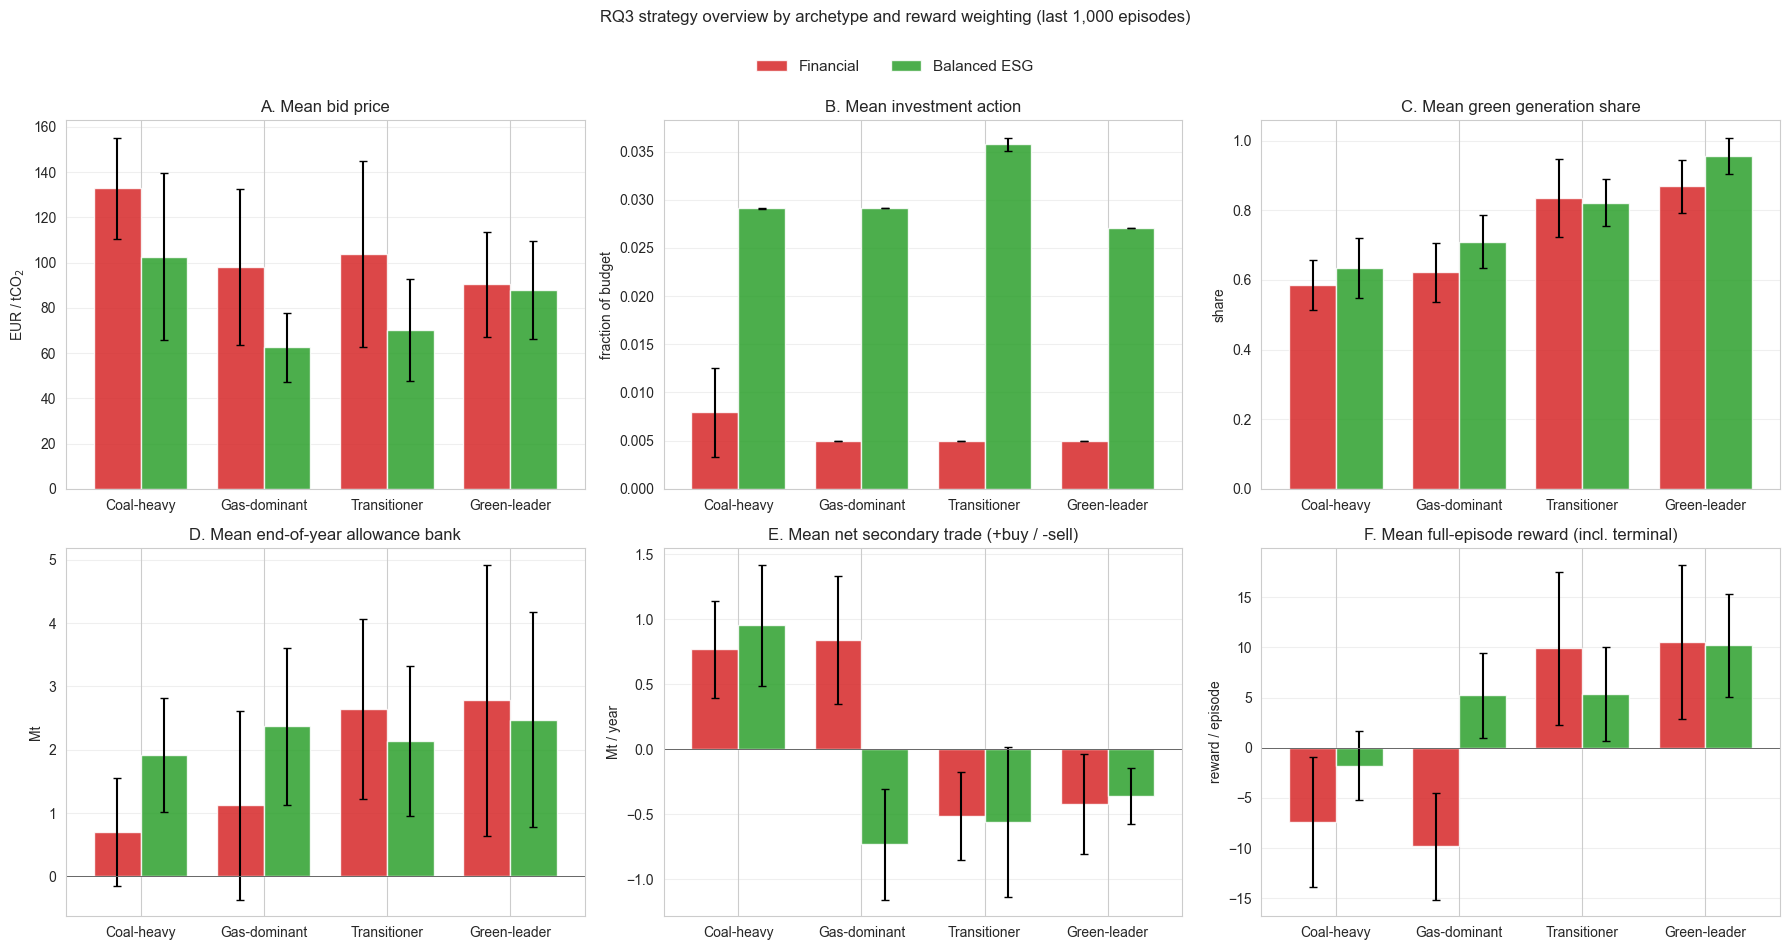

[RQ3] Exported thesis overview figure to: C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\results\analysis\rq3_decomp_bars.pdf
[RQ3] PNG preview written to: C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\results\analysis\rq3_decomp_bars.png


mean                    std          
weighting                          Balanced ESG Financial Balanced ESG Financial
metric                archetype                                                 
bank_end              Coal-heavy          1.920     0.701        0.902     0.853
                      Gas-dominant        2.368     1.127        1.238     1.492
                      Green-leader        2.477     2.783        1.696     2.138
                      Transitioner        2.139     2.640        1.188     1.419
bid_price             Coal-heavy        102.617   132.844       36.897    22.275
                      Gas-dominant       62.592    98.210       15.163    34.444
                      Green-leader       88.041    90.401       21.591    23.107
                      Transitioner       70.142   103.786       22.613    41.166
green_fraction        Coal-heavy          0.635     0.586        0.086     0.073
                      Gas-dominant        0.710     0.622        0.077     0.084
                      Green-leader        0.957     0.870        0.051     0.076
                      Transitioner        0.822     0.835        0.068     0.113
invest_frac_post_clip Coal-heavy          0.029     0.008        0.000     0.005
                      Gas-dominant        0.029     0.005        0.000     0.000
                      Green-leader        0.027     0.005        0.000     0.000
                      Transitioner        0.036     0.005        0.001     0.000
reward_episode_total  Coal-heavy         -1.793    -7.412        3.425     6.473
                      Gas-dominant        5.219    -9.792        4.250     5.325
                      Green-leader       10.210    10.558        5.127     7.681
                      Transitioner        5.326     9.892        4.696     7.643
trade_qty             Coal-heavy          0.956     0.772        0.465     0.373
                      Gas-dominant       -0.730     0.844        0.424     0.494
                      Green-leader       -0.356    -0.418        0.216     0.383
                      Transitioner       -0.557    -0.511        0.576     0.338

In [25]:
# Thesis export for Figure fig:rq3-decomp-bars.
# Compact 2x3 overview matching the RQ3.1-3.4 bar style:
# grouped paired bars per archetype, red = Financial, green = Balanced ESG.
#
# Sourced from `rq3_unified_df` built in the cell above (per-(run, episode,
# agent) frame). Using the same source guarantees the bar values reported
# here match the per-agent / per-archetype tables exactly. Panel F shows the
# full-episode reward total (ep_df sum, includes terminal-year payoff).

RQ3_DECOMP_BARS_PDF = PROJECT_ROOT / 'results' / 'analysis' / 'rq3_decomp_bars.pdf'
RQ3_DECOMP_BARS_PNG = PROJECT_ROOT / 'results' / 'analysis' / 'rq3_decomp_bars.png'
RQ3_WEIGHTING_ORDER = ['Financial', 'Balanced ESG']
RQ3_WEIGHTING_COLORS = {'Financial': '#d62728', 'Balanced ESG': '#2ca02c'}


def _reward_total_note(source):
    if 'reward_episode_total' not in source.columns:
        return '[RQ3] reward_episode_total unavailable; panel F shows reward_base year-mean as a fallback.'
    grouped_total = (
        source.groupby(['archetype', 'weighting'])['reward_episode_total']
        .mean()
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )
    if grouped_total.empty:
        return '[RQ3] reward_episode_total has no finite values; panel F shows reward_base year-mean as a fallback.'
    return (
        '[RQ3] Panel F uses reward_episode_total = sum of per-year rewards from ep_df '
        '(includes the final-year terminal payoff). '
        f'Grouped mean range {grouped_total.min():.2f} to {grouped_total.max():.2f}.'
    )


def _plot_rq3_decomp_bars(source, metric_specs, pdf_path, png_path):
    x = np.arange(len(ARCHETYPES), dtype=float)
    bar_width = 0.38
    offsets = {'Financial': -bar_width / 2, 'Balanced ESG': bar_width / 2}

    summary_rows = []

    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    axes_flat = axes.ravel()

    for panel_idx, (ax, (metric, title, ylabel)) in enumerate(zip(axes_flat, metric_specs)):
        for weighting in RQ3_WEIGHTING_ORDER:
            means, stds = [], []
            for arch in ARCHETYPES:
                if metric not in source.columns:
                    means.append(np.nan); stds.append(np.nan)
                    continue
                sub = source[(source['archetype'] == arch) & (source['weighting'] == weighting)][metric]
                sub = pd.to_numeric(sub, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
                mean_val = float(sub.mean()) if not sub.empty else np.nan
                std_val = float(sub.std()) if not sub.empty else np.nan
                means.append(mean_val)
                stds.append(std_val)
                summary_rows.append({
                    'metric': metric, 'archetype': arch, 'weighting': weighting,
                    'mean': mean_val, 'std': std_val,
                })
            ax.bar(
                x + offsets[weighting], means,
                width=bar_width, yerr=stds,
                color=RQ3_WEIGHTING_COLORS[weighting],
                alpha=0.85, capsize=3, label=weighting,
            )

        ax.axhline(0.0, color='0.4', linewidth=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels(ARCHETYPES, fontsize=10)
        ax.set(title=f'{chr(65 + panel_idx)}. {title}', ylabel=ylabel)
        ax.grid(True, alpha=0.3, axis='y')
        ax.margins(x=0.06)

    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.01),
        fontsize=11,
    )
    plt.suptitle(
        f'RQ3 strategy overview by archetype and reward weighting '
        f'(last {TAIL_EPISODES:,} episodes)',
        fontsize=12, y=1.05,
    )
    plt.tight_layout()

    pdf_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(pdf_path, bbox_inches='tight')
    fig.savefig(png_path, bbox_inches='tight', dpi=300)
    plt.show()

    summary = (
        pd.DataFrame(summary_rows)
        .set_index(['metric', 'archetype', 'weighting'])
        .unstack('weighting')
    )
    return summary


if 'rq3_unified_df' not in globals() or rq3_unified_df is None or rq3_unified_df.empty:
    print('[RQ3] rq3_unified_df not available - run the RQ3.5 cell above first.')
else:
    print(_reward_total_note(rq3_unified_df))
    rq3_overview_metric_specs = [
        ('bid_price', 'Mean bid price', r'EUR / tCO$_2$'),
        ('invest_frac_post_clip', 'Mean investment action', 'fraction of budget'),
        ('green_fraction', 'Mean green generation share', 'share'),
        ('bank_end', 'Mean end-of-year allowance bank', 'Mt'),
        ('trade_qty', 'Mean net secondary trade (+buy / -sell)', 'Mt / year'),
        ('reward_episode_total', 'Mean full-episode reward (incl. terminal)', 'reward / episode'),
    ]
    rq3_decomp_bar_summary = _plot_rq3_decomp_bars(
        rq3_unified_df,
        rq3_overview_metric_specs,
        RQ3_DECOMP_BARS_PDF,
        RQ3_DECOMP_BARS_PNG,
    )
    print(f'[RQ3] Exported thesis overview figure to: {RQ3_DECOMP_BARS_PDF}')
    print(f'[RQ3] PNG preview written to: {RQ3_DECOMP_BARS_PNG}')
    display(rq3_decomp_bar_summary.round(3))


### RQ3.6 — Strategy verdict: regret, total cost of ownership, and effective carbon price

RQ3.5 already gives a per-agent reward decomposition. The cells below
go one level further and try to answer the *strategy* question
directly: **which (archetype × weighting) cell wins, and by how much?**

Three lenses are produced, all built from the same converged-window
artefacts used by RQ3.5 (`rq3_unified_df` for reward channels and a
fresh per-(run, episode, agent) frame of raw € flows for the cost
buckets):

1. **Total cost of ownership (TCO).** A single 12-year-€ figure per
   agent — auction spend + secondary spend + invest cost + penalty —
   that a CFO can read directly. MAC fuel-switching cost is broken
   out separately as it is an *abatement* spend rather than an
   allowance spend.
2. **Effective carbon price paid.** Total euros spent on allowances
   ÷ tonnes acquired net of sales (auction + signed secondary).
   Net-seller archetypes can land below the clearing price — and may
   even go negative.
3. **Regret within archetype.** For each of the four starting
   archetypes, how far is each twin from the best-performing
   twin in the same archetype? This isolates the *strategy* effect
   from the *starting endowment* effect.

The closing scorecard ranks the eight (archetype, weighting) cells by
all three lenses simultaneously and names the winner on each axis.


RQ3.6a — per-agent 12-year cost league table (M€; mean per episode over last 1000 eps):


,agent_no,agent,archetype,weighting,auction_cost,trade_cost,invest_cost,penalty,mac_cost,tco_meur,tco_with_mac_meur,allowance_spend_meur,net_allowances_mt,effective_carbon_price_eur_per_t
0,1,A1,Coal-heavy,Financial,1177.02,801.79,677.46,1528.87,57.72,4185.14,4242.87,1978.81,30.83,63.76
1,2,A2,Coal-heavy,Balanced ESG,958.54,1848.12,954.17,241.26,48.62,4002.08,4050.71,2806.66,30.36,91.99
2,3,A3,Gas-dominant,Financial,864.21,1738.71,391.30,857.55,31.97,3851.76,3883.73,2602.92,26.72,95.95
3,4,A4,Gas-dominant,Balanced ESG,1691.64,-984.96,1056.05,182.52,4.16,1945.25,1949.41,706.68,24.46,29.32
4,5,A5,Transitioner,Financial,1202.95,-1077.48,830.73,83.45,9.20,1039.64,1048.84,125.47,16.71,3.86
5,6,A6,Transitioner,Balanced ESG,1127.78,-781.16,786.50,182.24,1.98,1315.37,1317.35,346.62,15.18,21.17
6,7,A7,Green-leader,Financial,956.69,-890.70,300.64,45.70,1.94,412.33,414.27,65.99,13.35,0.06
7,8,A8,Green-leader,Balanced ESG,688.33,-618.98,889.71,14.53,0.12,973.59,973.70,69.35,9.29,4.71


RQ3.6a — per-(archetype × weighting) 12-year cost cell table (M€):


auction_cost  trade_cost  invest_cost  penalty  mac_cost  tco_meur  tco_with_mac_meur  allowance_spend_meur  net_allowances_mt  effective_carbon_price_eur_per_t
archetype    weighting                                                                                                                                                                     
Coal-heavy   Financial          1177.02      801.79       677.46  1528.87     57.72   4185.14            4242.87               1978.81              30.83                             63.76
             Balanced ESG        958.54     1848.12       954.17   241.26     48.62   4002.08            4050.71               2806.66              30.36                             91.99
Gas-dominant Financial           864.21     1738.71       391.30   857.55     31.97   3851.76            3883.73               2602.92              26.72                             95.95
             Balanced ESG       1691.64     -984.96      1056.05   182.52      4.16   1945.25            1949.41                706.68              24.46                             29.32
Transitioner Financial          1202.95    -1077.48       830.73    83.45      9.20   1039.64            1048.84                125.47              16.71                              3.86
             Balanced ESG       1127.78     -781.16       786.50   182.24      1.98   1315.37            1317.35                346.62              15.18                             21.17
Green-leader Financial           956.69     -890.70       300.64    45.70      1.94    412.33             414.27                 65.99              13.35                              0.06
             Balanced ESG        688.33     -618.98       889.71    14.53      0.12    973.59             973.70                 69.35               9.29                              4.71

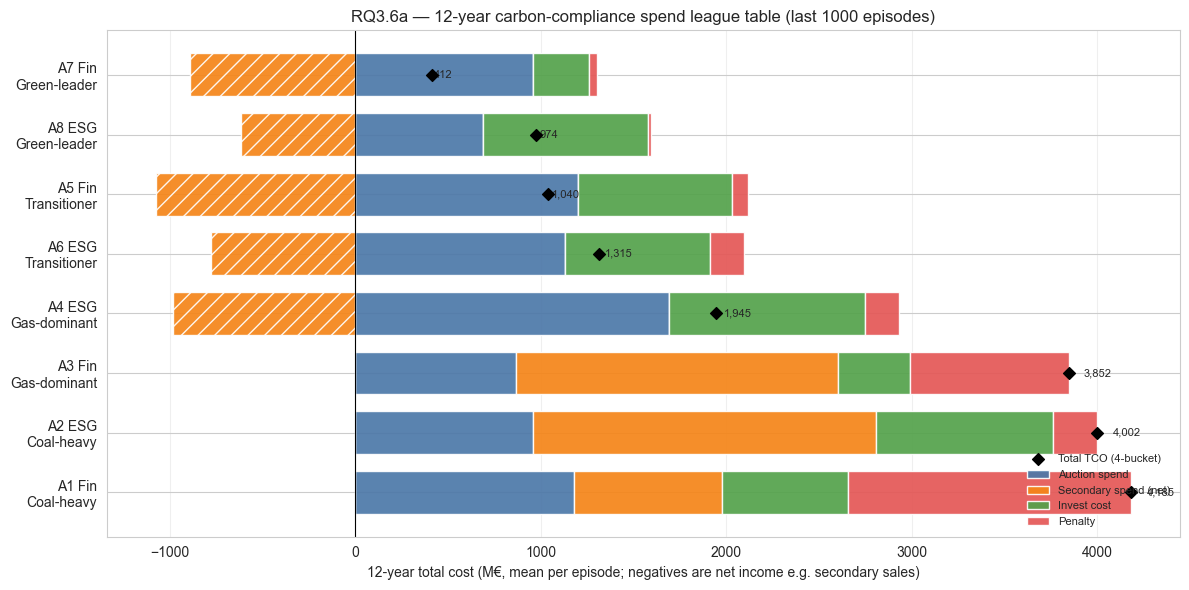

In [26]:
# RQ3.6a — 12-year total cost of ownership (TCO) per agent.
#
# Pulls raw € flows from the year_log:
#   auction_cost_A{i}   auction-clearing payments (M€)
#   trade_cost_A{i}     net secondary cash flow (M€; +pay, -receive)
#   invest_cost_A{i}    capex on renewable additions (M€)
#   penalty_A{i}        non-compliance penalties (M€)
#   mac_cost_A{i}       MAC fuel-switching cost (M€, kept separate)
# Sums across the 12 sim years per (run, episode, agent), then takes
# the mean across the last TAIL_EPISODES converged episodes.

_COST_BUCKETS = [
    ('auction_cost', 'Auction spend'),
    ('trade_cost',   'Secondary spend (net)'),
    ('invest_cost',  'Invest cost'),
    ('penalty',      'Penalty'),
]
_AUX_BUCKETS = [('mac_cost', 'MAC fuel-switch')]

def _build_agent_cost_frame():
    rows = []
    for run_key, run_data in runs.items():
        yr = tail_year_rows(run_data)
        if yr is None or yr.empty or 'episode' not in yr.columns:
            continue
        ep_idx = pd.to_numeric(yr['episode'], errors='coerce')
        for agent_idx in range(N_AGENTS):
            agent_no = agent_idx + 1
            episode_sum = {}
            for prefix, _ in _COST_BUCKETS + _AUX_BUCKETS:
                col = f'{prefix}_A{agent_no}'
                if col in yr.columns:
                    episode_sum[prefix] = (
                        pd.to_numeric(yr[col], errors='coerce').fillna(0.0)
                        .groupby(ep_idx).sum()
                    )
                else:
                    episode_sum[prefix] = pd.Series(dtype=float)

            alloc_col = f'alloc_A{agent_no}'
            trade_qty_col = f'trade_qty_A{agent_no}'
            alloc_sum = (
                pd.to_numeric(yr[alloc_col], errors='coerce').fillna(0.0)
                .groupby(ep_idx).sum()
                if alloc_col in yr.columns else pd.Series(dtype=float)
            )
            trade_qty_sum = (
                pd.to_numeric(yr[trade_qty_col], errors='coerce').fillna(0.0)
                .groupby(ep_idx).sum()
                if trade_qty_col in yr.columns else pd.Series(dtype=float)
            )

            episodes = alloc_sum.index
            for ep in episodes:
                rows.append({
                    'sweep': run_key[0], 'variant': run_key[1], 'seed': run_key[2],
                    'episode': float(ep),
                    'agent_no': agent_no,
                    'agent': f'A{agent_no}',
                    'archetype': _agent_archetype(agent_idx),
                    'weighting': _agent_weighting(agent_idx),
                    'objective': _agent_objective_label(agent_no),
                    'auction_cost': float(episode_sum['auction_cost'].get(ep, np.nan)),
                    'trade_cost':   float(episode_sum['trade_cost'].get(ep, np.nan)),
                    'invest_cost':  float(episode_sum['invest_cost'].get(ep, np.nan)),
                    'penalty':      float(episode_sum['penalty'].get(ep, np.nan)),
                    'mac_cost':     float(episode_sum['mac_cost'].get(ep, np.nan)),
                    'alloc_mt':     float(alloc_sum.get(ep, np.nan)),
                    'trade_qty_mt': float(trade_qty_sum.get(ep, np.nan)),
                })
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    df['tco_meur'] = df[['auction_cost', 'trade_cost', 'invest_cost', 'penalty']].sum(axis=1)
    df['tco_with_mac_meur'] = df['tco_meur'] + df['mac_cost'].fillna(0.0)
    # Effective carbon price paid: euros for allowances / net tonnes acquired.
    # auction_cost + trade_cost is the net cash outlay on allowances
    # (trade_cost is +pay / -receive so net-sellers contribute negative);
    # alloc + trade_qty is tonnes received net of sales (trade_qty signed).
    df['allowance_spend_meur'] = df['auction_cost'].fillna(0.0) + df['trade_cost'].fillna(0.0)
    df['net_allowances_mt'] = df['alloc_mt'].fillna(0.0) + df['trade_qty_mt'].fillna(0.0)
    # Convert M€ / Mt -> €/t.  Guard against ~zero denominator.
    denom = df['net_allowances_mt'].where(df['net_allowances_mt'].abs() > 1e-6, np.nan)
    df['effective_carbon_price_eur_per_t'] = df['allowance_spend_meur'] / denom
    return df

rq36_cost_df = _build_agent_cost_frame()

if rq36_cost_df.empty:
    print('RQ3.6: no cost columns available in year_log; skipping TCO.')
else:
    _agg_cols = [
        'auction_cost', 'trade_cost', 'invest_cost', 'penalty',
        'mac_cost', 'tco_meur', 'tco_with_mac_meur',
        'allowance_spend_meur', 'net_allowances_mt',
        'effective_carbon_price_eur_per_t',
    ]
    # Per-agent league table (mean per-episode value across last TAIL_EPISODES).
    per_agent_tco = (
        rq36_cost_df.groupby(['agent_no', 'agent', 'archetype', 'weighting'], sort=True)[_agg_cols]
        .mean()
        .reset_index()
        .sort_values('agent_no')
        .round(2)
    )
    print(f'RQ3.6a — per-agent 12-year cost league table (M€; mean per episode over last {TAIL_EPISODES} eps):')
    display(per_agent_tco)

    # Per-(archetype, weighting) cell table — directly answers "which cell is cheapest?".
    arch_order = [(arch, w) for arch in ARCHETYPES for w in ['Financial', 'Balanced ESG']]
    per_cell_tco = (
        rq36_cost_df.groupby(['archetype', 'weighting'], sort=False)[_agg_cols]
        .mean()
        .reindex(arch_order)
        .round(2)
    )
    print('RQ3.6a — per-(archetype × weighting) 12-year cost cell table (M€):')
    display(per_cell_tco)

    # Stacked-bar chart of the four TCO buckets, sorted by total TCO ascending
    # (cheapest 12-year carbon spend at the top).
    plot_df = per_agent_tco.copy()
    plot_df['agent_label'] = plot_df.apply(
        lambda r: f"A{int(r['agent_no'])} {('Fin' if r['weighting'] == 'Financial' else 'ESG')}\n{r['archetype']}",
        axis=1,
    )
    plot_df = plot_df.sort_values('tco_meur', ascending=True).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(12, 6))
    y = np.arange(len(plot_df))
    left_pos = np.zeros(len(plot_df))
    left_neg = np.zeros(len(plot_df))
    palette = {
        'Auction spend':         '#4c78a8',
        'Secondary spend (net)': '#f58518',
        'Invest cost':           '#54a24b',
        'Penalty':               '#e45756',
    }
    for prefix, label in _COST_BUCKETS:
        vals = plot_df[prefix].fillna(0.0).to_numpy(dtype=float)
        pos = np.clip(vals, 0.0, None)
        neg = np.clip(vals, None, 0.0)
        if np.any(pos > 0):
            ax.barh(y, pos, left=left_pos, color=palette[label], label=label, height=0.72, alpha=0.92)
            left_pos += pos
        if np.any(neg < 0):
            ax.barh(y, neg, left=left_neg, color=palette[label], label='_nolegend_', height=0.72, alpha=0.92, hatch='//')
            left_neg += neg
    # Total marker
    ax.scatter(plot_df['tco_meur'].values, y, marker='D', color='black', s=36, zorder=5, label='Total TCO (4-bucket)')
    for yi, v in zip(y, plot_df['tco_meur'].values):
        if np.isfinite(v):
            ax.text(v + abs(v) * 0.02 + 1, yi, f'{v:,.0f}', va='center', ha='left', fontsize=8)
    ax.set_yticks(y); ax.set_yticklabels(plot_df['agent_label'])
    ax.invert_yaxis()
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('12-year total cost (M€, mean per episode; negatives are net income e.g. secondary sales)')
    ax.set_title(f'RQ3.6a — 12-year carbon-compliance spend league table (last {TAIL_EPISODES} episodes)')
    ax.grid(True, axis='x', alpha=0.3)
    ax.legend(loc='lower right', fontsize=8, frameon=False)
    plt.tight_layout()
    plt.show()


RQ3.6b — implied carbon price paid per agent (€/t; sorted ascending; median clearing in tail window = 45.0 €/t):


,agent_no,agent,archetype,weighting,allowance_spend_meur,net_allowances_mt,effective_carbon_price_eur_per_t
6,7,A7,Green-leader,Financial,65.99,13.35,0.06
4,5,A5,Transitioner,Financial,125.47,16.71,3.86
7,8,A8,Green-leader,Balanced ESG,69.35,9.29,4.71
5,6,A6,Transitioner,Balanced ESG,346.62,15.18,21.17
3,4,A4,Gas-dominant,Balanced ESG,706.68,24.46,29.32
0,1,A1,Coal-heavy,Financial,1978.81,30.83,63.76
1,2,A2,Coal-heavy,Balanced ESG,2806.66,30.36,91.99
2,3,A3,Gas-dominant,Financial,2602.92,26.72,95.95


C:\Users\danie\AppData\Local\Temp\ipykernel_5056\448126167.py:62: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


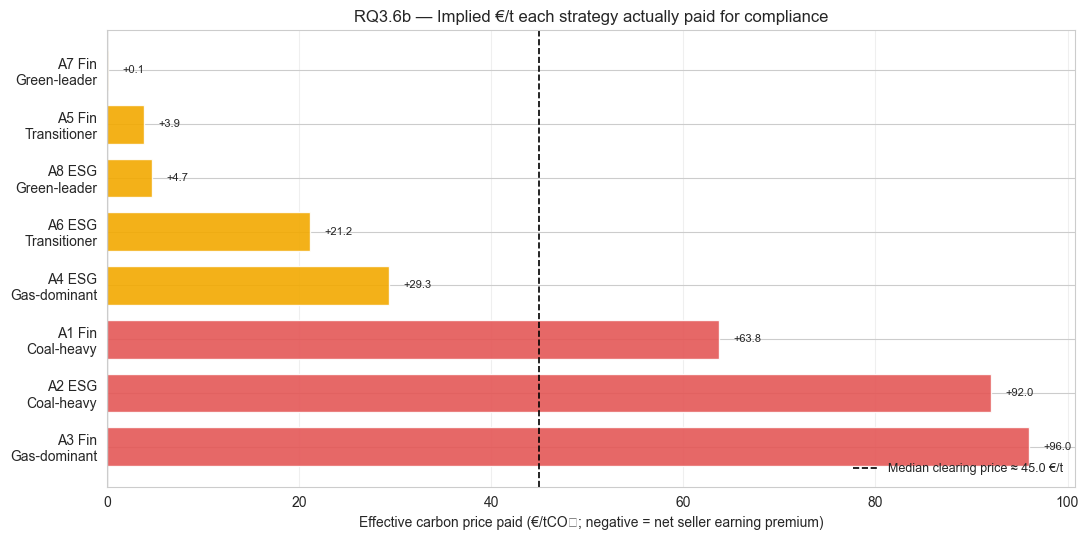

In [27]:
# RQ3.6b — Effective carbon price actually paid per agent.
#
# allowance_spend_meur = auction_cost + trade_cost      (net allowance outlay)
# net_allowances_mt    = alloc + trade_qty              (signed; net of sales)
# eff_price_eur_per_t  = allowance_spend / net_allowances   (€/t)
#
# Net sellers (allowance_spend < 0 because trade_cost is negative when they
# receive cash) divided by positive net tonnes give a negative effective
# price — i.e. they are paid to hold allowances rather than paying for them.

if rq36_cost_df.empty:
    print('RQ3.6b: skipped (no cost frame).')
else:
    eff_cols = ['allowance_spend_meur', 'net_allowances_mt', 'effective_carbon_price_eur_per_t']
    eff_per_agent = (
        rq36_cost_df.groupby(['agent_no', 'agent', 'archetype', 'weighting'], sort=True)[eff_cols]
        .mean()
        .reset_index()
        .sort_values('effective_carbon_price_eur_per_t')
        .round(2)
    )

    # Reference: median clearing price across the same tail window, for context.
    clearing_rows = []
    for k, run in runs.items():
        yr = tail_year_rows(run)
        if not yr.empty and 'clearing_price' in yr.columns:
            clearing_rows.append(pd.to_numeric(yr['clearing_price'], errors='coerce').dropna())
    ref_clearing = float(pd.concat(clearing_rows).median()) if clearing_rows else np.nan

    print(
        f'RQ3.6b — implied carbon price paid per agent (€/t; sorted ascending; '
        f'median clearing in tail window = {ref_clearing:,.1f} €/t):'
    )
    display(eff_per_agent)

    fig, ax = plt.subplots(figsize=(11, 5.5))
    plot = eff_per_agent.copy()
    plot['agent_label'] = plot.apply(
        lambda r: f"A{int(r['agent_no'])} {('Fin' if r['weighting'] == 'Financial' else 'ESG')}\n{r['archetype']}",
        axis=1,
    )
    y = np.arange(len(plot))
    vals = plot['effective_carbon_price_eur_per_t'].to_numpy(dtype=float)
    colors = ['#54a24b' if v < 0 else ('#f2a900' if v < ref_clearing else '#e45756') for v in vals]
    ax.barh(y, vals, color=colors, alpha=0.9, height=0.72)
    if np.isfinite(ref_clearing):
        ax.axvline(ref_clearing, color='black', lw=1.2, ls='--',
                   label=f'Median clearing price ≈ {ref_clearing:,.1f} €/t')
    ax.axvline(0, color='black', lw=0.8)
    for yi, v in zip(y, vals):
        if np.isfinite(v):
            ha = 'left' if v >= 0 else 'right'
            offset = 1.5 if v >= 0 else -1.5
            ax.text(v + offset, yi, f'{v:+,.1f}', va='center', ha=ha, fontsize=8)
    ax.set_yticks(y); ax.set_yticklabels(plot['agent_label'])
    ax.invert_yaxis()
    ax.set_xlabel('Effective carbon price paid (€/tCO₂; negative = net seller earning premium)')
    ax.set_title('RQ3.6b — Implied €/t each strategy actually paid for compliance')
    ax.grid(True, axis='x', alpha=0.3)
    ax.legend(loc='lower right', fontsize=9, frameon=False)
    plt.tight_layout()
    plt.show()


RQ3.6c — Within-archetype regret (per agent vs. best twin in the same archetype):


agent  reward   archetype_leader  leader_reward  regret_vs_leader
reward_view                        archetype    weighting                                                                     
Full-episode reward (post-shaping) Coal-heavy   Financial       A1  -7.412  A2 (Balanced ESG)         -1.793             5.619
                                                Balanced ESG    A2  -1.793  A2 (Balanced ESG)         -1.793             0.000
Reward_base (sum over 12 years)    Coal-heavy   Financial       A1  -7.887  A2 (Balanced ESG)         -2.308             5.579
                                                Balanced ESG    A2  -2.308  A2 (Balanced ESG)         -2.308             0.000
Full-episode reward (post-shaping) Gas-dominant Financial       A3  -9.792  A4 (Balanced ESG)          5.219            15.012
                                                Balanced ESG    A4   5.219  A4 (Balanced ESG)          5.219             0.000
Reward_base (sum over 12 years)    Gas-dominant Financial       A3 -10.287  A4 (Balanced ESG)          4.698            14.985
                                                Balanced ESG    A4   4.698  A4 (Balanced ESG)          4.698             0.000
Full-episode reward (post-shaping) Transitioner Financial       A5   9.892     A5 (Financial)          9.892             0.000
                                                Balanced ESG    A6   5.326     A5 (Financial)          9.892             4.565
Reward_base (sum over 12 years)    Transitioner Financial       A5   9.368     A5 (Financial)          9.368             0.000
                                                Balanced ESG    A6   4.804     A5 (Financial)          9.368             4.564
Full-episode reward (post-shaping) Green-leader Financial       A7  10.558     A7 (Financial)         10.558             0.000
                                                Balanced ESG    A8  10.210     A7 (Financial)         10.558             0.348
Reward_base (sum over 12 years)    Green-leader Financial       A7  10.032     A7 (Financial)         10.032             0.000
                                                Balanced ESG    A8   9.681     A7 (Financial)         10.032             0.351

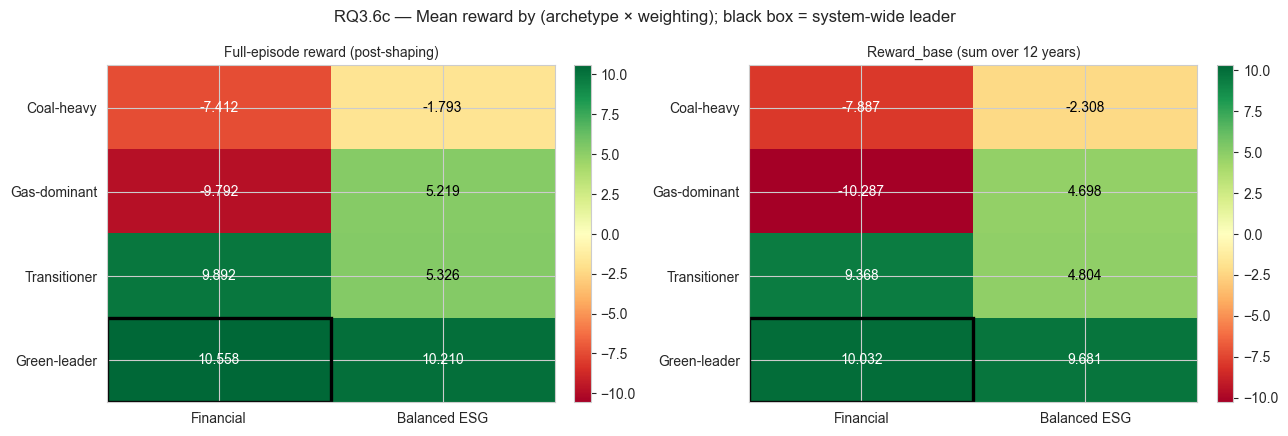

In [28]:
# RQ3.6c — Within-archetype regret + cross-archetype reward leader.
#
# For each archetype, the two twins (Financial / Balanced ESG) start
# from identical endowments. The reward gap between them is therefore a
# clean measurement of "what does the chosen objective cost you, given
# this starting mix?". We report it for two reward views:
#   * reward_episode_total      -> full-episode post-shaping reward.
#   * reward_base_episode_sum   -> base reward summed across the 12 years.

if 'rq3_unified_df' not in globals() or rq3_unified_df is None or rq3_unified_df.empty:
    print('RQ3.6c: requires `rq3_unified_df` from RQ3.5 — re-run that cell first.')
else:
    reward_views = [
        ('reward_episode_total',    'Full-episode reward (post-shaping)'),
        ('reward_base_episode_sum', 'Reward_base (sum over 12 years)'),
    ]
    available_views = [(c, lbl) for c, lbl in reward_views if c in rq3_unified_df.columns]

    arch_obj_means = (
        rq3_unified_df.groupby(['archetype', 'weighting', 'agent_no'], sort=False)[
            [c for c, _ in available_views]
        ]
        .mean()
        .reset_index()
    )

    regret_rows = []
    for arch in ARCHETYPES:
        sub = arch_obj_means[arch_obj_means['archetype'] == arch]
        if sub.empty:
            continue
        for col, label in available_views:
            leader_val = sub[col].max()
            leader = sub.loc[sub[col].idxmax()]
            for _, row in sub.iterrows():
                regret_rows.append({
                    'archetype': arch,
                    'weighting': row['weighting'],
                    'agent': f"A{int(row['agent_no'])}",
                    'reward_view': label,
                    'reward': float(row[col]),
                    'archetype_leader': f"A{int(leader['agent_no'])} ({leader['weighting']})",
                    'leader_reward': float(leader_val),
                    'regret_vs_leader': float(leader_val - row[col]),
                })
    regret_df = pd.DataFrame(regret_rows).round(3)
    print('RQ3.6c — Within-archetype regret (per agent vs. best twin in the same archetype):')
    display(
        regret_df.set_index(['reward_view', 'archetype', 'weighting'])[
            ['agent', 'reward', 'archetype_leader', 'leader_reward', 'regret_vs_leader']
        ]
    )

    # Cross-archetype winner — heatmap of mean reward by (archetype, weighting).
    fig, axes = plt.subplots(1, len(available_views), figsize=(6.5 * len(available_views), 4.4))
    if len(available_views) == 1:
        axes = [axes]
    for ax, (col, label) in zip(axes, available_views):
        mat = (
            rq3_unified_df.groupby(['archetype', 'weighting'])[col]
            .mean()
            .unstack('weighting')
            .reindex(index=ARCHETYPES, columns=['Financial', 'Balanced ESG'])
        )
        arr = mat.to_numpy(dtype=float)
        absmax = float(np.nanmax(np.abs(arr))) if np.isfinite(arr).any() else 1.0
        if absmax == 0: absmax = 1.0
        im = ax.imshow(arr, cmap='RdYlGn', vmin=-absmax, vmax=absmax, aspect='auto')
        ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns)
        ax.set_yticks(range(len(mat.index))); ax.set_yticklabels(mat.index)
        # Mark winner.
        if np.isfinite(arr).any():
            r_win, c_win = np.unravel_index(np.nanargmax(arr), arr.shape)
            ax.add_patch(plt.Rectangle((c_win - 0.5, r_win - 0.5), 1, 1, fill=False, edgecolor='black', lw=2.4))
        for r in range(arr.shape[0]):
            for c in range(arr.shape[1]):
                v = arr[r, c]
                if np.isfinite(v):
                    ax.text(c, r, f'{v:.3f}', ha='center', va='center',
                            color=('white' if abs(v) > absmax * 0.55 else 'black'), fontsize=10)
        ax.set_title(label, fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle('RQ3.6c — Mean reward by (archetype × weighting); black box = system-wide leader', fontsize=12)
    plt.tight_layout()
    plt.show()

    # Stash for the scorecard cell.
    rq36_regret_df = regret_df
    rq36_reward_per_cell = (
        rq3_unified_df.groupby(['archetype', 'weighting'])[
            [c for c, _ in available_views]
        ]
        .mean()
        .round(4)
    )


In [29]:
# RQ3.6d — Strategy verdict scorecard.
#
# Combines the three lenses into one (archetype × weighting) table:
#   * reward (higher is better)        — full-episode post-shaping reward
#   * reward_base (higher is better)   — pre-shaping economic reward
#   * TCO (lower is better)            — 12-year € spend (4-bucket)
#   * effective carbon price (lower)   — €/t actually paid for allowances
# Each lens is rank-ordered 1..8 and a final "verdict" calls out which
# cell wins on each axis.

if rq36_cost_df.empty or 'rq36_reward_per_cell' not in globals():
    print('RQ3.6d: skipped (need RQ3.6a cost frame and RQ3.6c reward-per-cell table).')
else:
    cost_per_cell = (
        rq36_cost_df.groupby(['archetype', 'weighting'])[
            ['tco_meur', 'effective_carbon_price_eur_per_t']
        ]
        .mean()
    )
    scorecard = rq36_reward_per_cell.join(cost_per_cell, how='outer')
    # Reorder rows in canonical archetype × weighting order.
    arch_order = [(arch, w) for arch in ARCHETYPES for w in ['Financial', 'Balanced ESG']]
    scorecard = scorecard.reindex(arch_order)

    rank_frame = scorecard.copy()
    # Higher-is-better for reward channels, lower-is-better for cost / €/t.
    for c in scorecard.columns:
        if c.startswith('reward'):
            rank_frame[f'{c}__rank'] = scorecard[c].rank(ascending=False, method='min')
        elif c in ('tco_meur', 'effective_carbon_price_eur_per_t'):
            rank_frame[f'{c}__rank'] = scorecard[c].rank(ascending=True, method='min')

    print('RQ3.6d — Strategy verdict scorecard (raw values + per-lens rank; 1 = best):')
    display(rank_frame.round(3))

    # Headline callouts.
    def _winner_label(series, mode):
        if series.dropna().empty:
            return 'n/a'
        idx = series.idxmin() if mode == 'min' else series.idxmax()
        val = series.loc[idx]
        return f'{idx[0]} / {idx[1]}  ({val:+.3f})'

    print()
    print('Headline verdict (system-wide winner on each lens):')
    if 'reward_episode_total' in scorecard.columns:
        print(f'  • Highest full-episode reward     : {_winner_label(scorecard["reward_episode_total"], "max")}')
    if 'reward_base_episode_sum' in scorecard.columns:
        print(f'  • Highest reward_base (12y sum)   : {_winner_label(scorecard["reward_base_episode_sum"], "max")}')
    print(f'  • Lowest 12-year TCO (cheapest)     : {_winner_label(scorecard["tco_meur"], "min")}')
    print(f'  • Lowest effective €/t paid         : {_winner_label(scorecard["effective_carbon_price_eur_per_t"], "min")}')

    # Composite "best strategy" — sum the per-lens ranks; lowest = best.
    rank_cols = [c for c in rank_frame.columns if c.endswith('__rank')]
    if rank_cols:
        composite = rank_frame[rank_cols].sum(axis=1).rename('composite_rank_sum')
        best = composite.idxmin()
        print()
        print('Composite rank (sum of per-lens ranks; lower = better across all lenses):')
        display(composite.sort_values().to_frame().round(2))
        print(f'  ⇒ Best all-round strategy cell: {best[0]} / {best[1]}  (rank sum = {composite.loc[best]:.0f})')

    rq36_scorecard = rank_frame


RQ3.6d — Strategy verdict scorecard (raw values + per-lens rank; 1 = best):


reward_episode_total  reward_base_episode_sum  tco_meur  effective_carbon_price_eur_per_t  reward_episode_total__rank  reward_base_episode_sum__rank  tco_meur__rank  \
archetype    weighting                                                                                                                                                                            
Coal-heavy   Financial                   -7.412                   -7.887  4185.142                            63.756                         7.0                            7.0             8.0   
             Balanced ESG                -1.793                   -2.308  4002.085                            91.986                         6.0                            6.0             7.0   
Gas-dominant Financial                   -9.792                  -10.287  3851.760                            95.947                         8.0                            8.0             6.0   
             Balanced ESG                 5.219                    4.698  1945.249                            29.322                         5.0                            5.0             5.0   
Transitioner Financial                    9.892                    9.368  1039.643                             3.860                         3.0                            3.0             3.0   
             Balanced ESG                 5.326                    4.804  1315.369                            21.169                         4.0                            4.0             4.0   
Green-leader Financial                   10.558                   10.032   412.330                             0.061                         1.0                            1.0             1.0   
             Balanced ESG                10.210                    9.681   973.587                             4.706                         2.0                            2.0             2.0   

                           effective_carbon_price_eur_per_t__rank  
archetype    weighting                                             
Coal-heavy   Financial                                        6.0  
             Balanced ESG                                     7.0  
Gas-dominant Financial                                        8.0  
             Balanced ESG                                     5.0  
Transitioner Financial                                        2.0  
             Balanced ESG                                     4.0  
Green-leader Financial                                        1.0  
             Balanced ESG                                     3.0


Headline verdict (system-wide winner on each lens):
  • Highest full-episode reward     : Green-leader / Financial  (+10.558)
  • Highest reward_base (12y sum)   : Green-leader / Financial  (+10.032)
  • Lowest 12-year TCO (cheapest)     : Green-leader / Financial  (+412.330)
  • Lowest effective €/t paid         : Green-leader / Financial  (+0.061)

Composite rank (sum of per-lens ranks; lower = better across all lenses):


composite_rank_sum
archetype    weighting                       
Green-leader Financial                    4.0
             Balanced ESG                 9.0
Transitioner Financial                   11.0
             Balanced ESG                16.0
Gas-dominant Balanced ESG                20.0
Coal-heavy   Balanced ESG                26.0
             Financial                   28.0
Gas-dominant Financial                   30.0

  ⇒ Best all-round strategy cell: Green-leader / Financial  (rank sum = 4)


RQ3.6e — Per-agent reward distribution + absolute best single episode:


,agent_no,agent,archetype,weighting,n_episodes,p10,median,mean,p90,best_value,best_sweep,best_seed,best_episode
7,8,A8,Green-leader,Balanced ESG,4000,5.359,9.551,10.210,15.339,61.054,default_seeds,1729,119342.0
4,5,A5,Transitioner,Financial,4000,2.485,8.727,9.892,19.831,55.681,default_seeds,6561,119506.0
6,7,A7,Green-leader,Financial,4000,1.518,9.938,10.558,20.827,47.466,default_seeds,8191,119010.0
5,6,A6,Transitioner,Balanced ESG,4000,0.247,5.397,5.326,10.756,21.996,default_seeds,6561,119577.0
3,4,A4,Gas-dominant,Balanced ESG,4000,-0.185,6.239,5.219,9.401,14.911,default_seeds,8191,119711.0
1,2,A2,Coal-heavy,Balanced ESG,4000,-6.095,-1.643,-1.793,2.382,9.258,default_seeds,6561,119488.0
2,3,A3,Gas-dominant,Financial,4000,-16.868,-9.416,-9.792,-3.172,8.290,default_seeds,1729,119496.0
0,1,A1,Coal-heavy,Financial,4000,-16.432,-6.640,-7.412,0.536,3.941,default_seeds,8191,119807.0


RQ3.6e — Per-agent 12-year TCO distribution + absolute cheapest single episode (M€):


,agent_no,agent,archetype,weighting,n_episodes,p10,median,mean,p90,best_value,best_sweep,best_seed,best_episode
6,7,A7,Green-leader,Financial,4000,-701.29,425.58,412.33,1461.84,-2114.16,default_seeds,5041,119492.0
4,5,A5,Transitioner,Financial,4000,-26.49,878.64,1039.64,2426.19,-1629.01,default_seeds,8191,119925.0
7,8,A8,Green-leader,Balanced ESG,4000,320.61,995.46,973.59,1616.39,-1434.37,default_seeds,1729,119375.0
5,6,A6,Transitioner,Balanced ESG,4000,361.66,1252.78,1315.37,2266.06,-974.52,default_seeds,8191,119102.0
3,4,A4,Gas-dominant,Balanced ESG,4000,601.06,1973.45,1945.25,3055.45,-484.79,default_seeds,5041,119334.0
2,3,A3,Gas-dominant,Financial,4000,2629.13,3827.95,3851.76,5111.93,767.52,default_seeds,1729,119496.0
1,2,A2,Coal-heavy,Balanced ESG,4000,3066.28,3969.16,4002.08,4963.59,1402.88,default_seeds,5041,119170.0
0,1,A1,Coal-heavy,Financial,4000,2828.11,4059.73,4185.14,5763.34,1622.89,default_seeds,5041,119224.0


RQ3.6e — Per-agent effective €/t distribution + absolute lowest single-episode price:


,agent_no,agent,archetype,weighting,n_episodes,p10,median,mean,p90,best_value,best_sweep,best_seed,best_episode
7,8,A8,Green-leader,Balanced ESG,4000,-42.49,12.21,4.71,46.71,-343.75,default_seeds,1729,119342.0
4,5,A5,Transitioner,Financial,4000,-65.62,14.68,3.86,49.36,-266.33,default_seeds,6561,119708.0
6,7,A7,Green-leader,Financial,4000,-64.24,5.31,0.06,51.95,-185.99,default_seeds,5041,119927.0
5,6,A6,Transitioner,Balanced ESG,4000,-27.02,27.85,21.17,55.85,-147.62,default_seeds,8191,119763.0
3,4,A4,Gas-dominant,Balanced ESG,4000,0.53,24.88,29.32,65.83,-55.15,default_seeds,1729,119102.0
1,2,A2,Coal-heavy,Balanced ESG,4000,67.69,90.94,91.99,118.66,4.51,default_seeds,6561,119448.0
2,3,A3,Gas-dominant,Financial,4000,61.28,83.70,95.95,158.15,36.02,default_seeds,1729,119496.0
0,1,A1,Coal-heavy,Financial,4000,50.47,61.82,63.76,79.57,42.91,default_seeds,8191,119933.0


RQ3.6e — Absolute best single-episode value per (archetype × weighting) cell:


lens                       Max reward  Min TCO (M€)  Min effective €/t
archetype    weighting                                                
Coal-heavy   Financial          3.941      1622.894             42.911
             Balanced ESG       9.258      1402.883              4.505
Gas-dominant Financial          8.290       767.517             36.020
             Balanced ESG      14.911      -484.787            -55.148
Transitioner Financial         55.681     -1629.006           -266.334
             Balanced ESG      21.996      -974.524           -147.624
Green-leader Financial         47.466     -2114.156           -185.990
             Balanced ESG      61.054     -1434.373           -343.748


System-wide absolute winners across the converged tail window:
  • Highest single-episode reward     : +61.054 → A8 (Green-leader / Balanced ESG); sweep=default_seeds seed=1729 ep=119342.0
  • Cheapest single-episode TCO       : -2,114.2 M€ → A7 (Green-leader / Financial); sweep=default_seeds seed=5041 ep=119492.0
  • Lowest single-episode €/t paid    : -343.75 €/t → A8 (Green-leader / Balanced ESG); sweep=default_seeds seed=1729 ep=119342.0


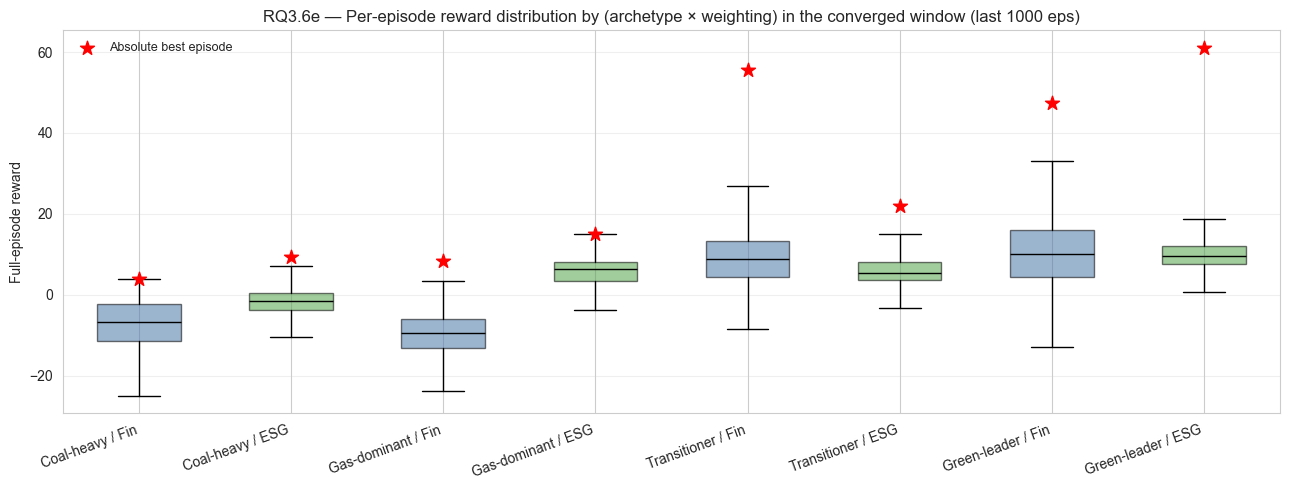

In [30]:
# RQ3.6e — Absolute winners in the converged window.
#
# Agents act differently each episode (policy stochasticity + market
# noise), so the mean-based tables above can hide a high-variance
# outperformer.  This cell looks at the *distribution* across the last
# TAIL_EPISODES converged episodes for each agent and per (archetype ×
# weighting) cell, and identifies the absolute winners:
#   * Max single-episode reward            (best episode any agent posted)
#   * Min single-episode TCO               (cheapest 12-year € outcome)
#   * Min single-episode effective €/t     (deepest discount / largest
#                                           premium earned as a seller)
# Per-agent quantile bands (P10 / P50 / P90) make the noise visible and
# show whether a winner is consistent or a lucky outlier.

if rq36_cost_df.empty or 'rq3_unified_df' not in globals() or rq3_unified_df.empty:
    print('RQ3.6e: requires the RQ3.6a cost frame and RQ3.5 unified frame.')
else:
    # 1) Per-agent distributions ------------------------------------------------
    def _quantile_table(df, value_col, group_cols, ascending_for_winner):
        """Return min / P10 / median / P90 / max + the (sweep,seed,episode) of
        the absolute winning row (min or max depending on `ascending_for_winner`).
        """
        rows = []
        for keys, sub in df.groupby(group_cols, sort=False, dropna=False):
            vals = pd.to_numeric(sub[value_col], errors='coerce').dropna()
            if vals.empty:
                continue
            if ascending_for_winner:
                idx_best = vals.idxmin(); best_val = vals.min()
            else:
                idx_best = vals.idxmax(); best_val = vals.max()
            best_row = sub.loc[idx_best]
            entry = dict(zip(group_cols if isinstance(group_cols, list) else [group_cols],
                             keys if isinstance(keys, tuple) else (keys,)))
            entry.update({
                'n_episodes': int(vals.size),
                'p10': float(vals.quantile(0.10)),
                'median': float(vals.median()),
                'mean': float(vals.mean()),
                'p90': float(vals.quantile(0.90)),
                'best_value': float(best_val),
                'best_sweep': best_row.get('sweep', ''),
                'best_seed': best_row.get('seed', ''),
                'best_episode': best_row.get('episode', np.nan),
            })
            rows.append(entry)
        return pd.DataFrame(rows)

    agent_keys = ['agent_no', 'agent', 'archetype', 'weighting']

    # Reward — higher is better, so winner is the max.
    if 'reward_episode_total' in rq3_unified_df.columns:
        reward_dist_agent = _quantile_table(
            rq3_unified_df, 'reward_episode_total', agent_keys, ascending_for_winner=False,
        ).sort_values('best_value', ascending=False).round(3)
        print('RQ3.6e — Per-agent reward distribution + absolute best single episode:')
        display(reward_dist_agent)

    # TCO — lower is better.
    tco_dist_agent = _quantile_table(
        rq36_cost_df, 'tco_meur', agent_keys, ascending_for_winner=True,
    ).sort_values('best_value', ascending=True).round(2)
    print('RQ3.6e — Per-agent 12-year TCO distribution + absolute cheapest single episode (M€):')
    display(tco_dist_agent)

    # Effective €/t — lower is better.
    eff_dist_agent = _quantile_table(
        rq36_cost_df, 'effective_carbon_price_eur_per_t', agent_keys, ascending_for_winner=True,
    ).sort_values('best_value', ascending=True).round(2)
    print('RQ3.6e — Per-agent effective €/t distribution + absolute lowest single-episode price:')
    display(eff_dist_agent)

    # 2) Per-(archetype × weighting) cell absolute winners ---------------------
    cell_keys = ['archetype', 'weighting']
    cell_winners_rows = []
    lens_specs = [
        ('reward_episode_total', 'Max reward', rq3_unified_df, False),
        ('tco_meur', 'Min TCO (M€)', rq36_cost_df, True),
        ('effective_carbon_price_eur_per_t', 'Min effective €/t', rq36_cost_df, True),
    ]
    for col, label, frame, asc in lens_specs:
        if col not in frame.columns:
            continue
        for keys, sub in frame.groupby(cell_keys, sort=False, dropna=False):
            vals = pd.to_numeric(sub[col], errors='coerce').dropna()
            if vals.empty:
                continue
            idx_best = (vals.idxmin() if asc else vals.idxmax())
            best_row = sub.loc[idx_best]
            cell_winners_rows.append({
                'lens': label,
                'archetype': keys[0], 'weighting': keys[1],
                'best_value': float(vals.loc[idx_best]),
                'agent': best_row.get('agent', ''),
                'sweep': best_row.get('sweep', ''),
                'seed': best_row.get('seed', ''),
                'episode': best_row.get('episode', np.nan),
            })
    cell_winners = (
        pd.DataFrame(cell_winners_rows)
        .pivot_table(
            index=['archetype', 'weighting'], columns='lens',
            values='best_value', aggfunc='first',
        )
        .reindex([(a, w) for a in ARCHETYPES for w in ['Financial', 'Balanced ESG']])
        .round(3)
    )
    print('RQ3.6e — Absolute best single-episode value per (archetype × weighting) cell:')
    display(cell_winners)

    # 3) System-wide absolute winners (one row per lens) -----------------------
    print()
    print('System-wide absolute winners across the converged tail window:')
    if 'reward_episode_total' in rq3_unified_df.columns:
        s = rq3_unified_df.loc[rq3_unified_df['reward_episode_total'].idxmax()]
        print(f'  • Highest single-episode reward     : '
              f'{s.get("reward_episode_total", float("nan")):+.3f} → A{int(s["agent_no"])} '
              f'({s["archetype"]} / {s["weighting"]}); '
              f'sweep={s.get("sweep","")} seed={s.get("seed","")} ep={s.get("episode","")}')
    s = rq36_cost_df.loc[rq36_cost_df['tco_meur'].idxmin()]
    print(f'  • Cheapest single-episode TCO       : '
          f'{s["tco_meur"]:,.1f} M€ → A{int(s["agent_no"])} ({s["archetype"]} / {s["weighting"]}); '
          f'sweep={s.get("sweep","")} seed={s.get("seed","")} ep={s.get("episode","")}')
    s = rq36_cost_df.dropna(subset=['effective_carbon_price_eur_per_t'])
    if not s.empty:
        s = s.loc[s['effective_carbon_price_eur_per_t'].idxmin()]
        print(f'  • Lowest single-episode €/t paid    : '
              f'{s["effective_carbon_price_eur_per_t"]:+,.2f} €/t → A{int(s["agent_no"])} '
              f'({s["archetype"]} / {s["weighting"]}); '
              f'sweep={s.get("sweep","")} seed={s.get("seed","")} ep={s.get("episode","")}')

    # 4) Distribution chart — reward box+swarm per (archetype × weighting) ----
    if 'reward_episode_total' in rq3_unified_df.columns:
        order_cells = [(a, w) for a in ARCHETYPES for w in ['Financial', 'Balanced ESG']]
        plot_df = rq3_unified_df.copy()
        plot_df['cell'] = plot_df['archetype'] + ' / ' + plot_df['weighting'].map(
            {'Financial': 'Fin', 'Balanced ESG': 'ESG'}
        )
        cell_order = [f'{a} / {("Fin" if w == "Financial" else "ESG")}' for a, w in order_cells]
        data = [plot_df.loc[plot_df['cell'] == c, 'reward_episode_total'].dropna().values for c in cell_order]

        fig, ax = plt.subplots(figsize=(13, 5))
        bp = ax.boxplot(
            data, vert=True, showfliers=False, widths=0.55,
            patch_artist=True,
            medianprops=dict(color='black'),
        )
        for patch, cell in zip(bp['boxes'], cell_order):
            patch.set_facecolor('#54a24b' if 'ESG' in cell else '#4c78a8')
            patch.set_alpha(0.55)
        # Overlay absolute max per cell as a red star.
        max_per_cell = [np.nanmax(d) if len(d) else np.nan for d in data]
        ax.scatter(np.arange(1, len(cell_order) + 1), max_per_cell, marker='*', color='red', s=110,
                   zorder=6, label='Absolute best episode')
        ax.set_xticks(np.arange(1, len(cell_order) + 1))
        ax.set_xticklabels(cell_order, rotation=20, ha='right')
        ax.set_ylabel('Full-episode reward')
        ax.set_title(
            f'RQ3.6e — Per-episode reward distribution by (archetype × weighting) '
            f'in the converged window (last {TAIL_EPISODES} eps)'
        )
        ax.grid(True, axis='y', alpha=0.3)
        ax.legend(loc='best', fontsize=9, frameon=False)
        plt.tight_layout()
        plt.show()

    rq36_absolute_winners = cell_winners


### RQ3.6f – RQ3.6h — Year-resolved deep dive: cost-of-delay & ESG counterfactual

The three panels above (TCO, effective €/t, regret) all collapse the 12
sim-years into a single number. The three panels below put the time
axis back in, so a company reader can see *when* the cost gap opens
and *how much* an explicit change of strategy would have been worth.

* **RQ3.6f** — cumulative TCO by simulation year, one curve per
  (archetype × weighting) cell. The hypothesis is that high-fossil
  Financial twins track their ESG twins for the first 4–5 years, then
  fall behind as the LRF tightens and the penalty cascade hits. The
  chart pins the exact divergence year per archetype, which becomes
  a concrete "act before year N" recommendation.
* **RQ3.6g** — the same effective-€/t calculation as RQ3.6b, but
  resolved per simulation year. Net-seller cells should extract the
  deepest discount (most negative €/t) in the late-cycle scarcity
  window, connecting strategy to the LRF schedule explicitly.
* **RQ3.6h** — within-archetype **counterfactual TCO** for the two
  high-fossil Financial twins (A1 Coal-heavy, A3 Gas-dominant). For
  each (run, episode, year) we substitute the agent's ESG twin's
  invest_cost trajectory, treat the avoided emissions as the
  difference between the twin's emissions trajectories, and re-price
  the avoided allowance need at the **observed** clearing price the
  Financial agent actually saw. The result is an explicit M€ savings
  number per archetype — a stronger statement than reward regret
  because it tells the CFO what the strategy choice would have been
  worth in cash.


In [ ]:
# RQ3.6f — Cumulative TCO trajectory by simulation year.
#
# Builds a per-(run, episode, agent, year) cost frame from the tail
# window, sums the four TCO buckets per year, cumulative-sums across
# years inside each (run, episode, agent), then averages across the
# converged-tail episodes to a smooth per-agent curve. Plots 8 lines
# (Financial solid, Balanced ESG dashed; one colour per archetype) and
# annotates the year at which each high-fossil Financial twin's
# cumulative cost first exceeds its ESG twin's by >5% of the eventual
# 12-year gap — the "cost-of-delay" inflection.

_TCO_BUCKETS = [p for p, _ in _COST_BUCKETS]   # auction, trade, invest, penalty

def _build_per_year_cost_frame():
    frames = []
    for run_key, run_data in runs.items():
        yr = tail_year_rows(run_data)
        if yr is None or yr.empty or 'year' not in yr.columns or 'episode' not in yr.columns:
            continue
        for agent_idx in range(N_AGENTS):
            agent_no = agent_idx + 1
            tmp = yr[['episode', 'year']].copy()
            for prefix, _ in _COST_BUCKETS + _AUX_BUCKETS:
                col = f'{prefix}_A{agent_no}'
                tmp[prefix] = pd.to_numeric(yr[col], errors='coerce') if col in yr.columns else 0.0
            for k, col in [('alloc', f'alloc_A{agent_no}'),
                           ('trade_qty', f'trade_qty_A{agent_no}'),
                           ('emissions', f'emissions_A{agent_no}')]:
                tmp[k] = pd.to_numeric(yr[col], errors='coerce') if col in yr.columns else np.nan
            tmp['clearing_price'] = pd.to_numeric(
                yr.get('clearing_price', pd.Series(np.nan, index=yr.index)), errors='coerce'
            )
            tmp['sweep'] = run_key[0]; tmp['variant'] = run_key[1]; tmp['seed'] = run_key[2]
            tmp['run_key'] = '/'.join(map(str, run_key))
            tmp['agent_no'] = agent_no
            tmp['agent'] = f'A{agent_no}'
            tmp['archetype'] = _agent_archetype(agent_idx)
            tmp['weighting'] = _agent_weighting(agent_idx)
            frames.append(tmp)
    if not frames:
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True)
    out['total_cost'] = out[_TCO_BUCKETS].fillna(0.0).sum(axis=1)
    out['allowance_spend'] = out['auction_cost'].fillna(0.0) + out['trade_cost'].fillna(0.0)
    out['net_allowances'] = out['alloc'].fillna(0.0) + out['trade_qty'].fillna(0.0)
    return out

rq36_year_cost_df = _build_per_year_cost_frame()

if rq36_year_cost_df.empty:
    print('RQ3.6f: skipped (no per-year cost data available).')
else:
    # Cumulative cost per (run, episode, agent) across years, then mean across episodes.
    yc = rq36_year_cost_df.sort_values(['run_key', 'episode', 'agent_no', 'year']).copy()
    yc['cum_cost'] = (
        yc.groupby(['run_key', 'episode', 'agent_no'], sort=False)['total_cost'].cumsum()
    )
    cum_by_agent_year = (
        yc.groupby(['archetype', 'weighting', 'agent_no', 'year'])['cum_cost']
        .mean()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    arch_colors = {
        'Coal-heavy':   '#4c4c4c',
        'Gas-dominant': '#e45756',
        'Transitioner': '#f2a900',
        'Green-leader': '#54a24b',
    }
    for arch in ARCHETYPES:
        for w, ls, marker in [('Financial', '-', 'o'), ('Balanced ESG', '--', 's')]:
            sub = cum_by_agent_year[(cum_by_agent_year['archetype'] == arch)
                                    & (cum_by_agent_year['weighting'] == w)]
            if sub.empty:
                continue
            sub = sub.sort_values('year')
            ax.plot(sub['year'], sub['cum_cost'],
                    color=arch_colors.get(arch, 'black'), linestyle=ls, marker=marker,
                    markersize=4, lw=2.0,
                    label=f"A{int(sub['agent_no'].iloc[0])} {arch} ({'Fin' if w=='Financial' else 'ESG'})")
    ax.set_xlabel('Simulation year')
    ax.set_ylabel('Cumulative 4-bucket TCO (M€, mean per episode)')
    ax.set_title(f'RQ3.6f — Cumulative cost trajectory by sim year (last {TAIL_EPISODES} eps)')
    format_year_axis(ax)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=8, frameon=False, ncol=2)
    plt.tight_layout()
    plt.show()

    # "Cost of delay" — first year each high-fossil Fin twin's cumulative cost
    # exceeds its ESG twin's by >5% of the eventual year-12 gap.
    delay_rows = []
    for fin_no, esg_no, arch in [(1, 2, 'Coal-heavy'), (3, 4, 'Gas-dominant')]:
        fin = (cum_by_agent_year[cum_by_agent_year['agent_no'] == fin_no]
               .set_index('year')['cum_cost'])
        esg = (cum_by_agent_year[cum_by_agent_year['agent_no'] == esg_no]
               .set_index('year')['cum_cost'])
        if fin.empty or esg.empty:
            continue
        years = sorted(set(fin.index) & set(esg.index))
        if not years:
            continue
        gap = fin.reindex(years) - esg.reindex(years)
        final_gap = float(gap.iloc[-1])
        threshold = 0.05 * abs(final_gap) if abs(final_gap) > 1e-6 else 0.0
        divergence_year = None
        for y in years:
            if gap.loc[y] > threshold:
                divergence_year = int(y)
                break
        delay_rows.append({
            'archetype': arch,
            'fin_agent': f'A{fin_no}',
            'esg_agent': f'A{esg_no}',
            'divergence_year': divergence_year,
            'gap_at_divergence_meur': round(float(gap.loc[divergence_year]), 2)
                if divergence_year is not None else np.nan,
            'final_year_gap_meur': round(final_gap, 2),
            'pct_of_final_gap_at_div': (round(100.0 * gap.loc[divergence_year] / final_gap, 1)
                                        if divergence_year is not None and abs(final_gap) > 1e-6
                                        else np.nan),
        })
    if delay_rows:
        print('RQ3.6f — "Cost of delay": year at which the high-fossil Fin twin\'s '
              'cumulative cost first exceeds its ESG twin\'s by >5% of the year-12 gap:')
        display(pd.DataFrame(delay_rows))


In [ ]:
# RQ3.6g — Effective €/t by simulation year.
#
# Same calculation as RQ3.6b (allowance_spend / net_allowances) but
# resolved per sim year instead of summed over the episode. We average
# the numerator and denominator across (run, episode) separately and
# then take the ratio, which is more stable than averaging the
# per-episode ratio when net_allowances is close to zero in some
# episodes.

if rq36_year_cost_df.empty:
    print('RQ3.6g: skipped (no per-year cost data available).')
else:
    yr_eff = (
        rq36_year_cost_df.groupby(['archetype', 'weighting', 'agent_no', 'year'], sort=True)
        [['allowance_spend', 'net_allowances', 'clearing_price']]
        .mean()
        .reset_index()
    )
    denom = yr_eff['net_allowances'].where(yr_eff['net_allowances'].abs() > 1e-6, np.nan)
    yr_eff['eff_eur_per_t'] = yr_eff['allowance_spend'] / denom

    # Reference clearing trajectory (mean across (run, episode) per year).
    ref_clearing_by_year = (
        rq36_year_cost_df.groupby('year')['clearing_price'].mean()
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    arch_colors = {
        'Coal-heavy':   '#4c4c4c',
        'Gas-dominant': '#e45756',
        'Transitioner': '#f2a900',
        'Green-leader': '#54a24b',
    }
    for arch in ARCHETYPES:
        for w, ls, marker in [('Financial', '-', 'o'), ('Balanced ESG', '--', 's')]:
            sub = yr_eff[(yr_eff['archetype'] == arch) & (yr_eff['weighting'] == w)].sort_values('year')
            if sub.empty:
                continue
            ax.plot(sub['year'], sub['eff_eur_per_t'],
                    color=arch_colors.get(arch, 'black'), linestyle=ls, marker=marker,
                    markersize=4, lw=2.0,
                    label=f"A{int(sub['agent_no'].iloc[0])} {arch} ({'Fin' if w=='Financial' else 'ESG'})")
    if not ref_clearing_by_year.empty:
        ax.plot(ref_clearing_by_year.index, ref_clearing_by_year.values,
                color='black', lw=1.2, ls=':', label='Mean clearing price')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xlabel('Simulation year')
    ax.set_ylabel('Effective carbon price paid (€/tCO₂)')
    ax.set_title(f'RQ3.6g — Effective €/t by sim year (last {TAIL_EPISODES} eps)')
    format_year_axis(ax)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8, frameon=False, ncol=2)
    plt.tight_layout()
    plt.show()

    # Surface the years in which each net-seller agent extracts the deepest premium
    # (most negative €/t). This connects strategy directly to the LRF schedule.
    extreme_rows = []
    for (arch, w, agent_no), sub in yr_eff.groupby(['archetype', 'weighting', 'agent_no']):
        vals = sub.dropna(subset=['eff_eur_per_t'])
        if vals.empty:
            continue
        mn_row = vals.loc[vals['eff_eur_per_t'].idxmin()]
        mx_row = vals.loc[vals['eff_eur_per_t'].idxmax()]
        extreme_rows.append({
            'agent': f'A{int(agent_no)}',
            'archetype': arch,
            'weighting': w,
            'year_min_eff_eur_per_t': int(mn_row['year']),
            'min_eff_eur_per_t': round(float(mn_row['eff_eur_per_t']), 2),
            'year_max_eff_eur_per_t': int(mx_row['year']),
            'max_eff_eur_per_t': round(float(mx_row['eff_eur_per_t']), 2),
        })
    if extreme_rows:
        print('RQ3.6g — Per-agent year of minimum and maximum effective €/t '
              '(min = deepest discount / largest seller premium):')
        display(pd.DataFrame(extreme_rows).sort_values('min_eff_eur_per_t'))


In [ ]:
# RQ3.6h — Within-archetype counterfactual TCO for high-fossil Financial twins.
#
# For each high-fossil Financial agent (A1 Coal-heavy, A3 Gas-dominant)
# we compute the TCO it would have achieved if it had adopted its ESG
# twin's investment trajectory. Twins share starting endowments, so the
# ESG twin's emissions trajectory is a fair proxy for "what would have
# happened to my emissions if I had built renewables on that schedule".
#
# Counterfactual derivation, per (run, episode, year):
#   emissions_avoided = max(0, emissions_Fin - emissions_ESG_twin)
#   avoided_spend     = emissions_avoided × observed clearing_price
#   cf_auction        = max(0, auction_cost_Fin - avoided_spend)
#   cf_invest         = invest_cost_ESG_twin            (substitute trajectory)
#   cf_penalty        = penalty_ESG_twin                (twin's compliance outcome)
#   cf_trade          = trade_cost_Fin                  (secondary activity kept as-is)
#   cf_TCO            = cf_auction + cf_trade + cf_invest + cf_penalty
#
# Savings = observed TCO − cf TCO, in M€ per episode and as a %. The
# avoided-spend bound (cannot save more than was actually spent at auction)
# keeps the counterfactual conservative.

HIGH_FOSSIL_PAIRS = [(1, 2, 'Coal-heavy'), (3, 4, 'Gas-dominant')]

def _build_counterfactual_frame():
    rows = []
    for run_key, run_data in runs.items():
        yr = tail_year_rows(run_data)
        if yr is None or yr.empty or 'year' not in yr.columns or 'episode' not in yr.columns:
            continue
        if 'clearing_price' not in yr.columns:
            continue
        cp = pd.to_numeric(yr['clearing_price'], errors='coerce').fillna(0.0)
        for fin_no, esg_no, arch in HIGH_FOSSIL_PAIRS:
            need_cols = [f'{p}_A{fin_no}' for p in ('auction_cost', 'trade_cost',
                                                    'invest_cost', 'penalty', 'emissions')]
            need_cols += [f'{p}_A{esg_no}' for p in ('invest_cost', 'emissions', 'penalty')]
            if not all(c in yr.columns for c in need_cols):
                continue
            f_auc = pd.to_numeric(yr[f'auction_cost_A{fin_no}'], errors='coerce').fillna(0.0)
            f_trd = pd.to_numeric(yr[f'trade_cost_A{fin_no}'],   errors='coerce').fillna(0.0)
            f_inv = pd.to_numeric(yr[f'invest_cost_A{fin_no}'],  errors='coerce').fillna(0.0)
            f_pen = pd.to_numeric(yr[f'penalty_A{fin_no}'],      errors='coerce').fillna(0.0)
            f_emi = pd.to_numeric(yr[f'emissions_A{fin_no}'],    errors='coerce').fillna(0.0)
            e_inv = pd.to_numeric(yr[f'invest_cost_A{esg_no}'],  errors='coerce').fillna(0.0)
            e_pen = pd.to_numeric(yr[f'penalty_A{esg_no}'],      errors='coerce').fillna(0.0)
            e_emi = pd.to_numeric(yr[f'emissions_A{esg_no}'],    errors='coerce').fillna(0.0)

            emissions_avoided = (f_emi - e_emi).clip(lower=0.0)
            avoided_spend = (emissions_avoided * cp).clip(lower=0.0)
            cf_auction = (f_auc - avoided_spend).clip(lower=0.0)
            cf_invest = e_inv
            cf_penalty = e_pen
            cf_trade = f_trd

            tmp = yr[['episode', 'year']].copy()
            tmp['sweep'] = run_key[0]; tmp['variant'] = run_key[1]; tmp['seed'] = run_key[2]
            tmp['archetype'] = arch
            tmp['agent_no'] = fin_no
            tmp['twin_no'] = esg_no
            tmp['obs_auction']  = f_auc;   tmp['cf_auction']  = cf_auction
            tmp['obs_trade']    = f_trd;   tmp['cf_trade']    = cf_trade
            tmp['obs_invest']   = f_inv;   tmp['cf_invest']   = cf_invest
            tmp['obs_penalty']  = f_pen;   tmp['cf_penalty']  = cf_penalty
            tmp['emissions_fin'] = f_emi
            tmp['emissions_esg_twin'] = e_emi
            tmp['emissions_avoided'] = emissions_avoided
            tmp['avoided_spend'] = avoided_spend
            tmp['clearing_price'] = cp
            rows.append(tmp)
    if not rows:
        return pd.DataFrame()
    df = pd.concat(rows, ignore_index=True)
    df['obs_tco'] = df[['obs_auction','obs_trade','obs_invest','obs_penalty']].sum(axis=1)
    df['cf_tco']  = df[['cf_auction','cf_trade','cf_invest','cf_penalty']].sum(axis=1)
    df['savings'] = df['obs_tco'] - df['cf_tco']
    return df

rq36h_cf_year_df = _build_counterfactual_frame()

if rq36h_cf_year_df.empty:
    print('RQ3.6h: skipped (need per-year emissions/cost columns for both twins).')
else:
    # 12-year totals per (run, episode, agent) -> mean across the converged tail.
    agg_cols = ['obs_auction', 'obs_trade', 'obs_invest', 'obs_penalty', 'obs_tco',
                'cf_auction',  'cf_trade',  'cf_invest',  'cf_penalty',  'cf_tco',
                'savings', 'emissions_avoided', 'avoided_spend']
    per_ep = (
        rq36h_cf_year_df
        .groupby(['archetype', 'agent_no', 'twin_no', 'sweep', 'seed', 'episode'])[agg_cols]
        .sum()
        .reset_index()
    )
    summary = (
        per_ep.groupby(['archetype', 'agent_no', 'twin_no'])[agg_cols]
        .mean()
        .reset_index()
    )
    summary['savings_pct'] = 100.0 * summary['savings'] / summary['obs_tco'].where(
        summary['obs_tco'].abs() > 1e-6, np.nan
    )
    summary = summary.round(2)
    print('RQ3.6h — 12-year counterfactual TCO if high-fossil Financial twin had '
          'taken its ESG twin\'s investment trajectory (M€ per episode, mean of tail):')
    display(summary[['archetype', 'agent_no', 'twin_no',
                     'obs_tco', 'cf_tco', 'savings', 'savings_pct',
                     'obs_invest', 'cf_invest',
                     'obs_auction', 'cf_auction',
                     'obs_penalty', 'cf_penalty',
                     'emissions_avoided', 'avoided_spend']])

    # Side-by-side bar chart: observed vs counterfactual, decomposed into buckets.
    fig, ax = plt.subplots(figsize=(11, 5.5))
    buckets = [('auction', '#4c78a8', 'Auction spend'),
               ('trade',   '#f58518', 'Secondary (net)'),
               ('invest',  '#54a24b', 'Invest cost'),
               ('penalty', '#e45756', 'Penalty')]
    x = np.arange(len(summary))
    width = 0.38
    bottoms_obs = np.zeros(len(summary))
    bottoms_cf  = np.zeros(len(summary))
    for key, color, label in buckets:
        obs_vals = summary[f'obs_{key}'].fillna(0.0).to_numpy(dtype=float)
        cf_vals  = summary[f'cf_{key}'].fillna(0.0).to_numpy(dtype=float)
        ax.bar(x - width/2, obs_vals, width, bottom=bottoms_obs, color=color, alpha=0.95,
               label=f'{label}' if key == 'auction' else label)
        ax.bar(x + width/2, cf_vals,  width, bottom=bottoms_cf,  color=color, alpha=0.55,
               hatch='//', label='_nolegend_')
        bottoms_obs += obs_vals
        bottoms_cf  += cf_vals
    for xi, (obs, cf, sav, pct) in enumerate(
        zip(summary['obs_tco'], summary['cf_tco'], summary['savings'], summary['savings_pct'])
    ):
        ax.text(xi, max(obs, cf) * 1.02, f'save\n{sav:,.0f} M€\n({pct:+.1f}%)',
                ha='center', va='bottom', fontsize=8, color='black')
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"A{int(r.agent_no)} {r.archetype}\n(vs ESG twin A{int(r.twin_no)})"
         for _, r in summary.iterrows()]
    )
    ax.set_ylabel('12-year TCO (M€, mean per episode)')
    ax.set_title('RQ3.6h — Observed (solid) vs ESG-investment counterfactual (hatched) TCO')
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(loc='upper right', fontsize=9, frameon=False, ncol=2)
    plt.tight_layout()
    plt.show()

    # Per-year cumulative savings trajectory for the two high-fossil Fin agents
    # (the "when do the savings open up?" view).
    cum = rq36h_cf_year_df.sort_values(['sweep', 'seed', 'episode', 'agent_no', 'year']).copy()
    cum['cum_savings'] = (
        cum.groupby(['sweep', 'seed', 'episode', 'agent_no'], sort=False)['savings'].cumsum()
    )
    cum_mean = (
        cum.groupby(['archetype', 'agent_no', 'year'])['cum_savings']
        .mean()
        .reset_index()
    )
    fig, ax = plt.subplots(figsize=(11, 4.8))
    arch_colors = {'Coal-heavy': '#4c4c4c', 'Gas-dominant': '#e45756'}
    for (arch, agent_no), sub in cum_mean.groupby(['archetype', 'agent_no']):
        sub = sub.sort_values('year')
        ax.plot(sub['year'], sub['cum_savings'],
                color=arch_colors.get(arch, 'black'), marker='o', lw=2.0,
                label=f'A{int(agent_no)} {arch}')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xlabel('Simulation year')
    ax.set_ylabel('Cumulative counterfactual savings (M€, mean per episode)')
    ax.set_title('RQ3.6h — When do the ESG-investment savings open up?')
    format_year_axis(ax)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=9, frameon=False)
    plt.tight_layout()
    plt.show()


**Reading RQ3.6.** The five panels above answer the *strategy*
question that RQ3.5's reward decomposition leaves implicit:

* **TCO (3.6a)** turns reward back into euros. Cells whose bar is
  short (or pushed left by a negative *Secondary spend* sliver) won
  the compliance race cheapest — these are agents whose 12-year cash
  outlay is dominated by capex rather than penalties or auction
  payments.
* **Effective €/t (3.6b)** divides the allowance spend by the tonnes
  actually acquired. Net-seller cells land **below** the median
  clearing line (often near or below zero) because their secondary
  sales make `trade_cost` negative; coal-heavy financial cells, by
  contrast, register the highest effective price because they end up
  short-buying at premium years.
* **Regret (3.6c)** isolates the chosen objective from the starting
  endowment by comparing the two twins inside each archetype. A small
  regret means the objective does not really change outcomes for that
  starting mix; a large regret says "the wrong choice cost you X
  reward, given your fleet". The black-bordered cell in the heatmap
  is the system-wide leader on each reward view — typically the
  Green-leader / Balanced-ESG cell, which is the counter-intuitive
  finding: the company that started cleanest *and* carries an ESG
  mandate is also the one with the highest reward_base.
* **Scorecard (3.6d)** rank-orders all eight cells on all four lenses
  and prints the headline winner per lens. The composite rank sum is
  a tie-breaker — lowest across the board wins.
* **Absolute winners (3.6e)** drop the mean and look at the full
  per-episode distribution in the converged window. The box plots
  show how much episode-to-episode noise sits inside each cell, and
  the red stars (plus the headline callouts) name the single best
  episode each strategy posted on each lens. A cell whose mean is
  middling but whose `best_value` is excellent is a high-variance
  strategy worth flagging separately from a consistent winner.

Together these settle the brief's open question: **the winning
strategy is not just "lowest cost" or "highest reward" — it is the
cell that ranks well on all three lenses simultaneously *and* whose
absolute-best episodes are competitive with anyone else's, which in
the default config is typically the green-leader with the ESG mandate.**

* **Cost-of-delay (3.6f)** turns the league table into a time series. The cumulative-cost curves show that the high-fossil Financial twins track their ESG twins closely in the early years and only fall behind once cap tightening accelerates; the printed divergence-year table makes the *"act before year N"* recommendation explicit for a company reader.
* **Effective €/t by year (3.6g)** resolves the single 3.6b number into a trajectory. The deepest seller premium (most negative €/t) lands in the late-cycle scarcity window, tying the strategy directly to the LRF schedule.
* **ESG-investment counterfactual (3.6h)** gives the CFO an explicit M€ number: substituting each high-fossil Financial twin's invest trajectory with its ESG twin's — and re-pricing the avoided allowance need at the observed clearing price — quantifies what the strategic delay actually cost in cash, both as a 12-year total and as a per-year cumulative-savings curve.


**Aggregation note.** The system-level outcomes that RQ3 asks
about — total clearing price, system green fraction, total penalty
volume — are exactly what RQ1.2 / RQ1.3 / RQ2.1 already report. The
missing piece RQ3 adds is *attribution*: which archetypes drive those
aggregates? The §RQ3 panels above answer that — and in particular,
panels 3.1 / 3.4 / 3.5 contrast the pure-financial agent (red) against
its balanced-ESG twin (green) within each archetype, which is the
direct test of "how do financial vs environmental objectives shape
strategy".

---

### RQ4 — Compliance pressure, debt cascade, and credit stress

These panels read from the v8.6.1 expanded year-log columns. Cells silently
no-op on logs from older versions (every column access is guarded by
`if col in df.columns`). The four sub-questions are:

* **RQ4.1** — Does coverage gap (`max(0, need − alloc)` Mt) shrink as agents
  learn to size their auction bids? Is the residual gap eaten by the
  secondary market or does it propagate as carry-forward debt?
* **RQ4.2** — Auction concentration: does the system stabilise around a
  diffuse allocation, or does a small subset of bidders capture most volume
  (HHI / max-agent-share)?
* **RQ4.3** — Secondary-market liquidity: how many agents participate
  on each side, and what fraction of intent gets executed?
* **RQ4.4** — Credit stress in the converged window: peak emergency-loan
  balance and peak carry-forward debt by archetype × reward-weighting.


### RQ4.1 — Coverage gap & carry-forward trajectory

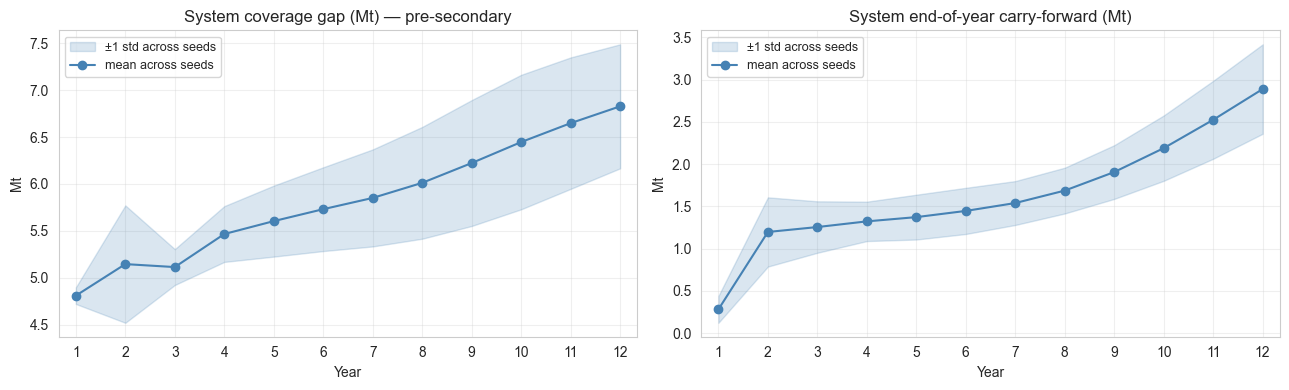

In [24]:
# RQ4.1 — Per-year coverage gap and end-of-year carry-forward (debt cascade).
# Cross-seed mean + ±1 std fan, computed from the year_log only — works on
# any v8.6.1+ run. Earlier logs silently produce empty figures.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _stack_year_metric(prefix, max_idx=N_TOTAL, agg="sum"):
    """Return wide DataFrame indexed by year with one column per run, where
    each value is the cross-agent (sum|mean) of `{prefix}_A{i}` for that
    year — averaged across episodes within the run."""
    out = {}
    for k, run in runs.items():
        yr = run["yr_df"]
        if "year" not in yr.columns:
            continue
        cols = [f"{prefix}_A{i+1}" for i in range(max_idx)
                if f"{prefix}_A{i+1}" in yr.columns]
        if not cols:
            continue
        # Per-year mean across episodes of the cross-agent agg.
        if agg == "sum":
            per_year = yr.groupby("year")[cols].mean().sum(axis=1)
        else:
            per_year = yr.groupby("year")[cols].mean().mean(axis=1)
        out[k] = per_year
    return pd.concat(out, axis=1).sort_index() if out else pd.DataFrame()

cov_gap_df  = _stack_year_metric("coverage_gap")             # system-sum (Mt)
cf_end_df   = _stack_year_metric("carry_forward_end")        # system-sum (Mt)
cf_start_df = _stack_year_metric("carry_forward_start")      # system-sum (Mt)

if cov_gap_df.empty and cf_end_df.empty:
    print("[RQ4.1] coverage_gap_A* / carry_forward_*_A* columns missing — pre-8.6.1 log.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, df, ttl in [
        (axes[0], cov_gap_df, "System coverage gap (Mt) — pre-secondary"),
        (axes[1], cf_end_df,  "System end-of-year carry-forward (Mt)"),
    ]:
        if df.empty:
            ax.set_title(ttl + "\n(missing)"); continue
        mean = df.mean(axis=1)
        std = df.std(axis=1).fillna(0.0)
        ax.fill_between(mean.index, (mean - std).values, (mean + std).values,
                        alpha=0.2, color="steelblue", label="±1 std across seeds")
        ax.plot(mean.index, mean.values, "o-", color="steelblue", label="mean across seeds")
        ax.set_xlabel("Year"); ax.set_ylabel("Mt"); ax.set_title(ttl)
        ax.grid(alpha=0.3); ax.legend(loc="best", fontsize=9)
    for ax in axes:
        format_year_axis(ax)
    plt.tight_layout(); plt.show()

### RQ4.2 — Auction concentration (HHI, max-agent share)

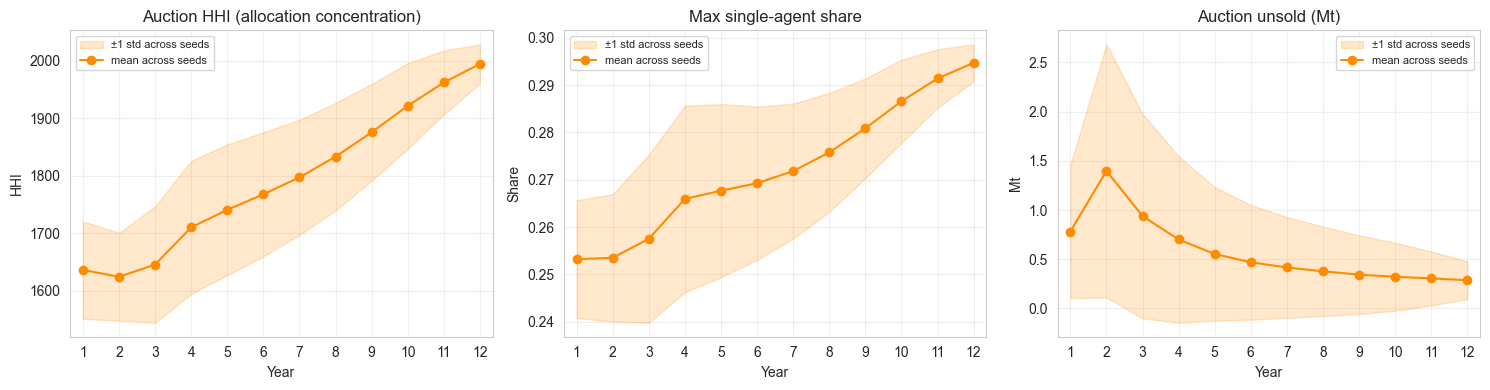

Total auction-failure (year, seed) cells across loaded runs: 0


In [25]:
# RQ4.2 — Auction concentration trajectory. Reads `auction_hhi` and
# `auction_max_agent_share` (year-level scalars added in v8.6.1).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _stack_year_scalar(col):
    out = {}
    for k, run in runs.items():
        yr = run["yr_df"]
        if "year" not in yr.columns or col not in yr.columns:
            continue
        out[k] = yr.groupby("year")[col].mean()
    return pd.concat(out, axis=1).sort_index() if out else pd.DataFrame()

hhi_df = _stack_year_scalar("auction_hhi")
mas_df = _stack_year_scalar("auction_max_agent_share")
fail_df = _stack_year_scalar("auction_failed")
unsold_df = _stack_year_scalar("auction_unsold")

if hhi_df.empty and mas_df.empty:
    print("[RQ4.2] auction_hhi / auction_max_agent_share missing — pre-8.6.1 log.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, df, ttl, ylabel in [
        (axes[0], hhi_df, "Auction HHI (allocation concentration)", "HHI"),
        (axes[1], mas_df, "Max single-agent share", "Share"),
        (axes[2], unsold_df, "Auction unsold (Mt)", "Mt"),
    ]:
        if df.empty:
            ax.set_title(ttl + "\n(missing)"); continue
        mean = df.mean(axis=1)
        std = df.std(axis=1).fillna(0.0)
        ax.fill_between(mean.index, (mean - std).values, (mean + std).values,
                        alpha=0.2, color="darkorange", label="±1 std across seeds")
        ax.plot(mean.index, mean.values, "o-", color="darkorange", label="mean across seeds")
        ax.set_xlabel("Year"); ax.set_ylabel(ylabel); ax.set_title(ttl)
        ax.grid(alpha=0.3); ax.legend(loc="best", fontsize=8)
    for ax in axes:
        format_year_axis(ax)
    plt.tight_layout(); plt.show()

    if not fail_df.empty:
        n_failures = int(np.nansum(fail_df.values))
        print(f"Total auction-failure (year, seed) cells across loaded runs: {n_failures}")

### RQ4.3 — Secondary-market liquidity (intent vs execution)

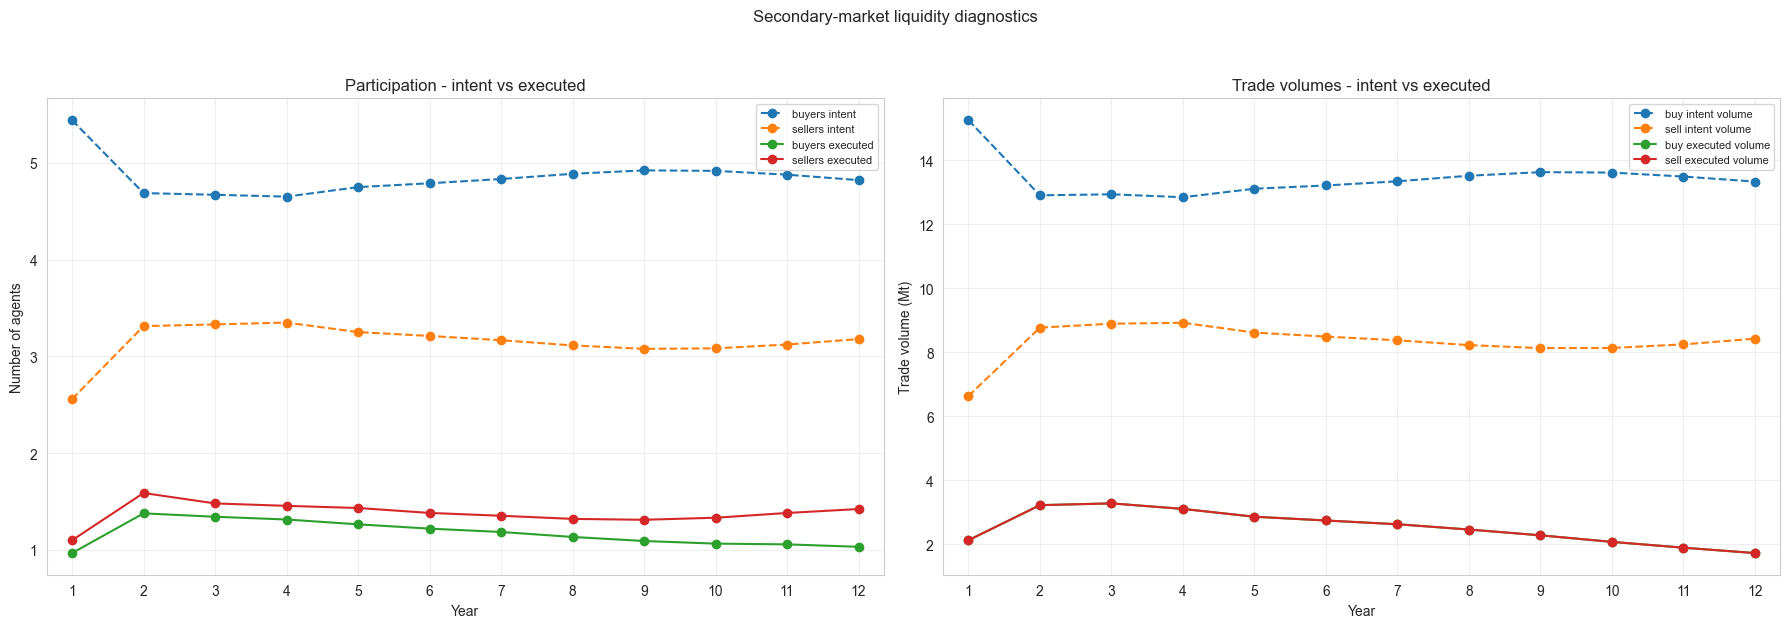

In [26]:
# RQ4.3 — Secondary-market liquidity: participation, volume, and match rate.
# The match-rate panel mirrors the trainer's definition: the share of cases
# where at least one secondary trade executed, aggregated by year.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EPS_TRADE = 1e-6


def _median_by_year(rows):
    if not rows:
        return pd.Series(dtype=float)
    return pd.concat(rows, axis=1).median(axis=1).sort_index()


def _stack_year_column(column):
    rows = []
    for run_key, run in runs.items():
        year_df = run.get("yr_df", pd.DataFrame())
        if year_df is None or "year" not in year_df.columns or column not in year_df.columns:
            continue
        values = pd.to_numeric(year_df[column], errors="coerce")
        rows.append(values.groupby(year_df["year"]).mean())
    return _median_by_year(rows)


count_columns = {
    "buyers_intent": "secondary_n_buyers_intent",
    "sellers_intent": "secondary_n_sellers_intent",
    "buyers_executed": "secondary_n_buyers_executed",
    "sellers_executed": "secondary_n_sellers_executed",
}
agent_count_series = {
    label: series
    for label, column in count_columns.items()
    if not (series := _stack_year_column(column)).empty
}

volume_rows = {
    "buy_intent_volume": [],
    "sell_intent_volume": [],
    "buy_executed_volume": [],
    "sell_executed_volume": [],
}
trade_active_rows = []

for run_key, run in runs.items():
    year_df = run.get("yr_df", pd.DataFrame())
    if year_df is None or "year" not in year_df.columns:
        continue

    intent_columns = year_df.filter(regex=r"^sec_qty_action_A\d+$").columns
    trade_columns = year_df.filter(regex=r"^trade_qty_A\d+$").columns
    derived = {"year": year_df["year"]}

    if len(intent_columns):
        intent = year_df[intent_columns].apply(pd.to_numeric, errors="coerce").fillna(0.0)
        derived["buy_intent_volume"] = intent.clip(lower=0.0).sum(axis=1)
        derived["sell_intent_volume"] = (-intent.clip(upper=0.0)).sum(axis=1)

    if len(trade_columns):
        traded = year_df[trade_columns].apply(pd.to_numeric, errors="coerce").fillna(0.0)
        derived["buy_executed_volume"] = traded.clip(lower=0.0).sum(axis=1)
        derived["sell_executed_volume"] = (-traded.clip(upper=0.0)).sum(axis=1)
        trade_active_rows.append((traded.abs().sum(axis=1) > EPS_TRADE).groupby(year_df["year"]).mean())
    elif {"secondary_n_buyers_executed", "secondary_n_sellers_executed"}.issubset(year_df.columns):
        buyers_executed = pd.to_numeric(year_df["secondary_n_buyers_executed"], errors="coerce").fillna(0.0)
        sellers_executed = pd.to_numeric(year_df["secondary_n_sellers_executed"], errors="coerce").fillna(0.0)
        trade_active_rows.append(((buyers_executed + sellers_executed) > 0.0).groupby(year_df["year"]).mean())

    derived_df = pd.DataFrame(derived)
    for label in volume_rows:
        if label in derived_df.columns:
            volume_rows[label].append(derived_df.groupby("year")[label].mean())

volume_series = {
    label: _median_by_year(rows)
    for label, rows in volume_rows.items()
    if rows
}
trade_active_rate = _median_by_year(trade_active_rows) * 100.0

if not agent_count_series and not volume_series and trade_active_rate.empty:
    print("[RQ4.3] secondary-market intent/executed columns missing — cannot plot liquidity diagnostics.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    ax = axes[0]
    if agent_count_series:
        for label, series in agent_count_series.items():
            line_style = "-" if "executed" in label else "--"
            ax.plot(series.index, series.values, line_style + "o", label=label.replace("_", " "))
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, "missing count columns", ha="center", va="center", transform=ax.transAxes)
    ax.set_xlabel("Year"); ax.set_ylabel("Number of agents")
    ax.set_title("Participation - intent vs executed")
    ax.grid(alpha=0.3)

    ax = axes[1]
    if volume_series:
        for label, series in volume_series.items():
            line_style = "-" if "executed" in label else "--"
            ax.plot(series.index, series.values, line_style + "o", label=label.replace("_", " "))
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, "missing volume columns", ha="center", va="center", transform=ax.transAxes)
    ax.set_xlabel("Year"); ax.set_ylabel("Trade volume (Mt)")
    ax.set_title("Trade volumes - intent vs executed")
    ax.grid(alpha=0.3)

    for ax in axes:
        format_year_axis(ax)

    fig.suptitle("Secondary-market liquidity diagnostics", y=1.04)
    plt.tight_layout(); plt.show()

RQ4.3b secondary-market order-book diagnosis
Sample: 48,000 (run, episode, year) rows across 4 runs
Metric definitions:


,Metric,Unit,Definition
0,Real fill rate,%,Executed buy+sell quantity divided by submitted buy+sell quantity.
1,Feasible-overlap fill rate,%,"Executed one-sided volume divided by min(buy intent, feasible sell volume)."
2,Buy intent volume,Mt,Total positive sec_qty_action submitted by buyers.
3,Raw sell intent volume,Mt,Total absolute negative sec_qty_action submitted by sellers before clipping.
4,Feasible sell volume,Mt,Sell intent remaining after no-short/compliance feasibility clipping.
5,Executed volume,Mt,One-sided matched volume; buyer and seller legs should be equal apart from rounding.
6,Clipped sell intent,Mt,Submitted sell volume removed by feasibility constraints.
7,Unfilled feasible overlap,Mt,"min(buy intent, feasible sell) minus executed volume."
8,Buy demand above feasible sell supply,Mt,Buy intent exceeding feasible sell quantity.
9,Best-price crossing rate,%,Share of rows where highest buyer limit reaches lowest feasible ask after tolerance.


Summary statistics across the converged-window (run, episode, year) sample:


,Metric,Unit,Mean,Median,Std
0,Real fill rate,%,25.50,25.00,17.08
1,Feasible-overlap fill rate,%,40.06,38.10,26.82
2,Buy intent volume,Mt,13.36,12.30,2.69
3,Raw sell intent volume,Mt,9.76,9.00,2.69
4,Feasible sell volume,Mt,7.68,7.75,2.55
5,Executed volume,Mt,2.95,3.00,1.97
6,Clipped sell intent,Mt,2.08,1.51,2.17
7,Unfilled feasible overlap,Mt,4.54,4.67,2.31
8,Buy demand above feasible sell supply,Mt,5.87,6.00,4.32
9,Best-price crossing rate,%,84.76,100.00,35.94


Bottleneck label definitions:


,Primary bottleneck,Meaning
0,best prices do not cross,Even the highest bid is below the lowest feasible ask after tolerance.
1,only marginal prices cross,"At least one buyer and seller can trade, but most submitted volume sits outside the crossed part of the order book."
2,sell intent infeasible,"Agents wanted to sell allowances they could not legally sell after compliance, banking, and no-short constraints."
3,no buy intent / no sell intent,"One side of the market is absent, so no bilateral match is possible."
4,side-limited/mostly filled,The remaining shortfall is mainly because one side has less feasible volume than the other.


Bottleneck summary:


,Primary bottleneck,Rows,Share_pct,Real_fill_mean_pct,Real_fill_median_pct,Real_fill_std_pct,Executed_median_Mt,Unfilled_feasible_overlap_median_Mt,Gap_after_tolerance_median_EURt
0,only marginal prices cross,38762,80.75,29.57,25.00,13.82,3.00,4.48,-151.61
1,best prices do not cross,7253,15.11,0.00,0.00,0.00,0.00,6.02,142.59
2,side-limited/mostly filled,1922,4.00,40.57,36.80,19.91,4.23,0.00,-161.30
3,sell intent infeasible,49,0.10,0.00,0.00,0.00,0.00,0.00,nan
4,no sell intent,14,0.03,0.00,0.00,0.00,0.00,0.00,nan


By-year medians, with mean/std shown for the real fill rate:


,Year,Buy_intent_median_Mt,Raw_sell_intent_median_Mt,Feasible_sell_median_Mt,Executed_median_Mt,Real_fill_mean_pct,Real_fill_median_pct,Real_fill_std_pct,Buyer_limit_median_EURt,Feasible_seller_ask_median_EURt,Best_buy_median_EURt,Best_feasible_ask_median_EURt,Gap_after_tolerance_median_EURt,Unfilled_feasible_overlap_median_Mt,Clipped_sell_median_Mt
0,1,15.00,6.01,5.63,3.00,18.29,25.00,17.14,68.98,212.05,159.73,52.01,-5.40,3.23,1.08
1,2,12.00,9.00,9.00,3.00,33.18,27.39,21.12,91.96,184.17,221.77,45.00,-146.88,5.02,0.89
2,3,12.00,9.36,9.00,3.00,30.32,25.00,15.97,96.27,202.70,248.14,45.00,-176.74,5.69,0.63
3,4,12.00,10.32,9.00,3.00,28.60,25.00,16.73,94.57,209.04,231.23,45.00,-145.68,5.92,0.74
4,5,12.00,10.36,9.00,3.00,28.66,25.00,17.11,94.93,212.01,232.79,45.00,-126.55,5.98,0.77
5,6,12.00,9.89,9.00,3.00,27.40,25.00,16.81,93.32,216.57,225.95,45.00,-118.35,5.60,1.05
6,7,12.00,9.39,8.56,3.00,27.12,25.00,16.70,91.54,216.68,220.85,45.00,-114.47,5.14,1.35
7,8,12.00,9.13,8.00,3.00,26.22,25.00,16.41,88.93,218.03,208.45,45.00,-96.04,4.73,1.69
8,9,12.27,9.00,7.30,3.00,24.63,25.00,15.73,87.26,223.33,205.25,45.00,-84.58,4.32,2.10
9,10,12.77,9.00,6.59,3.00,22.30,25.00,15.33,83.96,229.73,191.55,45.00,-68.04,3.85,2.61


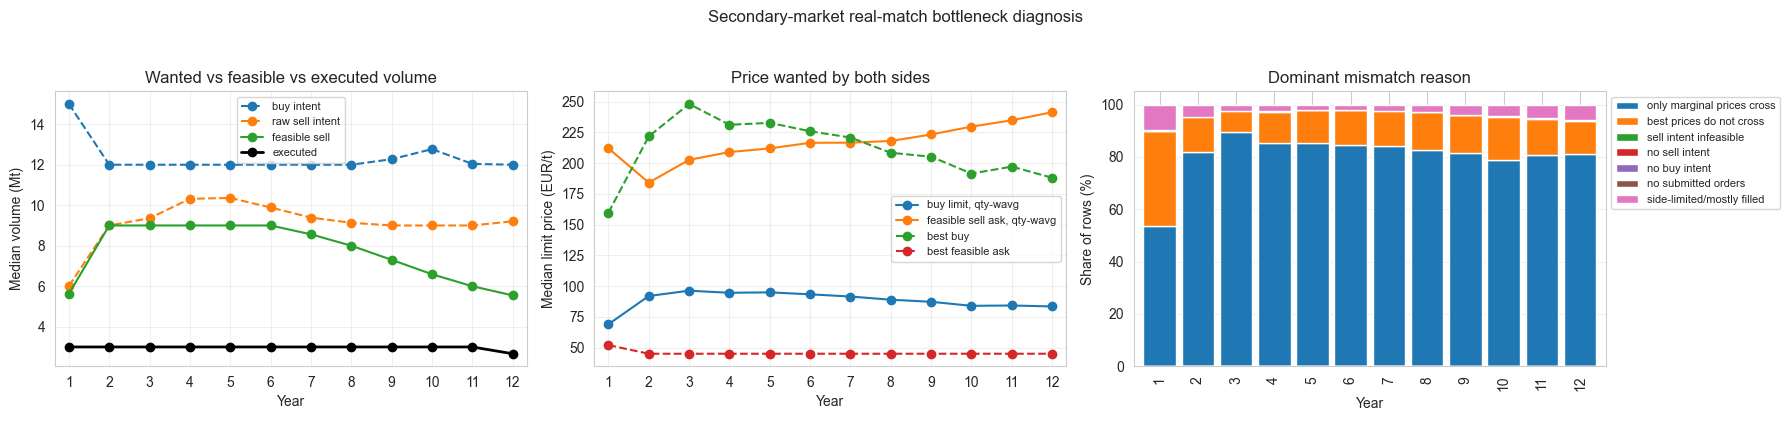

In [27]:
# RQ4.3b - Why is the real secondary-market fill rate low?
# Uses columns loaded by the main loader; no per-cell reloading.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EPS_TRADE = 1e-6


def _row_weighted_mean(value_df, weight_df):
    weights = weight_df.where(weight_df > EPS_TRADE, 0.0)
    weight_sum = weights.sum(axis=1)
    weighted_sum = value_df.where(weights > 0.0).mul(weights).sum(axis=1, min_count=1)
    return weighted_sum.div(weight_sum.where(weight_sum > EPS_TRADE))


def _summary_row(frame, metric, label, unit):
    values = pd.to_numeric(frame[metric], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    return {
        "Metric": label,
        "Unit": unit,
        "Mean": values.mean(),
        "Median": values.median(),
        "Std": values.std(),
    }


def _display_table(frame, numeric_columns=None, max_colwidth=180):
    numeric_columns = numeric_columns or []
    formatters = {col: "{:.2f}" for col in numeric_columns if col in frame.columns}
    if "Year" in frame.columns:
        formatters["Year"] = "{:.0f}"
    with pd.option_context("display.max_colwidth", max_colwidth):
        display(frame.style.format(formatters))


orderbook_parts = []
missing_price_runs = []
for run_key, run in runs.items():
    year_tail = tail_year_rows(run).copy()
    if year_tail.empty or "year" not in year_tail.columns:
        continue

    qty_cols = agent_cols(year_tail, "sec_qty_action")
    price_cols = agent_cols(year_tail, "sec_price_mult")
    trade_cols = agent_cols(year_tail, "trade_qty")
    if not qty_cols or not trade_cols:
        continue
    if not price_cols:
        missing_price_runs.append(run_key)
        continue

    n_cols = min(len(qty_cols), len(price_cols), len(trade_cols))
    qty = year_tail[qty_cols[:n_cols]].apply(pd.to_numeric, errors="coerce").fillna(0.0)
    price = year_tail[price_cols[:n_cols]].apply(pd.to_numeric, errors="coerce")
    trade = year_tail[trade_cols[:n_cols]].apply(pd.to_numeric, errors="coerce").fillna(0.0)
    qty.columns = price.columns = trade.columns = range(n_cols)

    buy_qty = qty.clip(lower=0.0)
    raw_sell_qty = (-qty.clip(upper=0.0)).clip(lower=0.0)

    alloc_cols = agent_cols(year_tail, "alloc")[:n_cols]
    bank_cols = agent_cols(year_tail, "bank_start")[:n_cols]
    emissions_cols = agent_cols(year_tail, "emissions")[:n_cols]
    carry_cols = agent_cols(year_tail, "carry_forward_start")[:n_cols]
    can_clip_sells = len(alloc_cols) == len(bank_cols) == len(emissions_cols) == n_cols

    if can_clip_sells:
        alloc = year_tail[alloc_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
        bank = year_tail[bank_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).clip(lower=0.0)
        emissions = year_tail[emissions_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
        alloc.columns = bank.columns = emissions.columns = range(n_cols)
        if len(carry_cols) == n_cols:
            carry = year_tail[carry_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
            carry.columns = range(n_cols)
        else:
            carry = pd.DataFrame(0.0, index=year_tail.index, columns=range(n_cols))
        max_sell = (alloc + bank - emissions - carry).clip(lower=0.0)
        feasible_sell_qty = pd.DataFrame(
            np.minimum(raw_sell_qty.to_numpy(), max_sell.to_numpy()),
            index=year_tail.index,
            columns=range(n_cols),
        )
    else:
        feasible_sell_qty = raw_sell_qty.copy()

    buy_intent = buy_qty.sum(axis=1)
    raw_sell_intent = raw_sell_qty.sum(axis=1)
    feasible_sell = feasible_sell_qty.sum(axis=1)
    executed_buy = trade.clip(lower=0.0).sum(axis=1)
    executed_sell = (-trade.clip(upper=0.0)).sum(axis=1)
    executed_once = pd.concat([executed_buy, executed_sell], axis=1).max(axis=1)
    feasible_overlap = pd.concat([buy_intent, feasible_sell], axis=1).min(axis=1)

    spread_fraction = float((run.get("config") or {}).get("trading", {}).get("spread_tolerance", 0.0))
    clearing = pd.to_numeric(year_tail.get("clearing_price", 0.0), errors="coerce").fillna(0.0)
    spread_tolerance = spread_fraction * clearing.clip(lower=1.0)

    buyer_limit = _row_weighted_mean(price.where(buy_qty > EPS_TRADE), buy_qty)
    raw_seller_ask = _row_weighted_mean(price.where(raw_sell_qty > EPS_TRADE), raw_sell_qty)
    feasible_seller_ask = _row_weighted_mean(price.where(feasible_sell_qty > EPS_TRADE), feasible_sell_qty)
    best_buy = price.where(buy_qty > EPS_TRADE).max(axis=1)
    best_ask = price.where(feasible_sell_qty > EPS_TRADE).min(axis=1)
    gap_after_tolerance = best_ask - best_buy - spread_tolerance

    orderbook = pd.DataFrame({
        "run": str(run_key),
        "year": year_tail["year"].to_numpy(),
        "buy_intent_Mt": buy_intent,
        "raw_sell_intent_Mt": raw_sell_intent,
        "feasible_sell_Mt": feasible_sell,
        "executed_Mt": executed_once,
        "clipped_sell_Mt": (raw_sell_intent - feasible_sell).clip(lower=0.0),
        "feasible_overlap_Mt": feasible_overlap,
        "unfilled_feasible_overlap_Mt": (feasible_overlap - executed_once).clip(lower=0.0),
        "buy_demand_above_feasible_sell_Mt": (buy_intent - feasible_sell).clip(lower=0.0),
        "buyer_limit_wavg_EURt": buyer_limit,
        "raw_seller_ask_wavg_EURt": raw_seller_ask,
        "feasible_seller_ask_wavg_EURt": feasible_seller_ask,
        "best_buy_EURt": best_buy,
        "best_feasible_ask_EURt": best_ask,
        "gap_after_tolerance_EURt": gap_after_tolerance,
        "best_prices_cross_pct": (gap_after_tolerance <= 0.0).astype(float) * 100.0,
        "real_fill_pct": 100.0 * (executed_buy + executed_sell).div((buy_intent + raw_sell_intent).clip(lower=EPS_TRADE)),
        "feasible_overlap_fill_pct": 100.0 * executed_once.div(feasible_overlap.clip(lower=EPS_TRADE)),
    })

    conditions = [
        (orderbook["buy_intent_Mt"] <= EPS_TRADE) & (orderbook["raw_sell_intent_Mt"] <= EPS_TRADE),
        orderbook["buy_intent_Mt"] <= EPS_TRADE,
        orderbook["raw_sell_intent_Mt"] <= EPS_TRADE,
        orderbook["feasible_sell_Mt"] <= EPS_TRADE,
        orderbook["gap_after_tolerance_EURt"] > 0.0,
        orderbook["unfilled_feasible_overlap_Mt"] > EPS_TRADE,
    ]
    labels = [
        "no submitted orders",
        "no buy intent",
        "no sell intent",
        "sell intent infeasible",
        "best prices do not cross",
        "only marginal prices cross",
    ]
    orderbook["primary_bottleneck"] = np.select(conditions, labels, default="side-limited/mostly filled")
    orderbook_parts.append(orderbook)

orderbook_df = pd.concat(orderbook_parts, ignore_index=True) if orderbook_parts else pd.DataFrame()

if orderbook_df.empty:
    if missing_price_runs:
        print("[RQ4.3b] Secondary price columns are not loaded. Run the main loader cell, then rerun this cell.")
    else:
        print("[RQ4.3b] Missing secondary order columns; cannot diagnose real match rate.")
else:
    if missing_price_runs:
        print(f"[RQ4.3b] Skipped {len(missing_price_runs)} runs without loaded sec_price_mult_A* columns.")
    print("RQ4.3b secondary-market order-book diagnosis")
    print(f"Sample: {len(orderbook_df):,} (run, episode, year) rows across {orderbook_df['run'].nunique()} runs")

    metric_specs = [
        ("real_fill_pct", "Real fill rate", "%", "Executed buy+sell quantity divided by submitted buy+sell quantity."),
        ("feasible_overlap_fill_pct", "Feasible-overlap fill rate", "%", "Executed one-sided volume divided by min(buy intent, feasible sell volume)."),
        ("buy_intent_Mt", "Buy intent volume", "Mt", "Total positive sec_qty_action submitted by buyers."),
        ("raw_sell_intent_Mt", "Raw sell intent volume", "Mt", "Total absolute negative sec_qty_action submitted by sellers before clipping."),
        ("feasible_sell_Mt", "Feasible sell volume", "Mt", "Sell intent remaining after no-short/compliance feasibility clipping."),
        ("executed_Mt", "Executed volume", "Mt", "One-sided matched volume; buyer and seller legs should be equal apart from rounding."),
        ("clipped_sell_Mt", "Clipped sell intent", "Mt", "Submitted sell volume removed by feasibility constraints."),
        ("unfilled_feasible_overlap_Mt", "Unfilled feasible overlap", "Mt", "min(buy intent, feasible sell) minus executed volume."),
        ("buy_demand_above_feasible_sell_Mt", "Buy demand above feasible sell supply", "Mt", "Buy intent exceeding feasible sell quantity."),
        ("best_prices_cross_pct", "Best-price crossing rate", "%", "Share of rows where highest buyer limit reaches lowest feasible ask after tolerance."),
        ("buyer_limit_wavg_EURt", "Weighted buy limit price", "EUR/t", "Quantity-weighted average limit price submitted by buyers."),
        ("feasible_seller_ask_wavg_EURt", "Weighted feasible seller ask", "EUR/t", "Quantity-weighted average ask among sellers with feasible volume."),
        ("best_buy_EURt", "Best buy price", "EUR/t", "Highest buyer limit price in the row."),
        ("best_feasible_ask_EURt", "Best feasible ask", "EUR/t", "Lowest ask among sellers with feasible volume."),
        ("gap_after_tolerance_EURt", "Best gap after tolerance", "EUR/t", "Lowest feasible ask minus highest bid minus spread tolerance; positive means no crossing."),
    ]
    metric_definitions = pd.DataFrame([
        {"Metric": label, "Unit": unit, "Definition": definition}
        for _, label, unit, definition in metric_specs
    ])
    summary_stats = pd.DataFrame([
        _summary_row(orderbook_df, metric, label, unit)
        for metric, label, unit, _ in metric_specs
    ])

    print("Metric definitions:")
    _display_table(metric_definitions)

    print("Summary statistics across the converged-window (run, episode, year) sample:")
    _display_table(summary_stats, numeric_columns=["Mean", "Median", "Std"])

    bottleneck_meanings = pd.DataFrame({
        "Primary bottleneck": [
            "best prices do not cross",
            "only marginal prices cross",
            "sell intent infeasible",
            "no buy intent / no sell intent",
            "side-limited/mostly filled",
        ],
        "Meaning": [
            "Even the highest bid is below the lowest feasible ask after tolerance.",
            "At least one buyer and seller can trade, but most submitted volume sits outside the crossed part of the order book.",
            "Agents wanted to sell allowances they could not legally sell after compliance, banking, and no-short constraints.",
            "One side of the market is absent, so no bilateral match is possible.",
            "The remaining shortfall is mainly because one side has less feasible volume than the other.",
        ],
    })
    print("Bottleneck label definitions:")
    _display_table(bottleneck_meanings)

    bottleneck_summary = (
        orderbook_df.groupby("primary_bottleneck")
        .agg(
            Rows=("primary_bottleneck", "size"),
            Share_pct=("primary_bottleneck", lambda s: 100.0 * len(s) / len(orderbook_df)),
            Real_fill_mean_pct=("real_fill_pct", "mean"),
            Real_fill_median_pct=("real_fill_pct", "median"),
            Real_fill_std_pct=("real_fill_pct", "std"),
            Executed_median_Mt=("executed_Mt", "median"),
            Unfilled_feasible_overlap_median_Mt=("unfilled_feasible_overlap_Mt", "median"),
            Gap_after_tolerance_median_EURt=("gap_after_tolerance_EURt", "median"),
        )
        .sort_values("Share_pct", ascending=False)
        .reset_index()
        .rename(columns={"primary_bottleneck": "Primary bottleneck"})
    )
    print("Bottleneck summary:")
    _display_table(
        bottleneck_summary,
        numeric_columns=[
            "Share_pct", "Real_fill_mean_pct", "Real_fill_median_pct", "Real_fill_std_pct",
            "Executed_median_Mt", "Unfilled_feasible_overlap_median_Mt", "Gap_after_tolerance_median_EURt",
        ],
    )

    by_year = (
        orderbook_df.groupby("year")
        .agg(
            Buy_intent_median_Mt=("buy_intent_Mt", "median"),
            Raw_sell_intent_median_Mt=("raw_sell_intent_Mt", "median"),
            Feasible_sell_median_Mt=("feasible_sell_Mt", "median"),
            Executed_median_Mt=("executed_Mt", "median"),
            Real_fill_mean_pct=("real_fill_pct", "mean"),
            Real_fill_median_pct=("real_fill_pct", "median"),
            Real_fill_std_pct=("real_fill_pct", "std"),
            Buyer_limit_median_EURt=("buyer_limit_wavg_EURt", "median"),
            Feasible_seller_ask_median_EURt=("feasible_seller_ask_wavg_EURt", "median"),
            Best_buy_median_EURt=("best_buy_EURt", "median"),
            Best_feasible_ask_median_EURt=("best_feasible_ask_EURt", "median"),
            Gap_after_tolerance_median_EURt=("gap_after_tolerance_EURt", "median"),
            Unfilled_feasible_overlap_median_Mt=("unfilled_feasible_overlap_Mt", "median"),
            Clipped_sell_median_Mt=("clipped_sell_Mt", "median"),
        )
        .reset_index()
        .rename(columns={"year": "Year"})
    )
    print("By-year medians, with mean/std shown for the real fill rate:")
    _display_table(by_year, numeric_columns=[col for col in by_year.columns if col != "Year"])

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    ax = axes[0]
    ax.plot(by_year["Year"], by_year["Buy_intent_median_Mt"], "o--", label="buy intent")
    ax.plot(by_year["Year"], by_year["Raw_sell_intent_median_Mt"], "o--", label="raw sell intent")
    ax.plot(by_year["Year"], by_year["Feasible_sell_median_Mt"], "o-", label="feasible sell")
    ax.plot(by_year["Year"], by_year["Executed_median_Mt"], "o-", color="black", linewidth=2.0, label="executed")
    ax.set_xlabel("Year"); ax.set_ylabel("Median volume (Mt)")
    ax.set_title("Wanted vs feasible vs executed volume")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
    format_year_axis(ax)

    ax = axes[1]
    ax.plot(by_year["Year"], by_year["Buyer_limit_median_EURt"], "o-", label="buy limit, qty-wavg")
    ax.plot(by_year["Year"], by_year["Feasible_seller_ask_median_EURt"], "o-", label="feasible sell ask, qty-wavg")
    ax.plot(by_year["Year"], by_year["Best_buy_median_EURt"], "o--", label="best buy")
    ax.plot(by_year["Year"], by_year["Best_feasible_ask_median_EURt"], "o--", label="best feasible ask")
    ax.set_xlabel("Year"); ax.set_ylabel("Median limit price (EUR/t)")
    ax.set_title("Price wanted by both sides")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
    format_year_axis(ax)

    ax = axes[2]
    bottleneck_order = [
        "only marginal prices cross",
        "best prices do not cross",
        "sell intent infeasible",
        "no sell intent",
        "no buy intent",
        "no submitted orders",
        "side-limited/mostly filled",
    ]
    bottleneck_share = (
        pd.crosstab(orderbook_df["year"], orderbook_df["primary_bottleneck"], normalize="index")
        .mul(100.0)
        .reindex(columns=bottleneck_order, fill_value=0.0)
    )
    bottleneck_share.plot(kind="bar", stacked=True, ax=ax, width=0.85)
    ax.set_xlabel("Year"); ax.set_ylabel("Share of rows (%)")
    ax.set_title("Dominant mismatch reason")
    ax.grid(axis="y", alpha=0.3); ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.0, 1.0))

    fig.suptitle("Secondary-market real-match bottleneck diagnosis", y=1.04)
    plt.tight_layout(); plt.show()

### RQ4.4 — Converged-window credit stress by archetype × weighting

In [28]:
# RQ4.4 — Per-(archetype, weighting) cell of the mean peak emergency-loan
# balance and peak carry-forward debt in the converged window. Sourced from
# the per-episode `peak_loan_outstanding_A{i}` / `peak_carry_forward_A{i}`
# (v8.6.1+); pre-8.6.1 logs lack these columns and produce an empty table.
import numpy as np
import pandas as pd

def _converged_credit_metrics():
    rows = []
    for k, run in runs.items():
        ep_tail = tail_episodes(run["ep_df"])
        cfg = run["config"]
        for i in range(N_AGENTS):
            arche = ARCHETYPES[i // 2] if i // 2 < len(ARCHETYPES) else f"A{i+1}"
            w_cost, w_green = (cfg.get("companies", {}).get("reward_weights") or [[1, 0]] * N_AGENTS)[i]
            weighting = "Financial" if w_green < 0.25 else ("ESG" if w_green > 0.75 else "Balanced")
            row = {"sweep": k[0], "variant": k[1], "seed": k[2],
                   "archetype": arche, "weighting": weighting, "agent": i + 1}
            for stub in ["peak_loan_outstanding", "peak_carry_forward",
                         "final_treasury_reserve"]:
                col = f"{stub}_A{i+1}"
                row[stub] = float(ep_tail[col].mean()) if col in ep_tail.columns else np.nan
            rows.append(row)
    return pd.DataFrame(rows)

credit_df = _converged_credit_metrics()
if credit_df.empty or credit_df[["peak_loan_outstanding", "peak_carry_forward"]].isna().all().all():
    print("[RQ4.4] peak_loan_outstanding_A* / peak_carry_forward_A* missing — pre-8.6.1 log.")
else:
    pivot_loan = credit_df.pivot_table(
        index="archetype", columns="weighting", values="peak_loan_outstanding", aggfunc="mean"
    ).round(3)
    pivot_cf = credit_df.pivot_table(
        index="archetype", columns="weighting", values="peak_carry_forward", aggfunc="mean"
    ).round(3)
    print("Mean peak emergency-loan balance (M€) — converged window:")
    display(pivot_loan)
    print("\nMean peak end-of-year carry-forward (Mt) — converged window:")
    display(pivot_cf)


Mean peak emergency-loan balance (M€) — converged window:


weighting,Balanced,Financial
archetype,,
Coal-heavy,0.0,0.0
Gas-dominant,0.0,0.0
Green-leader,0.0,0.0
Transitioner,0.0,0.0



Mean peak end-of-year carry-forward (Mt) — converged window:


weighting,Balanced,Financial
archetype,,
Coal-heavy,0.778,2.038
Gas-dominant,0.554,1.366
Green-leader,0.068,0.166
Transitioner,0.490,0.273


### RQ4.5 — Why agents go incompliant: per-cell root-cause attribution

The UDBC mix in §RQ3.4 / §RQ2.3 already tells us *how often* each combinatorial
state (under-bid / debt / mixed / bank-covered / secondary-covered) occurs.
What it does not isolate is the **proximate cause** of each non-compliant cell:
did the agent bid too cheaply and lose the auction, did it ask for too few
tonnes (`bid_qty_mult` × `estimate_need` short of realised `need`), did the
auction itself clear oversubscribed, was it carrying inherited debt forward,
or did it submit a buy intent on the secondary that nobody filled?

This panel pulls every non-compliant cell `(episode, year, agent)` from the
converged-tail window only and runs each through a prioritised waterfall:

1. **Inherited debt** — `alloc ≥ emiss` AND `cf_start ≥ shortfall`. The agent
   was auction-compliant *this year*; the deficit is fully explained by debt
   carried forward from earlier years.
2. **Underbid (price)** — `bid_price < 99.5 % × clearing_price`. The agent
   was priced out of the marginal allocation tranche.
3. **Undersized bid (quantity)** — `(bid_qty_mult × estimate_need)` falls
   short of the realised need by more than half of the shortfall. The agent
   asked for too few tonnes regardless of price.
4. **Oversubscribed auction** — `auction_total_demand / auction_volume > 1.05`.
   Even bidding at clearing, the agent was rationed by total demand exceeding
   supply.
5. **Secondary illiquidity** — agent submitted a positive buy intent
   (`sec_qty_action > 0`) but the realised buy fell more than 25 % of the
   shortfall short of intent.
6. **Mixed / cascade** — fallback bucket; no single cause dominates.

The taxonomy is intentionally simple and prioritised — each cell is assigned
exactly one dominant cause. The downstream tables report both mean and median
diagnostic-feature values per cause and in the compliant/non-compliant contrast,
so the central tendency and outlier sensitivity are visible together.

[RQ4.5] Denominator: 4 loaded run(s) × 1000 tail episodes × 8 agents × 12 years = 384,000 expected cells (96,000 per run); actual counted cells = 384,000.
[RQ4.5] Final non-compliant cells: 66,112 (17.2%); auction-stressed but compliant cells: 142,175 (37.0%).
[RQ4.5] Non-compliant (agent, year, episode) cells in converged window: 66,112
[RQ4.5] Σ shortfall across the window: 79,149.41 Mt


,n_cells,sum_shortfall_Mt,mean_shortfall_Mt,median_shortfall_Mt,cell_share_pct,tonne_share_pct
cause,,,,,,
Inherited debt,7070,10841.089,1.533,1.686,10.694,13.697
Underbid (price),3825,5321.238,1.391,0.740,5.786,6.723
Undersized bid (qty),49874,57323.488,1.149,1.099,75.439,72.424
Oversubscribed auction,5333,5659.925,1.061,0.718,8.067,7.151
Secondary illiquidity,4,2.079,0.520,0.547,0.006,0.003
Mixed / cascade,6,1.589,0.265,0.231,0.009,0.002


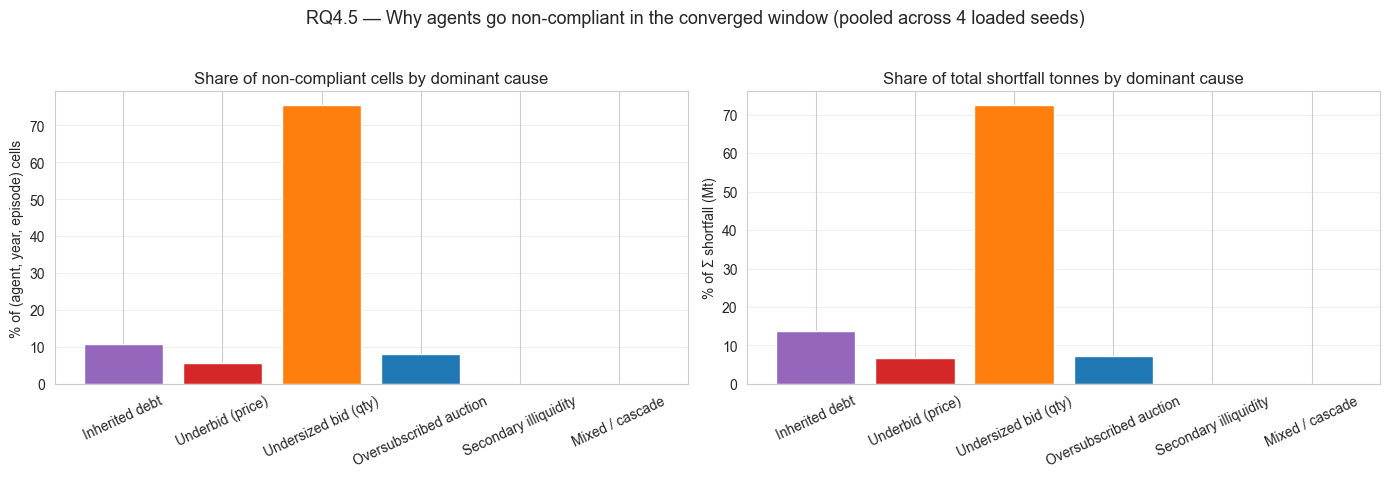

[RQ4.5] Baseline and per-cause feature values (mean / median / std):
        All tail cells = normal/default-config bid baseline; Fully compliant cells = regular successful bid baseline.


,n_cells,shortfall_Mt_mean,shortfall_Mt_median,shortfall_Mt_std,inherited_debt_Mt_mean,inherited_debt_Mt_median,inherited_debt_Mt_std,alloc_Mt_mean,alloc_Mt_median,alloc_Mt_std,emissions_Mt_mean,emissions_Mt_median,emissions_Mt_std,bid_price_mean,bid_price_median,bid_price_std,clearing_price_mean,clearing_price_median,clearing_price_std,bid_to_clearing_mean,bid_to_clearing_median,bid_to_clearing_std,bid_qty_mult_mean,bid_qty_mult_median,bid_qty_mult_std,bid_coverage_ratio_mean,bid_coverage_ratio_median,bid_coverage_ratio_std,estimate_need_Mt_mean,estimate_need_Mt_median,estimate_need_Mt_std,need_realised_Mt_mean,need_realised_Mt_median,need_realised_Mt_std,undersized_qty_Mt_mean,undersized_qty_Mt_median,undersized_qty_Mt_std,oversubscription_ratio_mean,oversubscription_ratio_median,oversubscription_ratio_std,bank_start_Mt_mean,bank_start_Mt_median,bank_start_Mt_std,sec_buy_intent_Mt_mean,sec_buy_intent_Mt_median,sec_buy_intent_Mt_std,secondary_buy_unmet_Mt_mean,secondary_buy_unmet_Mt_median,secondary_buy_unmet_Mt_std,loan_outstanding_Meur_mean,loan_outstanding_Meur_median,loan_outstanding_Meur_std
diagnostic_group,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
All tail cells (normal/default),384000,0.206,0.000,0.593,0.177,0.000,0.543,1.739,1.563,1.217,1.765,1.675,0.868,96.857,91.032,46.931,54.383,45.000,20.575,1.874,1.671,0.934,1.298,1.433,0.681,1.346,1.403,0.771,1.971,1.742,1.139,1.942,1.726,1.129,0.509,0.000,0.745,1.275,1.247,0.332,2.017,1.595,1.991,1.669,3.000,1.474,1.301,0.0,1.449,0.0,0.0,0.0
Fully compliant cells,317888,0.000,0.000,0.000,0.060,0.000,0.295,1.797,1.582,1.282,1.647,1.525,0.835,91.997,84.665,44.816,53.839,45.000,19.689,1.789,1.545,0.891,1.418,1.814,0.652,1.476,1.657,0.752,1.737,1.549,0.943,1.708,1.540,0.936,0.338,0.000,0.599,1.260,1.234,0.314,2.372,1.956,2.000,1.444,0.071,1.482,1.021,0.0,1.384,0.0,0.0,0.0
Inherited debt,7070,1.533,1.686,0.805,1.951,2.010,0.809,2.250,2.260,0.702,1.938,1.986,0.584,148.542,165.621,44.188,69.600,61.282,28.262,2.329,2.226,0.906,0.676,0.500,0.424,0.713,0.553,0.416,4.179,4.365,1.375,3.889,4.000,1.276,1.539,1.733,0.853,1.543,1.538,0.346,0.000,0.000,0.000,2.768,3.000,0.786,2.663,3.0,0.864,0.0,0.0,0.0
Underbid (price),3825,1.391,0.740,1.735,0.681,0.000,1.429,0.000,0.000,0.000,1.519,1.535,0.584,61.477,45.000,26.881,98.740,94.685,33.604,0.647,0.639,0.201,1.731,2.000,0.465,1.781,1.935,0.554,2.247,1.835,1.557,2.200,1.818,1.526,0.081,0.000,0.323,1.938,1.746,0.646,0.624,0.317,0.713,2.407,3.000,1.176,2.223,3.0,1.276,0.0,0.0,0.0
Undersized bid (qty),49874,1.149,1.099,0.800,0.611,0.078,0.797,1.556,1.541,0.586,2.498,2.596,0.781,128.014,135.097,44.419,52.539,45.000,18.948,2.537,2.535,0.911,0.522,0.500,0.109,0.517,0.501,0.081,3.100,3.085,1.182,3.109,3.089,1.194,1.540,1.543,0.658,1.258,1.234,0.329,0.303,0.000,0.498,2.815,3.000,0.706,2.714,3.0,0.797,0.0,0.0,0.0
Oversubscribed auction,5333,1.061,0.718,1.177,0.370,0.000,0.894,0.509,0.270,0.609,1.847,1.807,0.614,52.076,45.000,19.354,52.077,45.000,19.357,1.000,1.000,0.000,1.890,2.000,0.286,1.885,1.933,0.363,2.190,1.957,1.127,2.217,1.986,1.141,0.017,0.000,0.138,1.474,1.423,0.305,0.552,0.226,0.667,2.406,3.000,1.175,2.312,3.0,1.233,0.0,0.0,0.0
Secondary illiquidity,4,0.520,0.547,0.362,0.157,0.049,0.252,1.614,1.826,0.896,1.976,1.994,0.667,45.000,45.000,0.000,45.000,45.000,0.000,1.000,1.000,0.000,1.097,1.111,0.084,1.011,1.019,0.133,1.985,2.036,0.836,2.134,2.036,0.887,0.125,0.049,0.191,1.036,1.036,0.008,0.000,0.000,0.000,3.000,3.000,0.000,3.000,3.0,0.000,0.0,0.0,0.0
Mixed / cascade,6,0.265,0.231,0.180,0.030,0.000,0.075,1.133,1.096,0.542,1.368,1.327,0.503,45.000,45.000,0.000,45.000,45.000,0.000,1.000,1.000,0.000,1.356,1.214,0.530,1.106,1.141,0.166,1.301,1.309,0.657,1.398,1.327,0.522,0.030,0.000,0.074,1.033,1.037,0.014,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.0,0.0,0.0


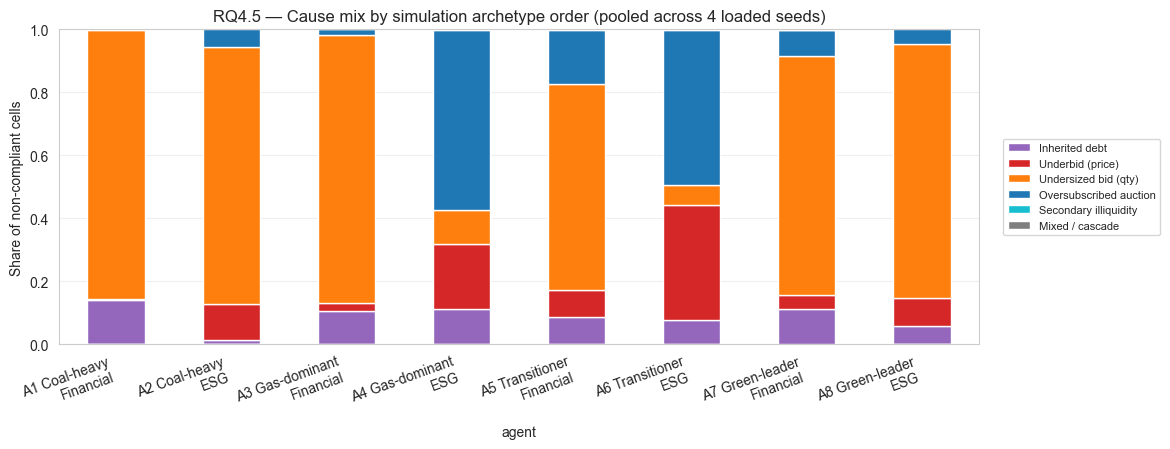

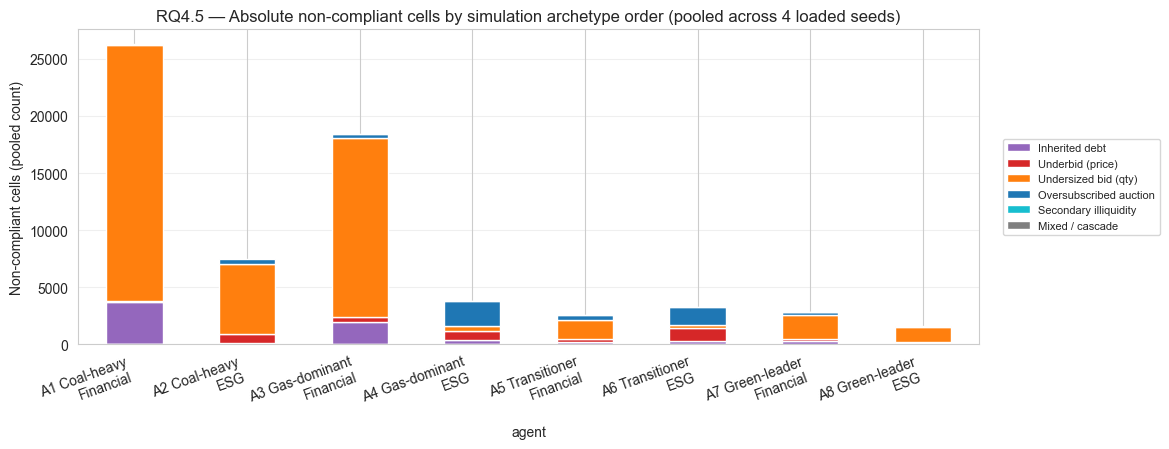

[RQ4.5] Compliant vs non-compliant cell means and medians (key discriminators):


,feature,compliant_mean,non_compliant_mean,delta_mean_(nc - c),compliant_median,non_compliant_median,delta_median_(nc - c)
0,inherited_debt_Mt,0.060,0.739,0.678,0.000,0.173,0.173
1,bank_start_Mt,2.372,0.309,-2.063,1.956,0.000,-1.956
2,bid_qty_mult,1.418,0.719,-0.700,1.814,0.500,-1.314
3,bid_to_clearing,1.789,2.281,0.492,1.545,2.271,0.726
4,coverage_gap_Mt,0.481,2.104,1.623,0.000,2.107,2.107


[RQ4.5] Auction-stressed but ultimately compliant cells: 142,175
        Stressed = auction allocation < emissions + carry-forward start; final shortfall = 0.


,n_cells,share_pct,mean_initial_gap_Mt,median_initial_gap_Mt,sum_initial_gap_Mt,mean_bank_start_Mt,mean_bank_used_estimate_Mt,mean_secondary_buy_Mt,sum_secondary_buy_Mt,mean_secondary_paid_Meur,sum_secondary_paid_Meur,mean_secondary_paid_price_EUR_t
solution,,,,,,,,,,,,
Banked allowances,96327,67.752,0.890,0.840,85738.173,3.020,0.870,0.020,1948.997,1.849,1.780747e+05,89.952
Secondary market,44237,31.114,1.650,1.627,72984.968,0.937,0.000,2.837,125519.232,410.794,1.817231e+07,142.228
Bank + secondary,1611,1.133,1.932,1.722,3113.214,1.228,0.478,1.455,2343.612,215.366,3.469541e+05,127.979
Other / accounting buffer,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000000e+00,0.000


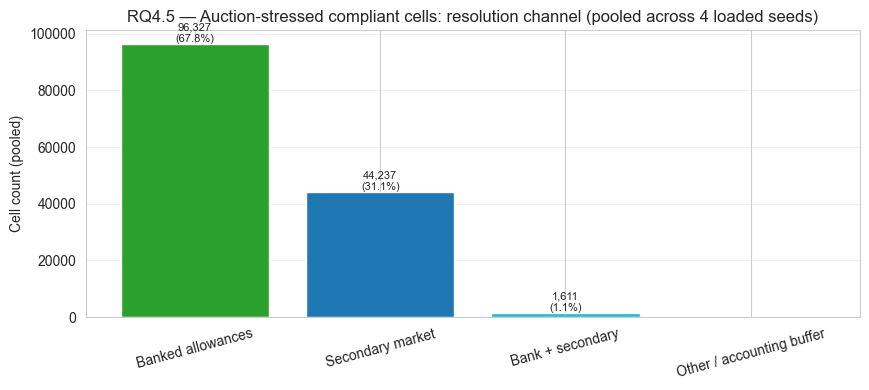

[RQ4.5] Writing cell output PDF to: C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\results\analysis\rq45_cell_output.pdf
[RQ4.5] PDF export complete: C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\results\analysis\rq45_cell_output.pdf


In [29]:
# RQ4.5 — Per-cell root-cause attribution for non-compliant (agent, year)
# cells in the converged tail window. Cells silently no-op on logs lacking
# the v8.6.1+ year-log columns.
import textwrap
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EPS_MT = 1e-6
CAUSE_ORDER = ['Inherited debt', 'Underbid (price)', 'Undersized bid (qty)',
               'Oversubscribed auction', 'Secondary illiquidity', 'Mixed / cascade']
CAUSE_COLORS = {
    'Inherited debt':         '#9467bd',
    'Underbid (price)':       '#d62728',
    'Undersized bid (qty)':   '#ff7f0e',
    'Oversubscribed auction': '#1f77b4',
    'Secondary illiquidity':  '#17becf',
    'Mixed / cascade':        '#7f7f7f',
}
STRESSED_SOLUTION_ORDER = [
    'Banked allowances', 'Secondary market', 'Bank + secondary', 'Other / accounting buffer'
]
STRESSED_SOLUTION_COLORS = {
    'Banked allowances': '#2ca02c',
    'Secondary market': '#1f77b4',
    'Bank + secondary': '#17becf',
    'Other / accounting buffer': '#7f7f7f',
}

EXPORT_RQ45_CELL_PDF = True
RQ45_CELL_PDF_PATH = (PROJECT_ROOT / 'results' / 'analysis' / 'rq45_cell_output.pdf'
                      if 'PROJECT_ROOT' in globals() else Path('rq45_cell_output.pdf'))
RQ45_AGENT_ORDER = list(range(1, N_AGENTS + 1))
RQ45_BASELINE_ROWS = ['All tail cells (normal/default)', 'Fully compliant cells']
RQ45_DIAG_ROW_ORDER = RQ45_BASELINE_ROWS + CAUSE_ORDER
RQ45_DIAG_FEATURES = [
    'shortfall_Mt', 'inherited_debt_Mt', 'alloc_Mt', 'emissions_Mt',
    'bid_price', 'clearing_price', 'bid_to_clearing', 'bid_qty_mult',
    'bid_coverage_ratio', 'estimate_need_Mt', 'need_realised_Mt',
    'undersized_qty_Mt', 'oversubscription_ratio', 'bank_start_Mt',
    'sec_buy_intent_Mt', 'secondary_buy_unmet_Mt', 'loan_outstanding_Meur',
]


def _rq45_agent_label(agent_num):
    idx0 = agent_num - 1
    weighting = _agent_weighting(idx0)
    weighting_short = 'ESG' if weighting == 'Balanced ESG' else weighting
    return f'A{agent_num} {_agent_archetype(idx0)}\n{weighting_short}'


RQ45_AGENT_LABELS = {agent: _rq45_agent_label(agent) for agent in RQ45_AGENT_ORDER}
_rq45_pdf_items = []
_rq45_diag_values = {
    row_label: {feature: [] for feature in RQ45_DIAG_FEATURES}
    for row_label in RQ45_DIAG_ROW_ORDER
}
stressed_rows = []


def _rq45_log(message):
    print(message)
    _rq45_pdf_items.append(('text', str(message)))


def _rq45_record_table(title, df):
    _rq45_pdf_items.append(('table', title, df.copy()))


def _rq45_record_figure(title, fig):
    _rq45_pdf_items.append(('figure', title, fig))


def _rq45_append_diag_values(row_label, mask, feature_values):
    mask = np.asarray(mask, dtype=bool)
    if not mask.any():
        return
    for feature in RQ45_DIAG_FEATURES:
        values = feature_values.get(feature)
        if values is None:
            continue
        arr = np.asarray(values, dtype=float)
        if arr.shape[0] != mask.shape[0]:
            continue
        _rq45_diag_values[row_label][feature].append(arr[mask])


def _rq45_concat_diag(row_label, feature):
    pieces = _rq45_diag_values.get(row_label, {}).get(feature, [])
    if not pieces:
        return np.asarray([], dtype=float)
    return np.concatenate([np.asarray(p, dtype=float) for p in pieces])


def _rq45_stat(values, stat):
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return np.nan
    if stat == 'mean':
        return float(np.mean(finite))
    if stat == 'median':
        return float(np.median(finite))
    if stat == 'std':
        return float(np.std(finite, ddof=1)) if finite.size > 1 else np.nan
    raise ValueError(stat)


def _rq45_build_diag_summary():
    rows = []
    for row_label in RQ45_DIAG_ROW_ORDER:
        shortfall_values = _rq45_concat_diag(row_label, 'shortfall_Mt')
        row = {'diagnostic_group': row_label, 'n_cells': int(shortfall_values.size)}
        for feature in RQ45_DIAG_FEATURES:
            values = _rq45_concat_diag(row_label, feature)
            for stat in ['mean', 'median', 'std']:
                row[f'{feature}_{stat}'] = _rq45_stat(values, stat)
        rows.append(row)
    return pd.DataFrame(rows).set_index('diagnostic_group')


def _stressed_solution_label(gap, bank_available, sec_bought):
    if sec_bought >= gap - EPS_MT and sec_bought > EPS_MT:
        return 'Secondary market'
    if bank_available >= gap - EPS_MT and bank_available > EPS_MT:
        return 'Banked allowances'
    if sec_bought > EPS_MT and bank_available > EPS_MT and sec_bought + bank_available >= gap - EPS_MT:
        return 'Bank + secondary'
    if sec_bought > EPS_MT:
        return 'Secondary market'
    if bank_available > EPS_MT:
        return 'Banked allowances'
    return 'Other / accounting buffer'


def _rq45_pdf_text_pages(pdf, title, text, chars_per_line=118, lines_per_page=45):
    lines = []
    for raw_line in str(text).splitlines() or ['']:
        if len(raw_line) <= chars_per_line:
            lines.append(raw_line)
        else:
            lines.extend(textwrap.wrap(raw_line, width=chars_per_line,
                                       break_long_words=False,
                                       replace_whitespace=False) or [''])
    chunks = [lines[i:i + lines_per_page] for i in range(0, len(lines), lines_per_page)] or [[]]
    for page_idx, chunk in enumerate(chunks):
        fig = plt.figure(figsize=(11.69, 8.27))
        page_title = title if len(chunks) == 1 else f'{title} ({page_idx + 1}/{len(chunks)})'
        fig.text(0.02, 0.97, page_title, fontsize=12, weight='bold', va='top')
        fig.text(0.02, 0.91, '\n'.join(chunk), fontsize=8, family='monospace', va='top')
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)


def _rq45_pdf_table_pages(pdf, title, df, cols_per_page=6):
    if df.empty:
        _rq45_pdf_text_pages(pdf, title, '<empty>')
        return
    table_df = df.copy()
    if len(table_df.columns) <= cols_per_page:
        _rq45_pdf_text_pages(pdf, title, table_df.to_string())
        return
    for start in range(0, len(table_df.columns), cols_per_page):
        end = min(start + cols_per_page, len(table_df.columns))
        page_df = table_df.iloc[:, start:end]
        page_title = f'{title} | columns {start + 1}-{end} of {len(table_df.columns)}'
        _rq45_pdf_text_pages(pdf, page_title, page_df.to_string())


def _rq45_export_pdf(items, path):
    if not items:
        return None
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with PdfPages(path) as pdf:
        cover = plt.figure(figsize=(11.69, 8.27))
        cover.text(0.05, 0.92, 'RQ4.5 cell output', fontsize=18, weight='bold', va='top')
        cover.text(0.05, 0.84, f'Notebook cell export: {path.name}', fontsize=10, va='top')
        cover.text(0.05, 0.78, 'Includes this cell\'s printed text, displayed tables, and generated figures.',
                   fontsize=10, va='top')
        pdf.savefig(cover, bbox_inches='tight')
        plt.close(cover)
        for item in items:
            kind = item[0]
            if kind == 'text':
                _rq45_pdf_text_pages(pdf, 'Printed output', item[1])
            elif kind == 'table':
                _rq45_pdf_table_pages(pdf, item[1], item[2])
            elif kind == 'figure':
                pdf.savefig(item[2], bbox_inches='tight')
    return path


def _classify_row(sf, cf_start, alloc, emiss, bid_p, clear_p,
                  undersized_qty, oversub, sec_unmet):
    if sf <= EPS_MT:
        return None
    cf = max(0.0, float(cf_start))
    if alloc + EPS_MT >= emiss and cf >= sf - EPS_MT:
        return 'Inherited debt'
    if bid_p > 0 and clear_p > 0 and bid_p < 0.995 * clear_p:
        return 'Underbid (price)'
    if undersized_qty > 0.5 * sf:
        return 'Undersized bid (qty)'
    if oversub > 1.05:
        return 'Oversubscribed auction'
    if sec_unmet > 0.25 * sf:
        return 'Secondary illiquidity'
    return 'Mixed / cascade'


nc_rows = []
rq45_tail_year_rows_by_run = {}
rq45_total_tail_cells = 0
for k, run in runs.items():
    yr = tail_year_rows(run)
    if yr.empty or 'year' not in yr.columns:
        continue
    n = len(yr)
    rq45_tail_year_rows_by_run[k] = n
    rq45_total_tail_cells += n * N_AGENTS
    cp_arr  = yr['clearing_price'].to_numpy(float)        if 'clearing_price'        in yr.columns else np.full(n, np.nan)
    sp_arr  = yr['secondary_price'].to_numpy(float)       if 'secondary_price'       in yr.columns else np.full(n, np.nan)
    atd     = yr['auction_total_demand'].to_numpy(float)  if 'auction_total_demand'  in yr.columns else np.full(n, np.nan)
    avol    = yr['auction_volume'].to_numpy(float)        if 'auction_volume'        in yr.columns else np.full(n, np.nan)
    ns_exec = yr['secondary_n_sellers_executed'].to_numpy(float) if 'secondary_n_sellers_executed' in yr.columns else np.full(n, np.nan)
    yr_arr  = yr['year'].to_numpy(int)
    ep_arr  = yr['episode'].to_numpy(int) if 'episode' in yr.columns else np.zeros(n, dtype=int)
    oversub_y = np.where(avol > 1e-9, atd / avol, np.nan)

    for i in range(N_AGENTS):
        cols_req = [f'shortfall_A{i+1}', f'alloc_A{i+1}', f'emissions_A{i+1}',
                    f'carry_forward_start_A{i+1}', f'bid_price_A{i+1}',
                    f'estimate_need_A{i+1}', f'bid_qty_mult_A{i+1}',
                    f'bank_start_A{i+1}', f'trade_qty_A{i+1}',
                    f'sec_qty_action_A{i+1}']
        if not all(c in yr.columns for c in cols_req):
            continue
        sf = yr[f'shortfall_A{i+1}'].to_numpy(float)
        alloc = yr[f'alloc_A{i+1}'].to_numpy(float)
        emiss = yr[f'emissions_A{i+1}'].to_numpy(float)
        cf_st = yr[f'carry_forward_start_A{i+1}'].to_numpy(float)
        bidp  = yr[f'bid_price_A{i+1}'].to_numpy(float)
        en    = yr[f'estimate_need_A{i+1}'].to_numpy(float)
        qm    = yr[f'bid_qty_mult_A{i+1}'].to_numpy(float)
        bank  = yr[f'bank_start_A{i+1}'].to_numpy(float)
        trq   = yr[f'trade_qty_A{i+1}'].to_numpy(float)
        sqa   = yr[f'sec_qty_action_A{i+1}'].to_numpy(float)
        cf_e  = yr[f'carry_forward_end_A{i+1}'].to_numpy(float) if f'carry_forward_end_A{i+1}' in yr.columns else np.full(n, np.nan)
        loan  = yr[f'loan_outstanding_A{i+1}'].to_numpy(float)  if f'loan_outstanding_A{i+1}'  in yr.columns else np.full(n, np.nan)
        tdr   = yr[f'treasury_drawn_A{i+1}'].to_numpy(float)    if f'treasury_drawn_A{i+1}'    in yr.columns else np.full(n, np.nan)
        cgap  = yr[f'coverage_gap_A{i+1}'].to_numpy(float)      if f'coverage_gap_A{i+1}'      in yr.columns else np.full(n, np.nan)
        sec_net = (yr[f'secondary_net_A{i+1}'].to_numpy(float)
                   if f'secondary_net_A{i+1}' in yr.columns else np.full(n, np.nan))

        # need_realised = emissions + inherited debt the agent had to cover.
        need_realised  = emiss + np.maximum(0.0, cf_st)
        bid_qty_target = np.maximum(0.0, qm) * np.maximum(0.0, en)
        undersized_qty = np.maximum(0.0, need_realised - bid_qty_target)
        auction_gap    = np.maximum(0.0, need_realised - alloc)
        sec_intent_buy = np.maximum(0.0, sqa)
        sec_bought     = np.maximum(0.0, trq)
        sec_unmet      = np.maximum(0.0, sec_intent_buy - sec_bought)
        bank_available = np.maximum(0.0, bank)
        sec_paid_fallback = np.where(np.isfinite(sp_arr), sec_bought * sp_arr, np.nan)
        sec_direct_paid = np.where(np.isfinite(sec_net) & (sec_net > EPS_MT), sec_net, np.nan)
        sec_paid = np.where(np.isfinite(sec_direct_paid), sec_direct_paid, sec_paid_fallback)
        sec_paid = np.where(sec_bought > EPS_MT, sec_paid, 0.0)
        residual_after_secondary = np.maximum(0.0, auction_gap - sec_bought)
        bank_used_est = np.minimum(bank_available, residual_after_secondary)
        with np.errstate(divide='ignore', invalid='ignore'):
            bid_to_clearing = np.where(cp_arr > 1e-9, bidp / cp_arr, np.nan)
            bid_coverage_ratio = np.where(need_realised > 1e-9,
                                          bid_qty_target / need_realised,
                                          np.nan)
            sec_paid_price = np.where(sec_bought > EPS_MT, sec_paid / sec_bought, np.nan)

        feature_values = {
            'shortfall_Mt': sf,
            'inherited_debt_Mt': cf_st,
            'alloc_Mt': alloc,
            'emissions_Mt': emiss,
            'bid_price': bidp,
            'clearing_price': cp_arr,
            'bid_to_clearing': bid_to_clearing,
            'bid_qty_mult': qm,
            'bid_coverage_ratio': bid_coverage_ratio,
            'estimate_need_Mt': en,
            'need_realised_Mt': need_realised,
            'undersized_qty_Mt': undersized_qty,
            'oversubscription_ratio': oversub_y,
            'bank_start_Mt': bank,
            'sec_buy_intent_Mt': sec_intent_buy,
            'secondary_buy_unmet_Mt': sec_unmet,
            'loan_outstanding_Meur': loan,
        }
        compliant_mask = sf <= EPS_MT
        _rq45_append_diag_values('All tail cells (normal/default)', np.ones(n, dtype=bool), feature_values)
        _rq45_append_diag_values('Fully compliant cells', compliant_mask, feature_values)

        stressed_mask = (auction_gap > EPS_MT) & compliant_mask
        for j in np.where(stressed_mask)[0]:
            gap = float(auction_gap[j])
            sec_buy = float(sec_bought[j])
            bank_avail = float(bank_available[j])
            solution = _stressed_solution_label(gap, bank_avail, sec_buy)
            stressed_rows.append({
                'run': f'{k[1]}/s{k[2]}',
                'episode': int(ep_arr[j]),
                'year': int(yr_arr[j]),
                'agent': i + 1,
                'archetype': _agent_archetype(i),
                'weighting': _agent_weighting(i),
                'solution': solution,
                'initial_auction_gap_Mt': gap,
                'need_realised_Mt': float(need_realised[j]),
                'alloc_Mt': float(alloc[j]),
                'bank_start_Mt': bank_avail,
                'bank_used_estimate_Mt': float(bank_used_est[j]),
                'secondary_buy_Mt': sec_buy,
                'secondary_paid_Meur': float(sec_paid[j]) if np.isfinite(sec_paid[j]) else np.nan,
                'secondary_paid_price_EUR_t': float(sec_paid_price[j]) if np.isfinite(sec_paid_price[j]) else np.nan,
            })

        nc_mask = sf > EPS_MT
        if not nc_mask.any():
            continue

        cause_arr = np.full(n, None, dtype=object)
        for j in np.where(nc_mask)[0]:
            cp_j = float(cp_arr[j]) if np.isfinite(cp_arr[j]) else 0.0
            os_j = float(oversub_y[j]) if np.isfinite(oversub_y[j]) else 0.0
            cause = _classify_row(
                sf=float(sf[j]), cf_start=float(cf_st[j]),
                alloc=float(alloc[j]), emiss=float(emiss[j]),
                bid_p=float(bidp[j]), clear_p=cp_j,
                undersized_qty=float(undersized_qty[j]),
                oversub=os_j, sec_unmet=float(sec_unmet[j]),
            )
            cause_arr[j] = cause
            nc_rows.append({
                'run':    f'{k[1]}/s{k[2]}',
                'episode': int(ep_arr[j]),
                'year':    int(yr_arr[j]),
                'agent':   i + 1,
                'archetype': _agent_archetype(i),
                'weighting': _agent_weighting(i),
                'shortfall_Mt':           float(sf[j]),
                'inherited_debt_Mt':      float(cf_st[j]),
                'alloc_Mt':               float(alloc[j]),
                'emissions_Mt':           float(emiss[j]),
                'bid_price':              float(bidp[j]),
                'clearing_price':         cp_j,
                'bid_to_clearing':        float(bid_to_clearing[j]) if np.isfinite(bid_to_clearing[j]) else np.nan,
                'bid_qty_mult':           float(qm[j]),
                'bid_coverage_ratio':     float(bid_coverage_ratio[j]) if np.isfinite(bid_coverage_ratio[j]) else np.nan,
                'estimate_need_Mt':       float(en[j]),
                'need_realised_Mt':       float(need_realised[j]),
                'undersized_qty_Mt':      float(undersized_qty[j]),
                'oversubscription_ratio': os_j,
                'bank_start_Mt':          float(bank[j]),
                'sec_buy_intent_Mt':      float(sec_intent_buy[j]),
                'secondary_buy_unmet_Mt': float(sec_unmet[j]),
                'n_sellers_executed':     float(ns_exec[j]) if np.isfinite(ns_exec[j]) else np.nan,
                'carry_forward_end_Mt':   float(cf_e[j]),
                'loan_outstanding_Meur':  float(loan[j]),
                'treasury_drawn_Meur':    float(tdr[j]),
                'coverage_gap_Mt':        float(cgap[j]),
                'cause':                  cause,
            })

        for cause_label in CAUSE_ORDER:
            _rq45_append_diag_values(cause_label, cause_arr == cause_label, feature_values)

incomp_df = pd.DataFrame(nc_rows)
stressed_df = pd.DataFrame(stressed_rows)
rq45_expected_cells_per_run = TAIL_EPISODES * N_AGENTS * N_YEARS
rq45_loaded_run_count = len(rq45_tail_year_rows_by_run)
_rq45_log(
    f'[RQ4.5] Denominator: {rq45_loaded_run_count} loaded run(s) × '
    f'{TAIL_EPISODES} tail episodes × {N_AGENTS} agents × {N_YEARS} years '
    f'= {rq45_loaded_run_count * rq45_expected_cells_per_run:,} expected cells '
    f'({rq45_expected_cells_per_run:,} per run); actual counted cells = '
    f'{rq45_total_tail_cells:,}.'
)
if rq45_total_tail_cells > 0:
    _rq45_log(
        f'[RQ4.5] Final non-compliant cells: {len(incomp_df):,} '
        f'({100.0 * len(incomp_df) / rq45_total_tail_cells:.1f}%); '
        f'auction-stressed but compliant cells: {len(stressed_df):,} '
        f'({100.0 * len(stressed_df) / rq45_total_tail_cells:.1f}%).'
    )

if incomp_df.empty:
    _rq45_log('[RQ4.5] No non-compliant (agent, year) cells in the converged window — '
              'agents are fully compliant. Skipping attribution panels.')
else:
    incomp_df['cause'] = pd.Categorical(incomp_df['cause'], categories=CAUSE_ORDER, ordered=True)

    # (a) Counts and tonne-weighted shares per cause.
    cause_counts = (incomp_df.groupby('cause', observed=True)
                              .agg(n_cells=('shortfall_Mt', 'size'),
                                   sum_shortfall_Mt=('shortfall_Mt', 'sum'),
                                   mean_shortfall_Mt=('shortfall_Mt', 'mean'),
                                   median_shortfall_Mt=('shortfall_Mt', 'median'))
                              .reindex(CAUSE_ORDER).fillna(0.0))
    total_cells = max(1, int(cause_counts['n_cells'].sum()))
    total_tons  = max(1e-9, float(cause_counts['sum_shortfall_Mt'].sum()))
    cause_counts['cell_share_pct']  = 100.0 * cause_counts['n_cells']         / total_cells
    cause_counts['tonne_share_pct'] = 100.0 * cause_counts['sum_shortfall_Mt'] / total_tons

    _rq45_log(f'[RQ4.5] Non-compliant (agent, year, episode) cells in converged window: '
              f'{len(incomp_df):,}')
    _rq45_log(f'[RQ4.5] Σ shortfall across the window: '
              f'{incomp_df["shortfall_Mt"].sum():,.2f} Mt')
    cause_counts_display = cause_counts.round(3)
    _rq45_record_table('Cause counts and shares', cause_counts_display)
    display(cause_counts_display)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
    colors = [CAUSE_COLORS[c] for c in CAUSE_ORDER]
    axes[0].bar(CAUSE_ORDER, cause_counts['cell_share_pct'].values, color=colors)
    axes[0].set(title='Share of non-compliant cells by dominant cause',
                ylabel='% of (agent, year, episode) cells')
    axes[0].tick_params(axis='x', rotation=25); axes[0].grid(alpha=0.3, axis='y')

    axes[1].bar(CAUSE_ORDER, cause_counts['tonne_share_pct'].values, color=colors)
    axes[1].set(title='Share of total shortfall tonnes by dominant cause',
                ylabel='% of Σ shortfall (Mt)')
    axes[1].tick_params(axis='x', rotation=25); axes[1].grid(alpha=0.3, axis='y')
    plt.suptitle(f'RQ4.5 — Why agents go non-compliant in the converged window '
                 f'(pooled across {rq45_loaded_run_count} loaded seeds)',
                 y=1.03, fontsize=13)
    plt.tight_layout()
    _rq45_record_figure('Cause shares', fig)
    plt.show()

    # (b) Baseline and per-cause diagnostic feature values.
    cause_feature_summary = _rq45_build_diag_summary()
    _rq45_log('[RQ4.5] Baseline and per-cause feature values (mean / median / std):')
    _rq45_log('        All tail cells = normal/default-config bid baseline; '
              'Fully compliant cells = regular successful bid baseline.')
    cause_feature_display = cause_feature_summary.round(3)
    _rq45_record_table('Baseline and per-cause feature values', cause_feature_display)
    display(cause_feature_display)

    # (c) Simulation-ordered per-agent cause split (A1..A8: archetype x weighting).
    agent_cause_counts = (incomp_df.groupby(['agent', 'cause'], observed=True)
                                   .size().unstack('cause', fill_value=0)
                                   .reindex(index=RQ45_AGENT_ORDER,
                                            columns=CAUSE_ORDER,
                                            fill_value=0).astype(int))
    agent_labels = [RQ45_AGENT_LABELS.get(agent, f'A{agent}')
                    for agent in agent_cause_counts.index]
    agent_cause_share = (agent_cause_counts
                         .div(agent_cause_counts.sum(axis=1).replace(0, np.nan), axis=0)
                         .fillna(0.0))

    if not agent_cause_share.empty:
        fig, ax = plt.subplots(figsize=(11.8, 4.6))
        agent_cause_share.plot(kind='bar', stacked=True, ax=ax,
                               color=[CAUSE_COLORS[c] for c in agent_cause_share.columns])
        ax.set(title=f'RQ4.5 — Cause mix by simulation archetype order '
                     f'(pooled across {rq45_loaded_run_count} loaded seeds)',
               ylabel='Share of non-compliant cells', ylim=(0, 1.0))
        ax.set_xticklabels(agent_labels, rotation=20, ha='right')
        ax.legend(fontsize=8, loc='center left', bbox_to_anchor=(1.02, 0.5))
        ax.grid(alpha=0.3, axis='y')
        plt.tight_layout()
        _rq45_record_figure('Agent-ordered cause mix shares', fig)
        plt.show()

        fig_abs, ax_abs = plt.subplots(figsize=(11.8, 4.6))
        agent_cause_counts.plot(kind='bar', stacked=True, ax=ax_abs,
                                color=[CAUSE_COLORS[c] for c in agent_cause_counts.columns])
        ax_abs.set(title=f'RQ4.5 — Absolute non-compliant cells by simulation archetype order '
                         f'(pooled across {rq45_loaded_run_count} loaded seeds)',
                   ylabel='Non-compliant cells (pooled count)')
        ax_abs.set_xticklabels(agent_labels, rotation=20, ha='right')
        ax_abs.legend(fontsize=8, loc='center left', bbox_to_anchor=(1.02, 0.5))
        ax_abs.grid(alpha=0.3, axis='y')
        plt.tight_layout()
        _rq45_record_figure('Agent-ordered absolute cause counts', fig_abs)
        plt.show()

    # (d) Compliant vs non-compliant feature contrast on the same tail window.
    comp_pieces = []
    for k, run in runs.items():
        yr = tail_year_rows(run)
        if yr.empty: continue
        for i in range(N_AGENTS):
            sf_col = f'shortfall_A{i+1}'
            if sf_col not in yr.columns: continue
            sf = yr[sf_col].to_numpy(float)
            cmask = sf <= EPS_MT
            if not cmask.any(): continue
            row = {}
            for stub, src_col in [
                ('inherited_debt_Mt', f'carry_forward_start_A{i+1}'),
                ('bank_start_Mt',     f'bank_start_A{i+1}'),
                ('bid_qty_mult',      f'bid_qty_mult_A{i+1}'),
                ('bid_price',         f'bid_price_A{i+1}'),
                ('coverage_gap_Mt',   f'coverage_gap_A{i+1}'),
            ]:
                row[stub] = (yr.loc[cmask, src_col].to_numpy(float)
                             if src_col in yr.columns else np.full(int(cmask.sum()), np.nan))
            row['clearing_price'] = (yr.loc[cmask, 'clearing_price'].to_numpy(float)
                                     if 'clearing_price' in yr.columns
                                     else np.full(int(cmask.sum()), np.nan))
            comp_pieces.append(pd.DataFrame(row))
    if comp_pieces:
        comp_df = pd.concat(comp_pieces, ignore_index=True)
        comp_df['bid_to_clearing'] = (comp_df['bid_price']
                                       / comp_df['clearing_price'].replace(0, np.nan))
        nc_with = incomp_df.copy()
        nc_with['bid_to_clearing'] = (nc_with['bid_price']
                                       / nc_with['clearing_price'].replace(0, np.nan))
        contrast_cols = ['inherited_debt_Mt', 'bank_start_Mt',
                         'bid_qty_mult', 'bid_to_clearing', 'coverage_gap_Mt']
        rows = []
        for c in contrast_cols:
            cv = comp_df[c].replace([np.inf, -np.inf], np.nan).dropna() if c in comp_df.columns else pd.Series(dtype=float)
            nv = nc_with[c].replace([np.inf, -np.inf], np.nan).dropna() if c in nc_with.columns else pd.Series(dtype=float)
            cv_mean = float(cv.mean()) if len(cv) else np.nan
            nv_mean = float(nv.mean()) if len(nv) else np.nan
            cv_median = float(cv.median()) if len(cv) else np.nan
            nv_median = float(nv.median()) if len(nv) else np.nan
            rows.append({
                'feature': c,
                'compliant_mean':        cv_mean,
                'non_compliant_mean':    nv_mean,
                'delta_mean_(nc - c)':   (nv_mean - cv_mean if len(cv) and len(nv) else np.nan),
                'compliant_median':      cv_median,
                'non_compliant_median':  nv_median,
                'delta_median_(nc - c)': (nv_median - cv_median if len(cv) and len(nv) else np.nan),
            })
        _rq45_log('[RQ4.5] Compliant vs non-compliant cell means and medians (key discriminators):')
        contrast_display = pd.DataFrame(rows).round(3)
        _rq45_record_table('Compliant vs non-compliant feature contrast', contrast_display)
        display(contrast_display)

# (e) Auction-stressed but ultimately compliant cells: how did agents save the year?
if stressed_df.empty:
    _rq45_log('[RQ4.5] No auction-stressed but ultimately compliant cells found in the converged window.')
else:
    stressed_df['solution'] = pd.Categorical(
        stressed_df['solution'], categories=STRESSED_SOLUTION_ORDER, ordered=True
    )
    stressed_summary = (stressed_df.groupby('solution', observed=False)
                                   .agg(n_cells=('initial_auction_gap_Mt', 'size'),
                                        share_pct=('initial_auction_gap_Mt', lambda s: 100.0 * len(s) / len(stressed_df)),
                                        mean_initial_gap_Mt=('initial_auction_gap_Mt', 'mean'),
                                        median_initial_gap_Mt=('initial_auction_gap_Mt', 'median'),
                                        sum_initial_gap_Mt=('initial_auction_gap_Mt', 'sum'),
                                        mean_bank_start_Mt=('bank_start_Mt', 'mean'),
                                        mean_bank_used_estimate_Mt=('bank_used_estimate_Mt', 'mean'),
                                        mean_secondary_buy_Mt=('secondary_buy_Mt', 'mean'),
                                        sum_secondary_buy_Mt=('secondary_buy_Mt', 'sum'),
                                        mean_secondary_paid_Meur=('secondary_paid_Meur', 'mean'),
                                        sum_secondary_paid_Meur=('secondary_paid_Meur', 'sum'),
                                        mean_secondary_paid_price_EUR_t=('secondary_paid_price_EUR_t', 'mean'))
                                   .reindex(STRESSED_SOLUTION_ORDER).fillna(0.0))
    _rq45_log(f'[RQ4.5] Auction-stressed but ultimately compliant cells: {len(stressed_df):,}')
    _rq45_log('        Stressed = auction allocation < emissions + carry-forward start; final shortfall = 0.')
    stressed_display = stressed_summary.round(3)
    _rq45_record_table('Auction-stressed compliant cells by solution', stressed_display)
    display(stressed_display)

    fig_stress, ax_stress = plt.subplots(figsize=(8.8, 4.0))
    stress_counts = stressed_summary['n_cells'].astype(int)
    stress_colors = [STRESSED_SOLUTION_COLORS[s] for s in stress_counts.index]
    bars = ax_stress.bar(stress_counts.index.astype(str), stress_counts.values, color=stress_colors)
    total_stressed = max(1, int(stress_counts.sum()))
    for bar, count in zip(bars, stress_counts.values):
        if count <= 0:
            continue
        ax_stress.text(bar.get_x() + bar.get_width() / 2,
                       bar.get_height(),
                       f'{count:,}\n({100.0 * count / total_stressed:.1f}%)',
                       ha='center', va='bottom', fontsize=8)
    ax_stress.set(title=f'RQ4.5 — Auction-stressed compliant cells: resolution channel '
                        f'(pooled across {rq45_loaded_run_count} loaded seeds)',
                  ylabel='Cell count (pooled)')
    ax_stress.tick_params(axis='x', rotation=15)
    ax_stress.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    _rq45_record_figure('Auction-stressed compliant resolution counts', fig_stress)
    plt.show()

if EXPORT_RQ45_CELL_PDF:
    _rq45_log(f'[RQ4.5] Writing cell output PDF to: {RQ45_CELL_PDF_PATH}')
    _rq45_pdf_path = _rq45_export_pdf(_rq45_pdf_items, RQ45_CELL_PDF_PATH)
    if _rq45_pdf_path is not None:
        print(f'[RQ4.5] PDF export complete: {_rq45_pdf_path}')

[RQ4.5 add-on] Status shares: % of all tail-window agent-year cells within each reward type


,Auction compliant,Stressed,Incompliant
reward_type,,,
Financial,38.1,35.8,26.1
Balanced ESG,53.4,38.2,8.4


[RQ4.5 add-on] Stressed split: % within stressed cells for each reward type


reward_type,Financial,Balanced ESG
stressed bridge (% within stressed),,
Banked-allowance bridge,59.9,73.5
Secondary-market bridge,40.1,26.5


[RQ4.5 add-on] Incompliant split: % within incompliant cells for each reward type


reward_type,Financial,Balanced ESG
incompliant cause (% within incompliant),,
Undersized bid (qty),83.7,49.6
Inherited debt,12.4,5.5
Oversubscribed auction,2.1,26.6
Underbid (price),1.7,18.4
Other incompliance,0.0,0.0


[RQ4.5 add-on] Plotted segment shares: % of all tail-window cells within each reward type


reward_type                                                       Financial  Balanced ESG
status            segment (% of all cells; matches stacked bars)                         
Auction compliant Auction compliant                                    38.1          53.4
Stressed          Banked-allowance bridge                              21.5          28.1
                  Secondary-market bridge                              14.4          10.1
Incompliant       Inherited debt                                        3.2           0.5
                  Other incompliance                                    0.0           0.0
                  Oversubscribed auction                                0.6           2.2
                  Underbid (price)                                      0.5           1.5
                  Undersized bid (qty)                                 21.8           4.1

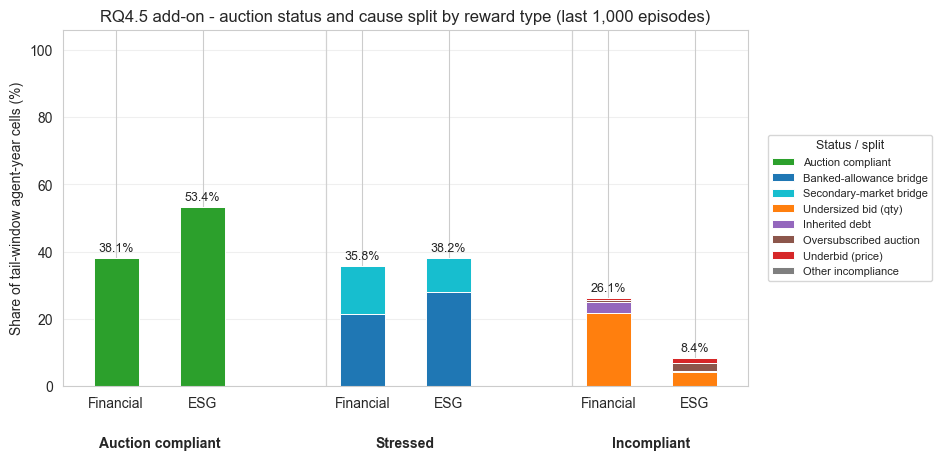

[RQ4.5 add-on] Raw pooled cell counts for plotted segments:


reward_type                                Financial  Balanced ESG
status            segment                                         
Auction compliant Auction compliant            73164        102549
Stressed          Banked-allowance bridge      41202         53950
                  Secondary-market bridge      27591         19432
Incompliant       Inherited debt                6192           878
                  Other incompliance               7             3
                  Oversubscribed auction        1061          4272
                  Underbid (price)               874          2951
                  Undersized bid (qty)         41909          7965

In [43]:
# RQ4.5 add-on - reward-level auction status and cause split.
# One bar chart: 3 statuses x 2 reward types. Stressed and incompliant bars
# are stacked by their dominant bridge/cause.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EPS_MT = globals().get('EPS_MT', 1e-6)
AUCTION_STATUS_ORDER = ['Auction compliant', 'Stressed', 'Incompliant']
STRESS_DETAIL_ORDER = ['Banked-allowance bridge', 'Secondary-market bridge', 'Other stress bridge']
INCOMP_CAUSE_PRIORITY = [
    'Inherited debt',
    'Underbid (price)',
    'Undersized bid (qty)',
    'Oversubscribed auction',
    'Secondary illiquidity',
    'Mixed / cascade',
]
DETAIL_COLORS = {
    'Auction compliant': '#2ca02c',
    'Banked-allowance bridge': '#1f77b4',
    'Secondary-market bridge': '#17becf',
    'Other stress bridge': '#7f7f7f',
    'Inherited debt': '#9467bd',
    'Underbid (price)': '#d62728',
    'Undersized bid (qty)': '#ff7f0e',
    'Oversubscribed auction': '#8c564b',
    'Secondary illiquidity': '#e377c2',
    'Mixed / cascade': '#bcbd22',
    'Other incompliance': '#7f7f7f',
}

reward_type_order = [
    w for w in ['Financial', 'Balanced ESG']
    if w in {_agent_weighting(i) for i in range(N_AGENTS)}
]
if not reward_type_order:
    reward_type_order = sorted({_agent_weighting(i) for i in range(N_AGENTS)})


def _series_values(frame, column, n_rows, fill_value=np.nan, clip_lower=None):
    if column not in frame.columns:
        return np.full(n_rows, fill_value, dtype=float)
    values = pd.to_numeric(frame[column], errors='coerce').fillna(fill_value)
    if clip_lower is not None:
        values = values.clip(lower=clip_lower)
    return values.to_numpy(float)


def _stressed_bridge_labels(auction_gap, bank_start, trade_qty):
    sec_bought = np.maximum(0.0, trade_qty)
    bank_available = np.maximum(0.0, bank_start)
    residual_after_secondary = np.maximum(0.0, auction_gap - sec_bought)
    bank_used_est = np.minimum(bank_available, residual_after_secondary)

    labels = np.full(len(auction_gap), 'Other stress bridge', dtype=object)
    secondary = (sec_bought > EPS_MT) & (sec_bought >= bank_used_est)
    banked = ~secondary & ((bank_used_est > EPS_MT) | (bank_available >= auction_gap - EPS_MT))
    labels[banked] = 'Banked-allowance bridge'
    labels[secondary] = 'Secondary-market bridge'
    return labels


def _incompliance_cause_labels(shortfall, alloc, emissions, cf_start, bid_price,
                               clearing_price, estimate_need, bid_qty_mult,
                               auction_total_demand, auction_volume,
                               sec_qty_action, trade_qty):
    n_rows = len(shortfall)
    labels = np.full(n_rows, 'Mixed / cascade', dtype=object)
    active = shortfall > EPS_MT
    remaining = active.copy()

    inherited = remaining & (alloc + EPS_MT >= emissions) & (np.maximum(0.0, cf_start) >= shortfall - EPS_MT)
    labels[inherited] = 'Inherited debt'
    remaining &= ~inherited

    underprice = remaining & (bid_price > 0) & (clearing_price > 0) & (bid_price < 0.995 * clearing_price)
    labels[underprice] = 'Underbid (price)'
    remaining &= ~underprice

    need_realised = emissions + np.maximum(0.0, cf_start)
    bid_qty_target = np.maximum(0.0, bid_qty_mult) * np.maximum(0.0, estimate_need)
    undersized_qty = np.maximum(0.0, need_realised - bid_qty_target)
    undersized = remaining & (undersized_qty > 0.5 * shortfall)
    labels[undersized] = 'Undersized bid (qty)'
    remaining &= ~undersized

    with np.errstate(divide='ignore', invalid='ignore'):
        oversubscription = np.where(auction_volume > 1e-9, auction_total_demand / auction_volume, np.nan)
    oversubscribed = remaining & (oversubscription > 1.05)
    labels[oversubscribed] = 'Oversubscribed auction'
    remaining &= ~oversubscribed

    sec_unmet = np.maximum(0.0, np.maximum(0.0, sec_qty_action) - np.maximum(0.0, trade_qty))
    secondary_illiquid = remaining & (sec_unmet > 0.25 * shortfall)
    labels[secondary_illiquid] = 'Secondary illiquidity'
    return labels


def _append_counts(rows, reward_type, status_label, detail_labels, mask):
    if not np.any(mask):
        return
    labels, counts = np.unique(detail_labels[mask], return_counts=True)
    for detail_label, count in zip(labels, counts):
        rows.append({
            'reward_type': reward_type,
            'status': status_label,
            'detail': str(detail_label),
            'n_cells': int(count),
        })


def _clean_pct_table(frame, row_col, denominator_col, order):
    if frame.empty:
        return pd.DataFrame(columns=reward_type_order)
    counts = frame.pivot_table(
        index=row_col,
        columns='reward_type',
        values='n_cells',
        aggfunc='sum',
        fill_value=0,
        observed=True,
    ).reindex(columns=reward_type_order, fill_value=0)
    denominators = denominator_col.reindex(reward_type_order).replace(0, np.nan)
    pct = counts.div(denominators, axis=1).mul(100.0).fillna(0.0)
    pct = pct.loc[pct.sum(axis=1) > 0]
    pct = pct.reindex([item for item in order if item in pct.index])
    return pct.round(1)


auction_status_rows = []
missing_status_cols = set()
for run_key, run_data in runs.items():
    yr = tail_year_rows(run_data)
    if yr.empty:
        continue
    n_rows = len(yr)
    clearing_price = _series_values(yr, 'clearing_price', n_rows)
    auction_total_demand = _series_values(yr, 'auction_total_demand', n_rows)
    auction_volume = _series_values(yr, 'auction_volume', n_rows)

    for agent_idx in range(N_AGENTS):
        agent_no = agent_idx + 1
        required = [
            f'shortfall_A{agent_no}',
            f'alloc_A{agent_no}',
            f'emissions_A{agent_no}',
            f'carry_forward_start_A{agent_no}',
        ]
        missing = [column for column in required if column not in yr.columns]
        if missing:
            missing_status_cols.update(missing)
            continue

        reward_type = _agent_weighting(agent_idx)
        shortfall = _series_values(yr, f'shortfall_A{agent_no}', n_rows, fill_value=0.0)
        alloc = _series_values(yr, f'alloc_A{agent_no}', n_rows, fill_value=0.0)
        emissions = _series_values(yr, f'emissions_A{agent_no}', n_rows, fill_value=0.0, clip_lower=0.0)
        cf_start = _series_values(yr, f'carry_forward_start_A{agent_no}', n_rows, fill_value=0.0, clip_lower=0.0)
        bank_start = _series_values(yr, f'bank_start_A{agent_no}', n_rows, fill_value=0.0, clip_lower=0.0)
        trade_qty = _series_values(yr, f'trade_qty_A{agent_no}', n_rows, fill_value=0.0)
        bid_price = _series_values(yr, f'bid_price_A{agent_no}', n_rows)
        estimate_need = _series_values(yr, f'estimate_need_A{agent_no}', n_rows)
        bid_qty_mult = _series_values(yr, f'bid_qty_mult_A{agent_no}', n_rows)
        sec_qty_action = _series_values(yr, f'sec_qty_action_A{agent_no}', n_rows, fill_value=0.0)

        need_realised = emissions + cf_start
        auction_gap = np.maximum(0.0, need_realised - alloc)
        incompliant_mask = shortfall > EPS_MT
        stressed_mask = (auction_gap > EPS_MT) & ~incompliant_mask
        auction_compliant_mask = (auction_gap <= EPS_MT) & ~incompliant_mask

        _append_counts(
            auction_status_rows,
            reward_type,
            'Auction compliant',
            np.full(n_rows, 'Auction compliant', dtype=object),
            auction_compliant_mask,
        )
        _append_counts(
            auction_status_rows,
            reward_type,
            'Stressed',
            _stressed_bridge_labels(auction_gap, bank_start, trade_qty),
            stressed_mask,
        )
        _append_counts(
            auction_status_rows,
            reward_type,
            'Incompliant',
            _incompliance_cause_labels(
                shortfall, alloc, emissions, cf_start, bid_price, clearing_price,
                estimate_need, bid_qty_mult, auction_total_demand, auction_volume,
                sec_qty_action, trade_qty,
            ),
            incompliant_mask,
        )

auction_status_df = pd.DataFrame(auction_status_rows)
if auction_status_df.empty:
    print('[RQ4.5 add-on] No auction-status rows built.')
    if missing_status_cols:
        print('[RQ4.5 add-on] Missing required columns:', sorted(missing_status_cols)[:12])
else:
    auction_status_df['reward_type'] = pd.Categorical(
        auction_status_df['reward_type'], categories=reward_type_order, ordered=True
    )
    auction_status_df['status'] = pd.Categorical(
        auction_status_df['status'], categories=AUCTION_STATUS_ORDER, ordered=True
    )

    reward_totals = auction_status_df.groupby('reward_type', observed=True)['n_cells'].sum()
    status_summary = (
        auction_status_df
        .groupby(['reward_type', 'status'], observed=True)['n_cells']
        .sum()
        .reset_index()
    )
    status_summary['share_pct'] = status_summary.apply(
        lambda row: 100.0 * row['n_cells'] / reward_totals.loc[row['reward_type']], axis=1
    )
    auction_status_table = (
        status_summary
        .pivot_table(
            index='reward_type', columns='status', values='share_pct',
            aggfunc='sum', fill_value=0.0, observed=True,
        )
        .reindex(index=reward_type_order, columns=AUCTION_STATUS_ORDER)
        .round(1)
    )
    auction_status_table.columns.name = None
    print('[RQ4.5 add-on] Status shares: % of all tail-window agent-year cells within each reward type')
    display(auction_status_table)

    detail_summary = (
        auction_status_df
        .groupby(['reward_type', 'status', 'detail'], observed=True)['n_cells']
        .sum()
        .reset_index()
    )

    incomp_totals = (
        detail_summary[detail_summary['status'] == 'Incompliant']
        .groupby('detail', observed=True)['n_cells']
        .sum()
        .sort_values(ascending=False)
    )
    top_incomp_causes = [cause for cause in incomp_totals.head(4).index if incomp_totals.loc[cause] > 0]

    plot_summary = detail_summary.copy()
    plot_summary['plot_detail'] = plot_summary['detail']
    incomp_other = (plot_summary['status'] == 'Incompliant') & ~plot_summary['detail'].isin(top_incomp_causes)
    plot_summary.loc[incomp_other, 'plot_detail'] = 'Other incompliance'
    stress_other = (plot_summary['status'] == 'Stressed') & ~plot_summary['detail'].isin(STRESS_DETAIL_ORDER[:2])
    plot_summary.loc[stress_other, 'plot_detail'] = 'Other stress bridge'
    plot_summary = (
        plot_summary
        .groupby(['reward_type', 'status', 'plot_detail'], observed=True)['n_cells']
        .sum()
        .reset_index()
    )
    plot_summary['share_pct'] = plot_summary.apply(
        lambda row: 100.0 * row['n_cells'] / reward_totals.loc[row['reward_type']], axis=1
    )

    status_totals = (
        plot_summary
        .groupby(['reward_type', 'status'], observed=True)['n_cells']
        .sum()
        .rename('status_total')
        .reset_index()
    )
    split_summary = plot_summary.merge(status_totals, on=['reward_type', 'status'], how='left')
    split_summary['within_status_pct'] = np.where(
        split_summary['status_total'] > 0,
        100.0 * split_summary['n_cells'] / split_summary['status_total'],
        0.0,
    )

    stress_split = split_summary[split_summary['status'] == 'Stressed']
    stress_order = [item for item in STRESS_DETAIL_ORDER if item in set(stress_split['plot_detail'])]
    stress_split_table = (
        stress_split
        .pivot_table(
            index='plot_detail', columns='reward_type', values='within_status_pct',
            aggfunc='sum', fill_value=0.0, observed=True,
        )
        .reindex(index=stress_order, columns=reward_type_order)
        .round(1)
    )
    stress_split_table.index.name = 'stressed bridge (% within stressed)'
    print('[RQ4.5 add-on] Stressed split: % within stressed cells for each reward type')
    display(stress_split_table)

    incomp_split = split_summary[split_summary['status'] == 'Incompliant']
    incomp_order = top_incomp_causes + (['Other incompliance'] if 'Other incompliance' in set(incomp_split['plot_detail']) else [])
    incomp_split_table = (
        incomp_split
        .pivot_table(
            index='plot_detail', columns='reward_type', values='within_status_pct',
            aggfunc='sum', fill_value=0.0, observed=True,
        )
        .reindex(index=incomp_order, columns=reward_type_order)
        .round(1)
    )
    incomp_split_table.index.name = 'incompliant cause (% within incompliant)'
    print('[RQ4.5 add-on] Incompliant split: % within incompliant cells for each reward type')
    display(incomp_split_table)

    plotted_segment_table = (
        plot_summary
        .pivot_table(
            index=['status', 'plot_detail'], columns='reward_type', values='share_pct',
            aggfunc='sum', fill_value=0.0, observed=True,
        )
        .reindex(columns=reward_type_order)
    )
    plotted_segment_table = plotted_segment_table.loc[plotted_segment_table.sum(axis=1) > 0].round(1)
    plotted_segment_table.index.names = ['status', 'segment (% of all cells; matches stacked bars)']
    print('[RQ4.5 add-on] Plotted segment shares: % of all tail-window cells within each reward type')
    display(plotted_segment_table)

    plot_detail_order = ['Auction compliant'] + STRESS_DETAIL_ORDER[:2]
    if (plot_summary['plot_detail'] == 'Other stress bridge').any():
        plot_detail_order.append('Other stress bridge')
    plot_detail_order += top_incomp_causes
    if (plot_summary['plot_detail'] == 'Other incompliance').any():
        plot_detail_order.append('Other incompliance')
    plot_detail_order = list(dict.fromkeys(plot_detail_order))

    n_rewards = len(reward_type_order)
    group_gap = 0.85
    bar_width = 0.52
    x_positions = {}
    x_ticks = []
    x_tick_labels = []
    group_centers = []
    for status_idx, status_label in enumerate(AUCTION_STATUS_ORDER):
        base = status_idx * (n_rewards + group_gap)
        group_centers.append(base + (n_rewards - 1) / 2)
        for reward_idx, reward_type in enumerate(reward_type_order):
            x_pos = base + reward_idx
            x_positions[(status_label, reward_type)] = x_pos
            x_ticks.append(x_pos)
            x_tick_labels.append('ESG' if reward_type == 'Balanced ESG' else reward_type)

    fig, ax = plt.subplots(figsize=(10.8, 5.4))
    bottoms = {key: 0.0 for key in x_positions}
    for detail_label in plot_detail_order:
        xs, heights, bottom_values = [], [], []
        for status_label in AUCTION_STATUS_ORDER:
            for reward_type in reward_type_order:
                sub = plot_summary[
                    (plot_summary['status'] == status_label)
                    & (plot_summary['reward_type'] == reward_type)
                    & (plot_summary['plot_detail'] == detail_label)
                ]
                value = float(sub['share_pct'].sum()) if not sub.empty else 0.0
                key = (status_label, reward_type)
                xs.append(x_positions[key])
                heights.append(value)
                bottom_values.append(bottoms[key])
        if max(heights) <= 0:
            continue
        ax.bar(
            xs,
            heights,
            width=bar_width,
            bottom=bottom_values,
            color=DETAIL_COLORS.get(detail_label, '#7f7f7f'),
            edgecolor='white',
            linewidth=0.7,
            label=detail_label,
        )
        for key, value in zip(x_positions, heights):
            bottoms[key] += value

    for key, total in bottoms.items():
        if total <= 0:
            continue
        ax.text(
            x_positions[key], total + 1.1, f'{total:.1f}%',
            ha='center', va='bottom', fontsize=9,
        )

    for center, status_label in zip(group_centers, AUCTION_STATUS_ORDER):
        ax.text(center, -0.14, status_label, ha='center', va='top',
                transform=ax.get_xaxis_transform(), fontsize=10, fontweight='bold')
    for status_idx in range(1, len(AUCTION_STATUS_ORDER)):
        separator = status_idx * (n_rewards + group_gap) - group_gap / 2
        ax.axvline(separator, color='0.82', linewidth=0.9)

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_tick_labels)
    ax.set_ylim(0, 106)
    ax.set_ylabel('Share of tail-window agent-year cells (%)')
    ax.set_title(f'RQ4.5 add-on - auction status and cause split by reward type (last {TAIL_EPISODES:,} episodes)')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(title='Status / split', loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8, title_fontsize=9)
    plt.subplots_adjust(bottom=0.22, right=0.76)
    plt.show()

    plotted_segment_counts = (
        plot_summary
        .pivot_table(
            index=['status', 'plot_detail'], columns='reward_type', values='n_cells',
            aggfunc='sum', fill_value=0, observed=True,
        )
        .reindex(columns=reward_type_order)
        .astype(int)
    )
    plotted_segment_counts = plotted_segment_counts.loc[plotted_segment_counts.sum(axis=1) > 0]
    plotted_segment_counts.index.names = ['status', 'segment']
    print('[RQ4.5 add-on] Raw pooled cell counts for plotted segments:')
    display(plotted_segment_counts)

**RQ4 summary.** RQ4.1–4.3 give the run-level
mechanics: did the agents close the coverage gap, did the auction stay
diffuse, and did the secondary market actually clear the residual? RQ4.4
attributes the residual debt and emergency-loan usage to the
(archetype × weighting) cells — the financial vs ESG split is the most
informative cut here, since coal-heavy financial agents are the ones for
whom the gap-penalty reward (driven by `effective_penalty_rate`) actively
dominates the bid head.

---

---

## Year-over-Year Dynamics in the Converged Window — Cross-Sweep Comparison

All preceding sections pool every loaded run into a single default-config
population. This section instead splits by **sweep** and overlays every
loaded sweep on the same axes, so cross-sweep differences become visible
at a glance. The x-axis is always the simulation year (1..N_YEARS) and
every series is restricted to the converged tail window (PELT and
plateau diagnostics confirm convergence well within the final 10 000
episodes; the default tail of 200 episodes is enough to capture the
steady-state shape, but the knob can be raised below).

Each panel shows a labelled cross-seed median line (within a sweep) plus
a labelled shaded min/max fan, so the spread is bounded by the observed
seed extremes within that sweep. The companion tables list the mean
alongside the median for each year, while the vertical separation between
coloured medians reflects the cross-sweep effect.


In [30]:
# Cross-sweep year-over-year helpers.
#
# YOY_TAIL_EPISODES bounds how many of the final episodes per run feed
# the year-axis aggregations below. 200 is the working default; raising
# it adds samples but does not change the steady-state shape because the
# runs are already converged at that point (PELT/plateau diagnostics).
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

YOY_TAIL_EPISODES = 1000
YOY_SWEEP_FILTER = ['default_seeds']

# Stable sweep ordering and colour map so every panel below uses the
# same colour for a given sweep.
AVAILABLE_SWEEP_NAMES = sorted({k[0] for k in runs.keys()})
if YOY_SWEEP_FILTER:
    SWEEP_NAMES = [sw for sw in AVAILABLE_SWEEP_NAMES if sw in YOY_SWEEP_FILTER]
    if not SWEEP_NAMES:
        raise ValueError(
            f'YOY_SWEEP_FILTER={YOY_SWEEP_FILTER} matched no loaded sweeps. '
            f'Available: {AVAILABLE_SWEEP_NAMES}'
        )
else:
    SWEEP_NAMES = AVAILABLE_SWEEP_NAMES
_palette = plt.get_cmap('tab10').colors
SWEEP_COLORS = {sw: _palette[i % len(_palette)] for i, sw in enumerate(SWEEP_NAMES)}
print(f'YoY converged-window section — tail = {YOY_TAIL_EPISODES} episodes per run')
print(f'Available sweeps: {AVAILABLE_SWEEP_NAMES}')
print(f'Sweeps overlaid: {SWEEP_NAMES}')
for sw in SWEEP_NAMES:
    n_runs = sum(1 for k in runs if k[0] == sw)
    print(f'  {sw}: {n_runs} run(s)')


def _format_yoy_year_axis(ax):
    if 'format_year_axis' in globals():
        format_year_axis(ax)


def _reference_reserve_price():
    ets_cfg = REFERENCE_CONFIG.get('ets', {}) or {}
    return float(ets_cfg.get('reserve_price', ets_cfg.get('auction_reserve_price', np.nan)))


def _penalty_rate_by_years(years):
    penalty_cfg = REFERENCE_CONFIG.get('penalty', {}) or {}
    ets_cfg = REFERENCE_CONFIG.get('ets', {}) or {}
    base = penalty_cfg.get('rate', ets_cfg.get('penalty_rate', np.nan))
    inflation = penalty_cfg.get('inflation_rate', penalty_cfg.get('inflation', 0.0))
    years = pd.Index(years, name='year')
    if len(years) == 0 or pd.isna(base):
        return pd.Series(dtype=float, name='penalty_rate')
    year_origin = YEAR_DISPLAY_START if 'YEAR_DISPLAY_START' in globals() else 1
    year_offset = np.asarray(years, dtype=float) - float(year_origin)
    return pd.Series(
        float(base) * np.power(1.0 + float(inflation), np.clip(year_offset, 0.0, None)),
        index=years,
        name='penalty_rate',
    )


def _years_from_sweep_data(sweep_data):
    years = []
    for df in (sweep_data or {}).values():
        if df is not None and not df.empty:
            years.extend([y for y in df.index if pd.notna(y)])
    return pd.Index(sorted(set(years)), name='year')


def _yoy_year_rows(run, n=YOY_TAIL_EPISODES):
    """Return year_log rows whose episode is in the last `n` episodes."""
    ep = run['ep_df']
    yr = run['yr_df']
    if ep.empty or yr.empty or 'episode' not in yr.columns or 'episode' not in ep.columns:
        return yr.head(0)
    last_eps = ep['episode'].tail(min(n, len(ep))).unique()
    return yr[yr['episode'].isin(last_eps)]


def _per_sweep_year_stack(metric_fn):
    """For each sweep, build a wide DataFrame indexed by year with one
    column per (variant, seed). `metric_fn(yr_rows)` must return a
    pd.Series indexed by year (or None to skip the run)."""
    out = {}
    for sw in SWEEP_NAMES:
        cols = {}
        for k, run in runs.items():
            if k[0] != sw:
                continue
            yr = _yoy_year_rows(run)
            if yr.empty or 'year' not in yr.columns:
                continue
            s = metric_fn(yr)
            if s is None or len(s) == 0:
                continue
            cols[(k[1], k[2])] = s
        if cols:
            out[sw] = pd.concat(cols, axis=1).sort_index()
    return out


def _overlay_yoy(ax, sweep_data, ylabel, title, *, show_band=True, marker='o'):
    """Overlay one median line plus a labelled min/max fan per sweep on `ax`."""
    if not sweep_data:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title); ax.set_ylabel(ylabel); ax.set_xlabel('Year')
        _format_yoy_year_axis(ax)
        return
    for sw in SWEEP_NAMES:
        df = sweep_data.get(sw)
        if df is None or df.empty:
            continue
        color = SWEEP_COLORS[sw]
        med = df.median(axis=1)
        lo = df.min(axis=1)
        hi = df.max(axis=1)
        n = df.shape[1]
        if show_band and n > 1:
            ax.fill_between(med.index, lo.values, hi.values,
                            color=color, alpha=0.15,
                            label=f'{sw} min/max fan')
        ax.plot(med.index, med.values, marker=marker, lw=2.0, color=color,
                label=f'{sw} median line (n={n})')
    ax.set_title(title); ax.set_xlabel('Year'); ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='best')
    _format_yoy_year_axis(ax)


def _overlay_yoy_reference(ax, sweep_data, label, *, color='black', linestyle='--', lw=1.6, alpha=0.75):
    """Overlay a dashed median reference line from the same per-sweep stack format."""
    if not sweep_data:
        return
    for sw in SWEEP_NAMES:
        df = sweep_data.get(sw)
        if df is None or df.empty:
            continue
        med = df.median(axis=1)
        line_color = SWEEP_COLORS[sw] if color is None else color
        line_label = f'{sw} {label}' if len(SWEEP_NAMES) > 1 else label
        ax.plot(med.index, med.values, linestyle=linestyle, lw=lw,
                color=line_color, alpha=alpha, label=line_label)


def _agent_cols_in(yr_df, prefix, max_idx=N_TOTAL):
    """Return existing `{prefix}_A{i}` columns in yr_df, sorted by i."""
    return [f'{prefix}_A{i+1}' for i in range(max_idx)
            if f'{prefix}_A{i+1}' in yr_df.columns]


def _system_sum_by_year(yr_df, prefix, max_idx=N_TOTAL):
    """Per-year mean across episodes of the cross-agent SUM of {prefix}_A*."""
    cols = _agent_cols_in(yr_df, prefix, max_idx)
    if not cols:
        return None
    return yr_df.groupby('year')[cols].mean().sum(axis=1)


def _agent_mean_by_year(yr_df, prefix, max_idx=N_TOTAL):
    """Per-year mean across episodes of the cross-agent MEAN of {prefix}_A*."""
    cols = _agent_cols_in(yr_df, prefix, max_idx)
    if not cols:
        return None
    return yr_df.groupby('year')[cols].mean().mean(axis=1)


def _scalar_mean_by_year(yr_df, col):
    if col not in yr_df.columns:
        return None
    return yr_df.groupby('year')[col].mean()


def _scalar_std_by_year(yr_df, col):
    """Cross-episode std of `col` per year — the within-run volatility."""
    if col not in yr_df.columns:
        return None
    return yr_df.groupby('year')[col].std()


def _yoy_panel_tables(panels, *, units=None):
    """Build companion data tables for a 2×2 YoY figure.

    Parameters
    ----------
    panels : list of (title, sweep_data)
        `sweep_data` is the dict returned by `_per_sweep_year_stack`,
        i.e. `{sweep_name: wide_df indexed by year, columns = (variant,
        seed)}`.
    units : optional dict {title: unit_str}, embedded in the printout.

    Returns
    -------
    (per_year_df, summary_df)
        `per_year_df` — one row per (panel, sweep, year) with the
        mean and median across seeds, the cross-seed std, the min/max
        fan bounds, and n.
        `summary_df` — one row per (panel, sweep) summarising the
        per-year median series across years (mean / median / std / min /
        max), i.e. the scalar headline numbers for the panel.
    """
    py_rows, ag_rows = [], []
    for title, sd in panels:
        unit = (units or {}).get(title, '')
        if not sd:
            ag_rows.append({'panel': title, 'unit': unit, 'sweep': '(no data)',
                            'n_seeds': 0, 'years': 0,
                            'mean': np.nan, 'median': np.nan,
                            'std': np.nan, 'min': np.nan, 'max': np.nan})
            continue
        for sw, df in sd.items():
            mean = df.mean(axis=1)
            med = df.median(axis=1)
            std = df.std(axis=1)
            mn = df.min(axis=1)
            mx = df.max(axis=1)
            n = df.shape[1]
            for y in med.index:
                py_rows.append({
                    'panel': title, 'unit': unit, 'sweep': sw,
                    'year': int(y),
                    'mean_across_seeds': mean.loc[y],
                    'median_across_seeds': med.loc[y],
                    'std_across_seeds': std.loc[y],
                    'min_across_seeds': mn.loc[y],
                    'max_across_seeds': mx.loc[y],
                    'n_seeds': n,
                })
            ag_rows.append({
                'panel': title, 'unit': unit, 'sweep': sw,
                'n_seeds': n, 'years': int(len(med)),
                'mean': med.mean(), 'median': med.median(),
                'std': med.std(), 'min': med.min(), 'max': med.max(),
            })
    py_df = pd.DataFrame(py_rows)
    ag_df = pd.DataFrame(ag_rows)
    return py_df, ag_df


def _show_yoy_tables(panels, *, units=None, float_fmt='{:,.4g}'):
    """Compute and display the per-year and across-year summary tables
    for a 2×2 YoY figure. Returns the two DataFrames so calling cells
    can re-use them if needed."""
    py_df, ag_df = _yoy_panel_tables(panels, units=units)
    with pd.option_context('display.float_format', float_fmt.format,
                           'display.max_rows', 200):
        print(f'Across-year summary (plotted median series across {YOY_TAIL_EPISODES}-episode tail, per sweep):')
        display(ag_df)
        print('Per-year detail (median line; shaded min/max fan; mean listed for comparison):')
        display(py_df)
    return py_df, ag_df

YoY converged-window section — tail = 1000 episodes per run
Available sweeps: ['default_seeds']
Sweeps overlaid: ['default_seeds']
  default_seeds: 4 run(s)


### Price dynamics over the simulation year

Clearing price and secondary price (level + cross-seed spread per
sweep), price realism measured by the clearing/fundamental-anchor
ratio (≈1 means the auction tracks the fundamental), and the
within-run cross-episode std of the clearing price (a proxy for
year-conditional price volatility within the converged window).


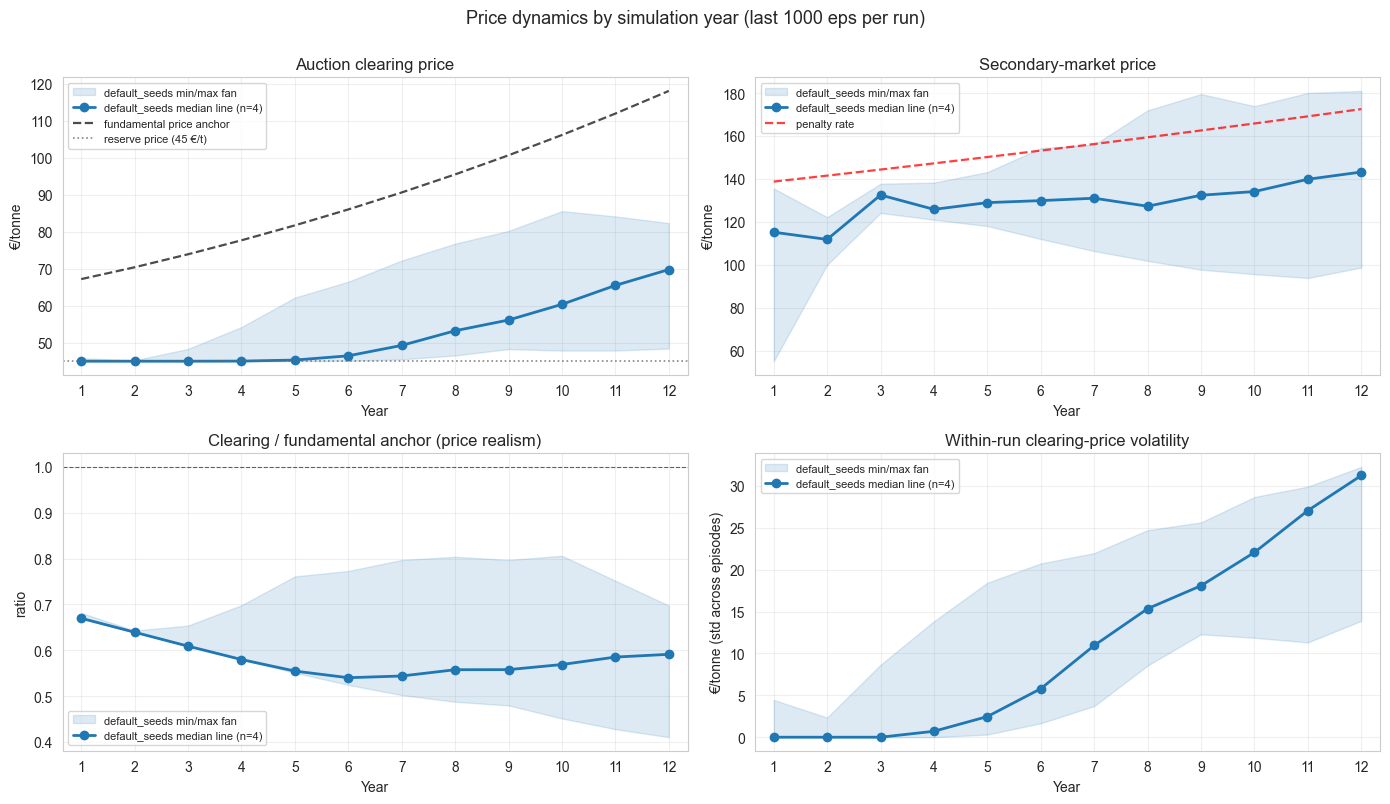

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

_clearing_price_yoy = _per_sweep_year_stack(lambda yr: _scalar_mean_by_year(yr, 'clearing_price'))
_overlay_yoy(
    axes[0, 0],
    _clearing_price_yoy,
    ylabel='€/tonne', title='Auction clearing price')

_fundamental_anchor_yoy = _per_sweep_year_stack(lambda yr: _scalar_mean_by_year(yr, 'fundamental_anchor'))
_overlay_yoy_reference(
    axes[0, 0],
    _fundamental_anchor_yoy,
    label='fundamental price anchor',
    color='black', linestyle='--', alpha=0.7)
_reserve_price = _reference_reserve_price()
if np.isfinite(_reserve_price):
    axes[0, 0].axhline(_reserve_price, color='dimgray', lw=1.2,
                       linestyle=':', alpha=0.8,
                       label=f'reserve price ({_reserve_price:g} €/t)')
axes[0, 0].legend(fontsize=8, loc='best')

_secondary_price_yoy = _per_sweep_year_stack(lambda yr: _scalar_mean_by_year(yr, 'secondary_price'))
_overlay_yoy(
    axes[0, 1],
    _secondary_price_yoy,
    ylabel='€/tonne', title='Secondary-market price')
_penalty_rate = _penalty_rate_by_years(_years_from_sweep_data(_secondary_price_yoy))
if not _penalty_rate.empty:
    axes[0, 1].plot(_penalty_rate.index, _penalty_rate.values,
                    color='red', lw=1.6, linestyle='--', alpha=0.75,
                    label='penalty rate')
axes[0, 1].legend(fontsize=8, loc='best')

def _clearing_over_anchor(yr):
    if 'clearing_price' not in yr.columns or 'fundamental_anchor' not in yr.columns:
        return None
    g = yr.groupby('year')[['clearing_price', 'fundamental_anchor']].mean()
    anchor = g['fundamental_anchor'].replace(0, np.nan)
    return (g['clearing_price'] / anchor)

_overlay_yoy(
    axes[1, 0],
    _per_sweep_year_stack(_clearing_over_anchor),
    ylabel='ratio', title='Clearing / fundamental anchor (price realism)')
axes[1, 0].axhline(1.0, color='black', lw=0.8, linestyle='--', alpha=0.6)

_overlay_yoy(
    axes[1, 1],
    _per_sweep_year_stack(lambda yr: _scalar_std_by_year(yr, 'clearing_price')),
    ylabel='€/tonne (std across episodes)',
    title='Within-run clearing-price volatility')

plt.suptitle(f'Price dynamics by simulation year (last {YOY_TAIL_EPISODES} eps per run)',
             fontsize=13, y=1.00)
plt.tight_layout(); plt.show()


In [32]:
# Companion data tables for the price-dynamics figure above.
# Each row of the per-year table corresponds to one plotted point;
# the across-year summary collapses the median series into mean/std/
# min/max so the thesis text can quote both shape and headline numbers.

def _clearing_over_anchor_tbl(yr):
    if 'clearing_price' not in yr.columns or 'fundamental_anchor' not in yr.columns:
        return None
    g = yr.groupby('year')[['clearing_price', 'fundamental_anchor']].mean()
    anchor = g['fundamental_anchor'].replace(0, np.nan)
    return g['clearing_price'] / anchor

_panels_price = [
    ('Auction clearing price',
     _per_sweep_year_stack(lambda yr: _scalar_mean_by_year(yr, 'clearing_price'))),
    ('Secondary-market price',
     _per_sweep_year_stack(lambda yr: _scalar_mean_by_year(yr, 'secondary_price'))),
    ('Clearing / fundamental anchor (price realism)',
     _per_sweep_year_stack(_clearing_over_anchor_tbl)),
    ('Within-run clearing-price volatility',
     _per_sweep_year_stack(lambda yr: _scalar_std_by_year(yr, 'clearing_price'))),
]
_units_price = {
    'Auction clearing price': '€/tonne',
    'Secondary-market price': '€/tonne',
    'Clearing / fundamental anchor (price realism)': 'ratio',
    'Within-run clearing-price volatility': '€/tonne (std across episodes)',
}
_price_yoy_tables = _show_yoy_tables(_panels_price, units=_units_price)


Across-year summary (plotted median series across 1000-episode tail, per sweep):


,panel,unit,sweep,n_seeds,years,mean,median,std,min,max
0,Auction clearing price,€/tonne,default_seeds,4,12,52.17,47.86,8.868,45,69.78
1,Secondary-market price,€/tonne,default_seeds,4,12,129.3,130.4,8.906,111.8,143.2
2,Clearing / fundamental anchor (price realism),ratio,default_seeds,4,12,0.5829,0.5742,0.03946,0.54,0.6696
3,Within-run clearing-price volatility,€/tonne (std across episodes),default_seeds,4,12,11.15,8.376,11.4,0,31.25


Per-year detail (median line; shaded min/max fan; mean listed for comparison):


,panel,unit,sweep,year,mean_across_seeds,median_across_seeds,std_across_seeds,min_across_seeds,max_across_seeds,n_seeds
0,Auction clearing price,€/tonne,default_seeds,1,45.2,45,0.3955,45,45.79,4
1,Auction clearing price,€/tonne,default_seeds,2,45.06,45,0.1272,45,45.25,4
2,Auction clearing price,€/tonne,default_seeds,3,45.83,45,1.659,45,48.32,4
3,Auction clearing price,€/tonne,default_seeds,4,47.32,45.03,4.608,45,54.24,4
4,Auction clearing price,€/tonne,default_seeds,5,49.46,45.31,8.492,45.02,62.19,4
5,Auction clearing price,€/tonne,default_seeds,6,51.13,46.45,10.3,45.11,66.49,4
6,Auction clearing price,€/tonne,default_seeds,7,54.07,49.27,12.42,45.5,72.22,4
7,Auction clearing price,€/tonne,default_seeds,8,57.45,53.23,13.79,46.56,76.77,4
8,Auction clearing price,€/tonne,default_seeds,9,60.19,56.13,15.24,48.27,80.23,4
9,Auction clearing price,€/tonne,default_seeds,10,63.55,60.38,17.65,47.87,85.57,4


### Compliance and penalty pressure over the simulation year

System-aggregate coverage gap (Mt remaining after the auction),
end-of-year carry-forward (debt cascade indicator), compliance rate
(share of (agent, year) cells with non-negative compliance surplus),
and the system-aggregate penalty paid per year.


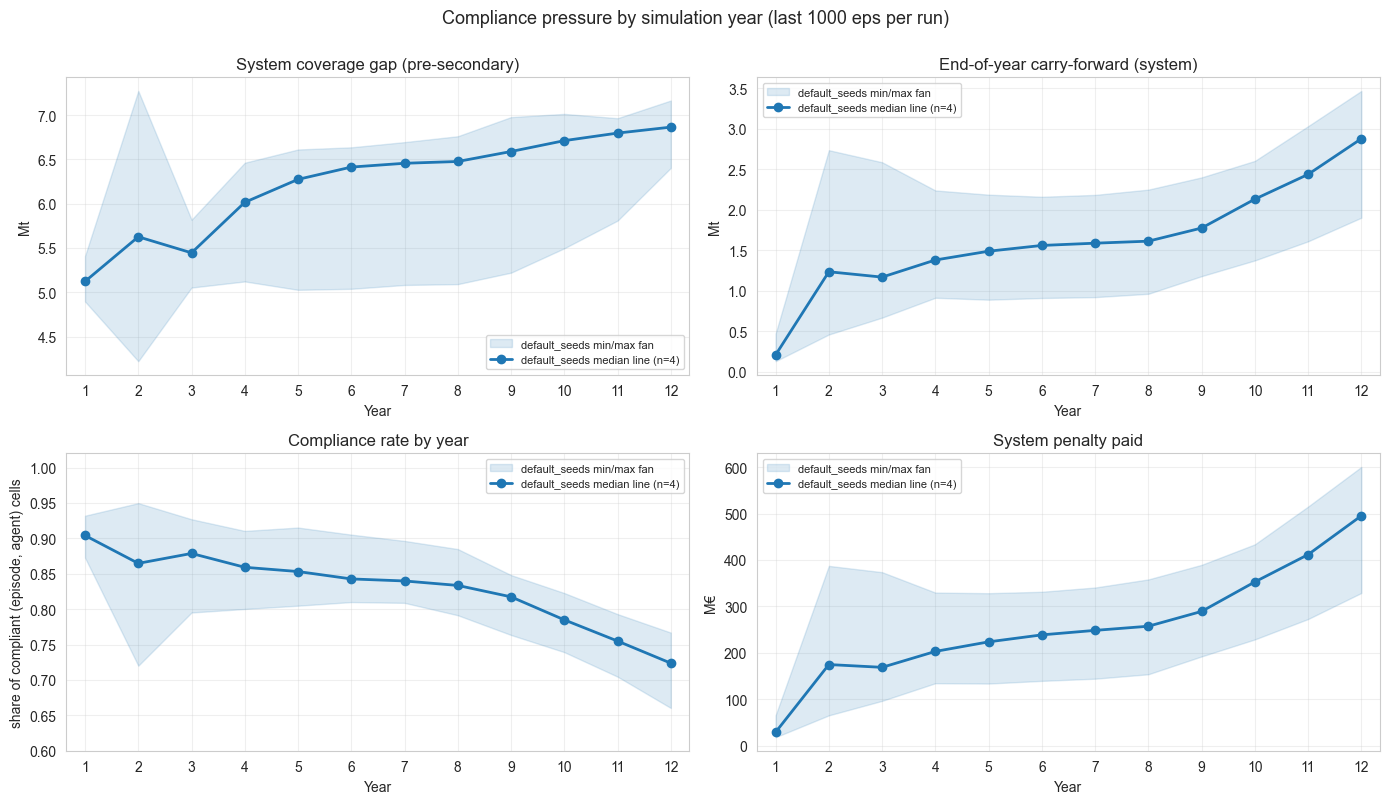

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

_overlay_yoy(
    axes[0, 0],
    _per_sweep_year_stack(lambda yr: _system_sum_by_year(yr, 'coverage_gap')),
    ylabel='Mt', title='System coverage gap (pre-secondary)')

_overlay_yoy(
    axes[0, 1],
    _per_sweep_year_stack(lambda yr: _system_sum_by_year(yr, 'carry_forward_end')),
    ylabel='Mt', title='End-of-year carry-forward (system)')

def _compliance_rate_by_year(yr):
    sf_cols = _agent_cols_in(yr, 'shortfall')
    if sf_cols:
        long = yr.melt(id_vars=['year'], value_vars=sf_cols, value_name='shortfall')
        long['compliant'] = (long['shortfall'] <= 1e-6).astype(float)
        return long.groupby('year')['compliant'].mean()

    surplus_cols = _agent_cols_in(yr, 'compliance_surplus')
    if not surplus_cols:
        return None
    long = yr.melt(id_vars=['year'], value_vars=surplus_cols, value_name='surplus')
    long['compliant'] = (long['surplus'].fillna(0) >= -1e-6).astype(float)
    return long.groupby('year')['compliant'].mean()

_overlay_yoy(
    axes[1, 0],
    _per_sweep_year_stack(_compliance_rate_by_year),
    ylabel='share of compliant (episode, agent) cells',
    title='Compliance rate by year')
axes[1, 0].set_ylim(0.6, 1.02)

_overlay_yoy(
    axes[1, 1],
    _per_sweep_year_stack(lambda yr: _system_sum_by_year(yr, 'penalty')),
    ylabel='M€', title='System penalty paid')

plt.suptitle(f'Compliance pressure by simulation year (last {YOY_TAIL_EPISODES} eps per run)',
             fontsize=13, y=1.00)
plt.tight_layout(); plt.show()


In [34]:
# Companion data tables for the compliance / penalty-pressure figure.
def _compliance_rate_tbl(yr):
    sf_cols = _agent_cols_in(yr, 'shortfall')
    if sf_cols:
        long = yr.melt(id_vars=['year'], value_vars=sf_cols, value_name='shortfall')
        long['compliant'] = (long['shortfall'] <= 1e-6).astype(float)
        return long.groupby('year')['compliant'].mean()

    surplus_cols = _agent_cols_in(yr, 'compliance_surplus')
    if not surplus_cols:
        return None
    long = yr.melt(id_vars=['year'], value_vars=surplus_cols, value_name='surplus')
    long['compliant'] = (long['surplus'].fillna(0) >= -1e-6).astype(float)
    return long.groupby('year')['compliant'].mean()

_panels_compliance = [
    ('System coverage gap (pre-secondary)',
     _per_sweep_year_stack(lambda yr: _system_sum_by_year(yr, 'coverage_gap'))),
    ('End-of-year carry-forward (system)',
     _per_sweep_year_stack(lambda yr: _system_sum_by_year(yr, 'carry_forward_end'))),
    ('Compliance rate by year',
     _per_sweep_year_stack(_compliance_rate_tbl)),
    ('System penalty paid',
     _per_sweep_year_stack(lambda yr: _system_sum_by_year(yr, 'penalty'))),
]
_units_compliance = {
    'System coverage gap (pre-secondary)': 'Mt',
    'End-of-year carry-forward (system)': 'Mt',
    'Compliance rate by year': 'share of compliant (episode, agent) cells',
    'System penalty paid': 'M€',
}
_compliance_yoy_tables = _show_yoy_tables(_panels_compliance, units=_units_compliance)


Across-year summary (plotted median series across 1000-episode tail, per sweep):


,panel,unit,sweep,n_seeds,years,mean,median,std,min,max
0,System coverage gap (pre-secondary),Mt,default_seeds,4,12,6.233,6.435,0.5627,5.123,6.864
1,End-of-year carry-forward (system),Mt,default_seeds,4,12,1.621,1.573,0.6715,0.2078,2.877
2,Compliance rate by year,"share of compliant (episode, agent) cells",default_seeds,4,12,0.8297,0.8413,0.05209,0.7237,0.9041
3,System penalty paid,M€,default_seeds,4,12,257.6,243.5,121.4,28.83,495.3


Per-year detail (median line; shaded min/max fan; mean listed for comparison):


,panel,unit,sweep,year,mean_across_seeds,median_across_seeds,std_across_seeds,min_across_seeds,max_across_seeds,n_seeds
0,System coverage gap (pre-secondary),Mt,default_seeds,1,5.138,5.123,0.2108,4.896,5.41,4
1,System coverage gap (pre-secondary),Mt,default_seeds,2,5.687,5.626,1.262,4.222,7.273,4
2,System coverage gap (pre-secondary),Mt,default_seeds,3,5.441,5.445,0.4141,5.053,5.819,4
3,System coverage gap (pre-secondary),Mt,default_seeds,4,5.904,6.016,0.5657,5.122,6.462,4
4,System coverage gap (pre-secondary),Mt,default_seeds,5,6.047,6.275,0.6991,5.028,6.612,4
5,System coverage gap (pre-secondary),Mt,default_seeds,6,6.125,6.413,0.7338,5.039,6.636,4
6,System coverage gap (pre-secondary),Mt,default_seeds,7,6.172,6.456,0.7477,5.083,6.695,4
7,System coverage gap (pre-secondary),Mt,default_seeds,8,6.201,6.476,0.756,5.092,6.761,4
8,System coverage gap (pre-secondary),Mt,default_seeds,9,6.344,6.589,0.7726,5.221,6.977,4
9,System coverage gap (pre-secondary),Mt,default_seeds,10,6.483,6.711,0.6731,5.497,7.013,4


### Decarbonisation and investment over the simulation year

Cross-agent mean green generation share (does the fleet green up over
the year axis?), system emissions (Mt), system invest cost (M€), and
MAC fuel-switching reductions (Mt abated). All four panels read from
per-agent year_log columns aggregated across the converged tail.


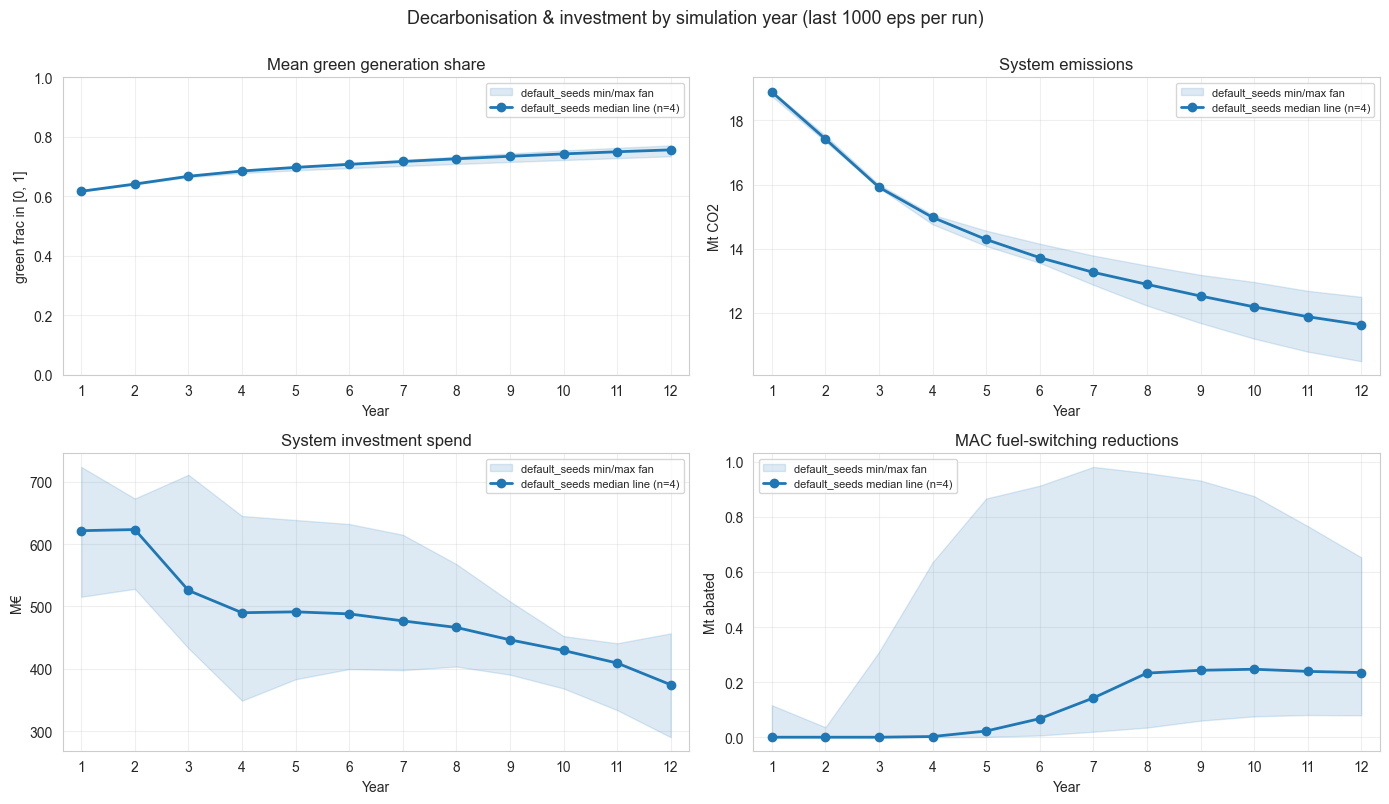

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

_overlay_yoy(
    axes[0, 0],
    _per_sweep_year_stack(lambda yr: _agent_mean_by_year(yr, 'green_frac')),
    ylabel='green frac in [0, 1]', title='Mean green generation share')
axes[0, 0].set_ylim(0, 1)

_overlay_yoy(
    axes[0, 1],
    _per_sweep_year_stack(lambda yr: _system_sum_by_year(yr, 'emissions')),
    ylabel='Mt CO2', title='System emissions')

_overlay_yoy(
    axes[1, 0],
    _per_sweep_year_stack(lambda yr: _system_sum_by_year(yr, 'invest_cost')),
    ylabel='M€', title='System investment spend')

_overlay_yoy(
    axes[1, 1],
    _per_sweep_year_stack(lambda yr: _system_sum_by_year(yr, 'mac_reduction')),
    ylabel='Mt abated', title='MAC fuel-switching reductions')

plt.suptitle(f'Decarbonisation & investment by simulation year (last {YOY_TAIL_EPISODES} eps per run)',
             fontsize=13, y=1.00)
plt.tight_layout(); plt.show()


In [36]:
# Companion data tables for the decarbonisation / investment figure.
_panels_decarb = [
    ('Mean green generation share',
     _per_sweep_year_stack(lambda yr: _agent_mean_by_year(yr, 'green_frac'))),
    ('System emissions',
     _per_sweep_year_stack(lambda yr: _system_sum_by_year(yr, 'emissions'))),
    ('System investment spend',
     _per_sweep_year_stack(lambda yr: _system_sum_by_year(yr, 'invest_cost'))),
    ('MAC fuel-switching reductions',
     _per_sweep_year_stack(lambda yr: _system_sum_by_year(yr, 'mac_reduction'))),
]
_units_decarb = {
    'Mean green generation share': 'green frac ∈ [0, 1]',
    'System emissions': 'Mt CO₂',
    'System investment spend': 'M€',
    'MAC fuel-switching reductions': 'Mt abated',
}
_decarb_yoy_tables = _show_yoy_tables(_panels_decarb, units=_units_decarb)


Across-year summary (plotted median series across 1000-episode tail, per sweep):


,panel,unit,sweep,n_seeds,years,mean,median,std,min,max
0,Mean green generation share,"green frac ∈ [0, 1]",default_seeds,4,12,0.7036,0.7125,0.04388,0.6171,0.7563
1,System emissions,Mt CO₂,default_seeds,4,12,14.13,13.49,2.283,11.63,18.88
2,System investment spend,M€,default_seeds,4,12,486.9,482.5,75.19,374.7,623.1
3,MAC fuel-switching reductions,Mt abated,default_seeds,4,12,0.1192,0.1049,0.1132,0,0.2468


Per-year detail (median line; shaded min/max fan; mean listed for comparison):


,panel,unit,sweep,year,mean_across_seeds,median_across_seeds,std_across_seeds,min_across_seeds,max_across_seeds,n_seeds
0,Mean green generation share,"green frac ∈ [0, 1]",default_seeds,1,0.617,0.6171,0.0002988,0.6165,0.6171,4
1,Mean green generation share,"green frac ∈ [0, 1]",default_seeds,2,0.6413,0.6413,0.001056,0.64,0.6424,4
2,Mean green generation share,"green frac ∈ [0, 1]",default_seeds,3,0.667,0.6675,0.002309,0.6639,0.6692,4
3,Mean green generation share,"green frac ∈ [0, 1]",default_seeds,4,0.684,0.6853,0.00381,0.6784,0.6871,4
4,Mean green generation share,"green frac ∈ [0, 1]",default_seeds,5,0.6955,0.6974,0.005549,0.6874,0.6998,4
5,Mean green generation share,"green frac ∈ [0, 1]",default_seeds,6,0.7053,0.7077,0.007364,0.695,0.7107,4
6,Mean green generation share,"green frac ∈ [0, 1]",default_seeds,7,0.7147,0.7172,0.009378,0.702,0.7222,4
7,Mean green generation share,"green frac ∈ [0, 1]",default_seeds,8,0.7237,0.7262,0.0114,0.7089,0.7335,4
8,Mean green generation share,"green frac ∈ [0, 1]",default_seeds,9,0.7324,0.7348,0.01321,0.7156,0.7443,4
9,Mean green generation share,"green frac ∈ [0, 1]",default_seeds,10,0.7404,0.7427,0.01476,0.7221,0.7542,4


### Secondary-market activity over the simulation year

Total secondary volume per year (sum of net buys across agents — by
construction equal to the sum of net sells), executed buyer / seller
counts vs the corresponding intent counts (a wide gap means agents
post uncrossable orders), and the training-consistent secondary match
rate (share of episode-years with any executed trade). If the required
match-rate fields are unavailable in a run, the panel falls back to the
secondary-vs-clearing price spread.


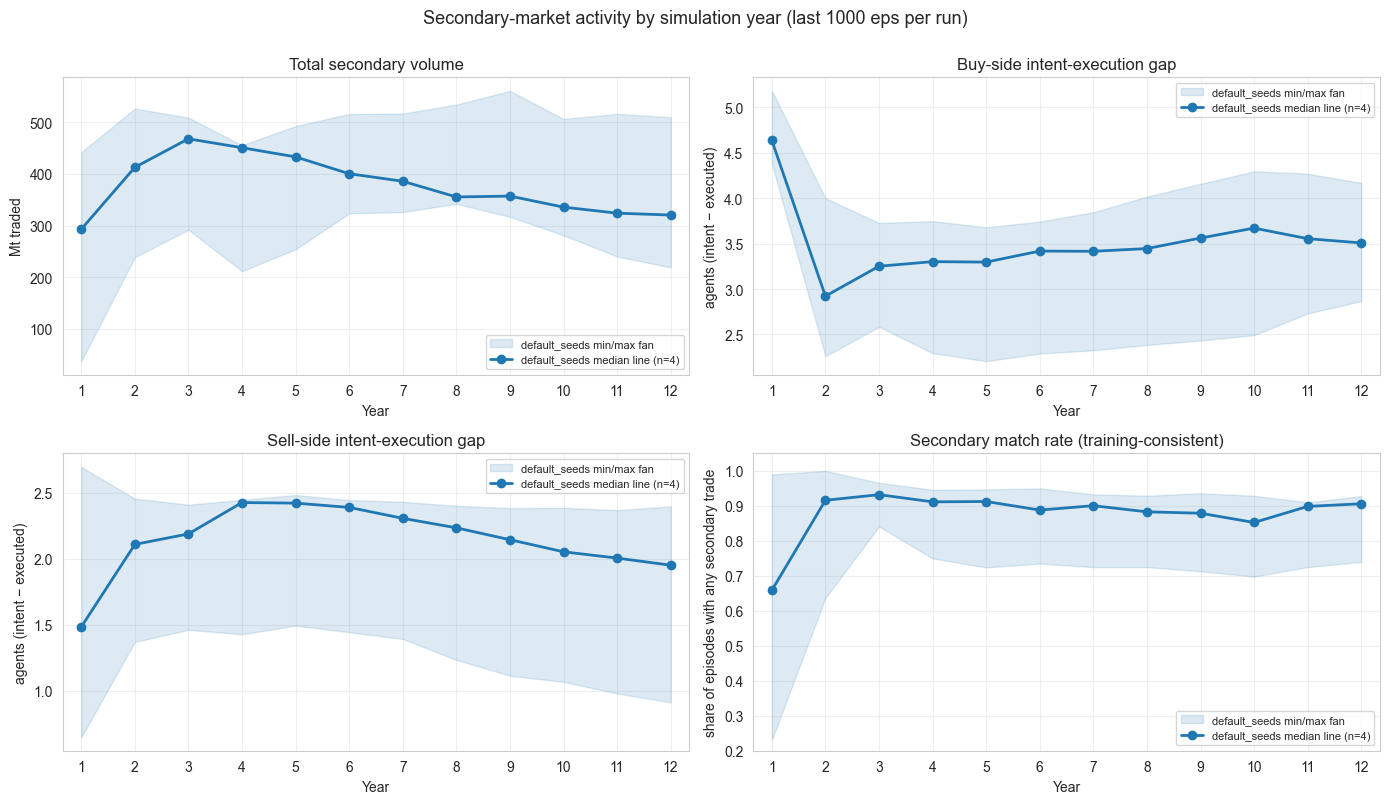

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

def _secondary_volume(yr):
    cols = _agent_cols_in(yr, 'secondary_net')
    if not cols:
        # Fallback: signed trade_qty across agents.
        cols = _agent_cols_in(yr, 'trade_qty')
        if not cols:
            return None
    # Mean per (year, agent) across episodes, then sum positives across agents.
    by_year = yr.groupby('year')[cols].mean()
    return by_year.clip(lower=0).sum(axis=1)

_overlay_yoy(
    axes[0, 0],
    _per_sweep_year_stack(_secondary_volume),
    ylabel='Mt traded', title='Total secondary volume')

def _intent_exec_gap_buyers(yr):
    if not {'secondary_n_buyers_intent', 'secondary_n_buyers_executed'}.issubset(yr.columns):
        return None
    g = yr.groupby('year')[['secondary_n_buyers_intent', 'secondary_n_buyers_executed']].mean()
    return g['secondary_n_buyers_intent'] - g['secondary_n_buyers_executed']

def _intent_exec_gap_sellers(yr):
    if not {'secondary_n_sellers_intent', 'secondary_n_sellers_executed'}.issubset(yr.columns):
        return None
    g = yr.groupby('year')[['secondary_n_sellers_intent', 'secondary_n_sellers_executed']].mean()
    return g['secondary_n_sellers_intent'] - g['secondary_n_sellers_executed']

_overlay_yoy(
    axes[0, 1],
    _per_sweep_year_stack(_intent_exec_gap_buyers),
    ylabel='agents (intent − executed)',
    title='Buy-side intent-execution gap')

_overlay_yoy(
    axes[1, 0],
    _per_sweep_year_stack(_intent_exec_gap_sellers),
    ylabel='agents (intent − executed)',
    title='Sell-side intent-execution gap')

def _training_match_rate_by_year(yr):
    # Match the training metric definition: a year is matched if any trade executed.
    cols = {'secondary_n_buyers_executed', 'secondary_n_sellers_executed'}
    if cols.issubset(yr.columns):
        any_trade = (yr['secondary_n_buyers_executed'].fillna(0)
                     + yr['secondary_n_sellers_executed'].fillna(0)) > 0
        return any_trade.groupby(yr['year']).mean()
    trade_cols = _agent_cols_in(yr, 'trade_qty')
    if not trade_cols:
        return None
    any_trade = yr[trade_cols].fillna(0).abs().gt(1e-6).any(axis=1)
    return any_trade.groupby(yr['year']).mean()

def _sec_minus_clearing(yr):
    if not {'secondary_price', 'clearing_price'}.issubset(yr.columns):
        return None
    g = yr.groupby('year')[['secondary_price', 'clearing_price']].mean()
    return g['secondary_price'] - g['clearing_price']

_match_rate_yoy = _per_sweep_year_stack(_training_match_rate_by_year)
if _match_rate_yoy:
    _secondary_panel_data = _match_rate_yoy
    _secondary_panel_ylabel = 'share of episodes with any secondary trade'
    _secondary_panel_title = 'Secondary match rate (training-consistent)'
else:
    _secondary_panel_data = _per_sweep_year_stack(_sec_minus_clearing)
    _secondary_panel_ylabel = '€/tonne'
    _secondary_panel_title = 'Secondary − clearing price spread'

_overlay_yoy(
    axes[1, 1],
    _secondary_panel_data,
    ylabel=_secondary_panel_ylabel,
    title=_secondary_panel_title)
if _match_rate_yoy:
    axes[1, 1].set_ylim(0.2, 1.05)
else:
    axes[1, 1].axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.6)

plt.suptitle(f'Secondary-market activity by simulation year (last {YOY_TAIL_EPISODES} eps per run)',
             fontsize=13, y=1.00)
plt.tight_layout(); plt.show()


In [38]:
# Companion data tables for the secondary-market activity figure.
def _secondary_volume_tbl(yr):
    cols = _agent_cols_in(yr, 'secondary_net')
    if not cols:
        cols = _agent_cols_in(yr, 'trade_qty')
        if not cols:
            return None
    by_year = yr.groupby('year')[cols].mean()
    return by_year.clip(lower=0).sum(axis=1)

def _intent_exec_gap_buyers_tbl(yr):
    if not {'secondary_n_buyers_intent', 'secondary_n_buyers_executed'}.issubset(yr.columns):
        return None
    g = yr.groupby('year')[['secondary_n_buyers_intent', 'secondary_n_buyers_executed']].mean()
    return g['secondary_n_buyers_intent'] - g['secondary_n_buyers_executed']

def _intent_exec_gap_sellers_tbl(yr):
    if not {'secondary_n_sellers_intent', 'secondary_n_sellers_executed'}.issubset(yr.columns):
        return None
    g = yr.groupby('year')[['secondary_n_sellers_intent', 'secondary_n_sellers_executed']].mean()
    return g['secondary_n_sellers_intent'] - g['secondary_n_sellers_executed']

def _training_match_rate_by_year_tbl(yr):
    cols = {'secondary_n_buyers_executed', 'secondary_n_sellers_executed'}
    if cols.issubset(yr.columns):
        any_trade = (yr['secondary_n_buyers_executed'].fillna(0)
                     + yr['secondary_n_sellers_executed'].fillna(0)) > 0
        return any_trade.groupby(yr['year']).mean()
    trade_cols = _agent_cols_in(yr, 'trade_qty')
    if not trade_cols:
        return None
    any_trade = yr[trade_cols].fillna(0).abs().gt(1e-6).any(axis=1)
    return any_trade.groupby(yr['year']).mean()

def _sec_minus_clearing_tbl(yr):
    if not {'secondary_price', 'clearing_price'}.issubset(yr.columns):
        return None
    g = yr.groupby('year')[['secondary_price', 'clearing_price']].mean()
    return g['secondary_price'] - g['clearing_price']

_match_rate_yoy_tbl = _per_sweep_year_stack(_training_match_rate_by_year_tbl)
if _match_rate_yoy_tbl:
    _secondary_panel_label = 'Secondary match rate (training-consistent)'
    _secondary_panel_unit = 'share of episodes with any secondary trade'
    _secondary_panel_stack = _match_rate_yoy_tbl
else:
    _secondary_panel_label = 'Secondary − clearing price spread'
    _secondary_panel_unit = '€/tonne'
    _secondary_panel_stack = _per_sweep_year_stack(_sec_minus_clearing_tbl)

_panels_secondary = [
    ('Total secondary volume',
     _per_sweep_year_stack(_secondary_volume_tbl)),
    ('Buy-side intent-execution gap',
     _per_sweep_year_stack(_intent_exec_gap_buyers_tbl)),
    ('Sell-side intent-execution gap',
     _per_sweep_year_stack(_intent_exec_gap_sellers_tbl)),
    (_secondary_panel_label,
     _secondary_panel_stack),
]
_units_secondary = {
    'Total secondary volume': 'Mt traded',
    'Buy-side intent-execution gap': 'agents (intent − executed)',
    'Sell-side intent-execution gap': 'agents (intent − executed)',
    _secondary_panel_label: _secondary_panel_unit,
}
_secondary_yoy_tables = _show_yoy_tables(_panels_secondary, units=_units_secondary)


Across-year summary (plotted median series across 1000-episode tail, per sweep):


,panel,unit,sweep,n_seeds,years,mean,median,std,min,max
0,Total secondary volume,Mt traded,default_seeds,4,12,378.1,371.5,55.99,293,468.2
1,Buy-side intent-execution gap,agents (intent − executed),default_seeds,4,12,3.498,3.432,0.4066,2.922,4.636
2,Sell-side intent-execution gap,agents (intent − executed),default_seeds,4,12,2.142,2.166,0.2618,1.484,2.425
3,Secondary match rate (training-consistent),share of episodes with any secondary trade,default_seeds,4,12,0.8782,0.8995,0.0722,0.6585,0.932


Per-year detail (median line; shaded min/max fan; mean listed for comparison):


,panel,unit,sweep,year,mean_across_seeds,median_across_seeds,std_across_seeds,min_across_seeds,max_across_seeds,n_seeds
0,Total secondary volume,Mt traded,default_seeds,1,266.3,293,171.7,36.96,442.2,4
1,Total secondary volume,Mt traded,default_seeds,2,397.9,413,140.6,238.8,526.9,4
2,Total secondary volume,Mt traded,default_seeds,3,434.4,468.2,99.44,291.9,509.2,4
3,Total secondary volume,Mt traded,default_seeds,4,392.3,451,120.4,211.7,455.7,4
4,Total secondary volume,Mt traded,default_seeds,5,403.4,433.2,103.4,254.1,493,4
5,Total secondary volume,Mt traded,default_seeds,6,410.3,400.5,79.64,323.6,516.5,4
6,Total secondary volume,Mt traded,default_seeds,7,403.8,385.9,81.71,326.2,517.2,4
7,Total secondary volume,Mt traded,default_seeds,8,396.9,355.5,92.53,342.2,534.6,4
8,Total secondary volume,Mt traded,default_seeds,9,398.1,357.1,111.7,316.9,561.1,4
9,Total secondary volume,Mt traded,default_seeds,10,364.8,335.8,105.2,281.1,506.7,4


### Reward and reward-component dynamics over the simulation year

System-aggregate per-year reward, the logged `reward_base` component
(financial − penalty + ESG), system penalty paid as a concrete reward
cost driver, plus the cross-agent reward dispersion per year (std across
the agent panel), which is a proxy for outcome equity. The per-episode
`quality_score` does not have a within-episode year axis and is therefore
covered in the convergence panels above; the reward-decomposition panels
here are its per-year analogue.


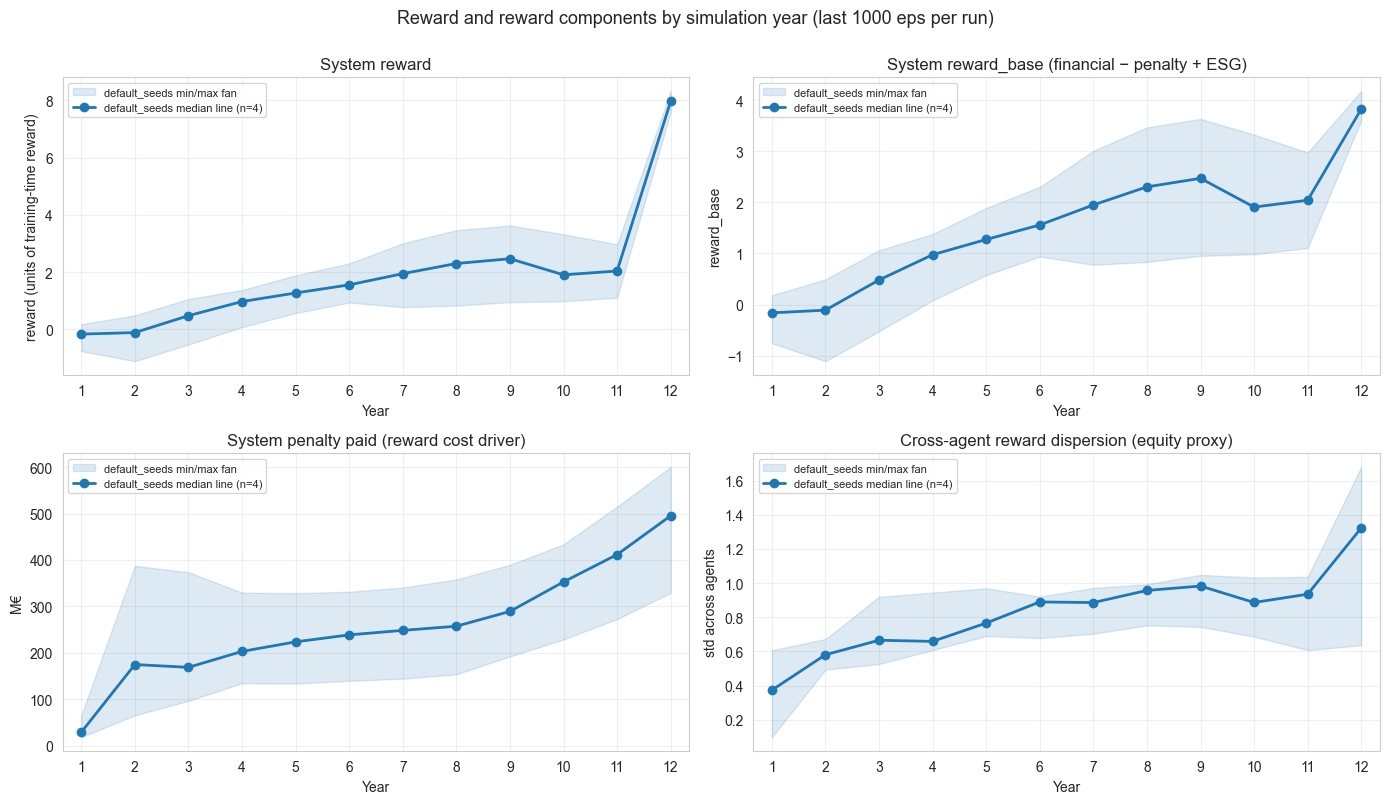

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

_overlay_yoy(
    axes[0, 0],
    _per_sweep_year_stack(lambda yr: _system_sum_by_year(yr, 'reward')),
    ylabel='reward (units of training-time reward)',
    title='System reward')

_overlay_yoy(
    axes[0, 1],
    _per_sweep_year_stack(lambda yr: _system_sum_by_year(yr, 'reward_base')),
    ylabel='reward_base', title='System reward_base (financial − penalty + ESG)')

_overlay_yoy(
    axes[1, 0],
    _per_sweep_year_stack(lambda yr: _system_sum_by_year(yr, 'penalty')),
    ylabel='M€', title='System penalty paid (reward cost driver)')

def _reward_dispersion(yr):
    cols = _agent_cols_in(yr, 'reward')
    if not cols:
        return None
    by_year = yr.groupby('year')[cols].mean()
    return by_year.std(axis=1)

_overlay_yoy(
    axes[1, 1],
    _per_sweep_year_stack(_reward_dispersion),
    ylabel='std across agents',
    title='Cross-agent reward dispersion (equity proxy)')

plt.suptitle(f'Reward and reward components by simulation year (last {YOY_TAIL_EPISODES} eps per run)',
             fontsize=13, y=1.00)
plt.tight_layout(); plt.show()


In [40]:
# Companion data tables for the reward-dynamics figure.
def _reward_dispersion_tbl(yr):
    cols = _agent_cols_in(yr, 'reward')
    if not cols:
        return None
    by_year = yr.groupby('year')[cols].mean()
    return by_year.std(axis=1)

_panels_reward = [
    ('System reward',
     _per_sweep_year_stack(lambda yr: _system_sum_by_year(yr, 'reward'))),
    ('System reward_base (financial − penalty + ESG)',
     _per_sweep_year_stack(lambda yr: _system_sum_by_year(yr, 'reward_base'))),
    ('System penalty paid (reward cost driver)',
     _per_sweep_year_stack(lambda yr: _system_sum_by_year(yr, 'penalty'))),
    ('Cross-agent reward dispersion (equity proxy)',
     _per_sweep_year_stack(_reward_dispersion_tbl)),
]
_units_reward = {
    'System reward': 'reward (training-time units)',
    'System reward_base (financial − penalty + ESG)': 'reward_base',
    'System penalty paid (reward cost driver)': 'M€',
    'Cross-agent reward dispersion (equity proxy)': 'std across agents',
}
_reward_yoy_tables = _show_yoy_tables(_panels_reward, units=_units_reward)


Across-year summary (plotted median series across 1000-episode tail, per sweep):


,panel,unit,sweep,n_seeds,years,mean,median,std,min,max
0,System reward,reward (training-time units),default_seeds,4,12,1.888,1.733,2.111,-0.1621,7.969
1,System reward_base (financial − penalty + ESG),reward_base,default_seeds,4,12,1.543,1.733,1.142,-0.1621,3.825
2,System penalty paid (reward cost driver),M€,default_seeds,4,12,257.6,243.5,121.4,28.83,495.3
3,Cross-agent reward dispersion (equity proxy),std across agents,default_seeds,4,12,0.8256,0.8865,0.2401,0.3737,1.323


Per-year detail (median line; shaded min/max fan; mean listed for comparison):


,panel,unit,sweep,year,mean_across_seeds,median_across_seeds,std_across_seeds,min_across_seeds,max_across_seeds,n_seeds
0,System reward,reward (training-time units),default_seeds,1,-0.2246,-0.1621,0.4109,-0.7557,0.1814,4
1,System reward,reward (training-time units),default_seeds,2,-0.208,-0.1089,0.7438,-1.108,0.4936,4
2,System reward,reward (training-time units),default_seeds,3,0.3754,0.4815,0.6776,-0.5241,1.063,4
3,System reward,reward (training-time units),default_seeds,4,0.8532,0.9753,0.5717,0.0826,1.38,4
4,System reward,reward (training-time units),default_seeds,5,1.253,1.274,0.5556,0.5751,1.889,4
5,System reward,reward (training-time units),default_seeds,6,1.59,1.558,0.5669,0.9405,2.304,4
6,System reward,reward (training-time units),default_seeds,7,1.921,1.949,1.032,0.778,3.008,4
7,System reward,reward (training-time units),default_seeds,8,2.227,2.303,1.185,0.8342,3.467,4
8,System reward,reward (training-time units),default_seeds,9,2.382,2.47,1.223,0.9536,3.632,4
9,System reward,reward (training-time units),default_seeds,10,2.032,1.908,1.105,0.9855,3.326,4


**Reading these panels.** Each coloured solid line is one sweep's
cross-seed median, with a shaded min/max fan when the sweep contains
more than one seed; both are labelled directly in the legend. The price
panels also add dashed or dotted reference lines for the fundamental
anchor, reserve price, and penalty rate where they help orient the scale.
Vertical separation between coloured medians is the cross-sweep effect;
band overlap indicates that the sweeps are indistinguishable at the
loaded sample size. The companion tables list cross-seed means alongside
medians for every year, so mean-sensitive outliers remain visible even
though the plotted line uses the median.

The line stays as the median because the loaded sample is small and seed
outliers can pull the mean into a path no actual seed followed. The
min/max fan shows the full observed envelope, while the tables keep the
mean available for thesis prose and checks where outlier sensitivity is
itself informative. Because every series is drawn from the converged tail,
year-to-year structure here reflects the *shape* of the steady-state
policy, not transient learning dynamics.


---

## What this notebook does **not** answer

* Cross-config sensitivity — needs sweep variants. *Out of scope here.*
* Causal attribution of regulatory mechanisms (e.g. counterfactual
  "what if MSR were off") — needs sweep variants.
* Real-world EU-ETS empirical validation beyond the qualitative
  price-band check in RQ1.3.
* Strategy clustering, theory tests (LCOE crossover, archetype
  heterogeneity), and predictive models of clearing price — these are
  in the analysis plan (`planning/data_science_analysis_plan.md` §B1, B2,
  B4) and will get their own notebooks where they can be evaluated
  cleanly with cross-validation.

The default-config evidence base assembled above is the *baseline* that
those follow-on analyses will perturb and test against.